# Experiments 84 & 85
### Mixed hyperparms: _RF augmentation (9x) + Full Fine-Tuning + Max epochs + IOU/CONF optimization_
### _multi_scale | weight_decay | momentum | dropout_


### Dataset:
- **Dataset:** 3.5m | 90º
- **Sizes:** small & mid
- **Split:** 640 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8m` *(Medium)*
- **Epochs:** ~500
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. Mix of hyperparms:
    - multi_scale | weight_decay | momentum | dropout
    - 9x augmentation *(synthetic data)*
    - Full Fine-Tuning *(No freeze)*
    - Max epochs (4 hours)
    - IOU/CONF optimization _(on valid)_

- **Reference:** Full Fine-Tuning ***(Best model)***

In [1]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
experiment_number = 3
project_root = "../" * 2

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/0 Mixed/{experiment_number} set/runs/detect/"

### Init

In [2]:
scale: int = 500 # size for graphs (in pixels)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go

In [4]:
def update_project_root(path = ''):
    global project_root
    if not path:
        path = os.getcwd()
    folder_depth = len([i for i in path.split("/") if i != ''])
    project_root = "../" * folder_depth

In [5]:
def change_directory(target_folder):
    """
    Change the current working directory to the target folder.
    Args:
        target_folder (str): The target folder path relative to the project root.
    """ 
    global project_root
    # Construct the full path
    target_path = os.path.join(project_root, target_folder)

    # Change the current working directory
    try:
        os.chdir(target_path)
        print(f"Current working directory: {os.getcwd()}")  # Verify

        folder_depth = len([i for i in target_folder.split("/") if i != ''])
        project_root = "../" * folder_depth
        print(f"Project root updated to: {project_root}")  # Verify

    except FileNotFoundError:
        print(f"Error: Folder '{target_path}' not found. Check the path.")
    except NotADirectoryError:
        print(f"Error: '{target_path}' is not a directory.")
    except Exception as e:
        print(f"An error occurred: {e}")

In [6]:
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/0 Mixed/3 set/runs/detect
Project root updated to: ../../../../../../


In [7]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [8]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [9]:
def show_cm(TP, FP, FN):
    matrix = [[TP, FP], [FN, 0]]
    total_det = sum(sum(value) for value in matrix)
    percentages = []
    for row in matrix:
        values_percentages = []
        for value in row:
            if total_det != 0:
                percentage = (value / total_det) * 100
            else:
                percentage = 0.0
            values_percentages.append(f"{percentage:.2f}%")
        percentages.append(values_percentages)
    
    print("Total objects detected:", total_det)
    print("\nConfusion matrix:")
    for row in percentages:
        a, b = row
        print(f"[ {a} , {b} ]")

In [10]:
def show_metrics(TP, FP, FN):
    show_cm(TP, FP, FN)
    accuracy = TP/(TP+FP+FN)
    precision = TP/(TP+FP)
    recall = TP/(TP+FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    f2 = 1.25 * (precision * recall) / (0.25 * precision + recall)
    fm = (precision * recall) ** 0.5
    print("\nMetrics:")
    print(f"- Accuracy: {accuracy:.3f}")
    print(f"- Precision: {precision:.3f}")
    print(f"- Recall: {recall:.3f}")
    print(f"- F1 Score: {f1:.3f}")
    print(f"- F½ Score: {f2:.3f}")
    print(f"- G-mean: {fm:.3f}")

In [11]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [12]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [13]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 84
### *YOLOv8 Mid | exGreen images*
Images created by applying exGreen

In [14]:
folder = "train/"

In [15]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
66,67,6840.76,1.17378,1.92512,1.30729,0.59215,0.53142,0.53313,0.18670,1.57201,2.65253,1.66631,0.000797,0.000797,0.000797
67,68,6936.17,1.15648,1.84734,1.28065,0.60057,0.53072,0.53137,0.18718,1.58220,2.62848,1.68269,0.000658,0.000658,0.000658
68,69,7042.70,1.15341,1.87398,1.30324,0.60072,0.52033,0.53309,0.18410,1.59466,2.62875,1.70089,0.000518,0.000518,0.000518
69,70,7142.44,1.13436,1.81948,1.28704,0.59806,0.53818,0.53536,0.18517,1.59317,2.61464,1.70535,0.000379,0.000379,0.000379
70,71,7202.04,1.13763,1.80532,1.28455,0.60628,0.52899,0.53284,0.18544,1.60331,2.61053,1.71774,0.000239,0.000239,0.000239


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [16]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 120.034 min


#### Best epoch

In [17]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
49,50,5120.45,1.29463,2.22765,1.33474,0.60306,0.53678,0.5412,0.19188,1.53359,2.65909,1.59745,0.003168,0.003168,0.003168,120.034


In [18]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 50 con mAP50 de 0.541


In [19]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [84]:
# Setting values from CM graph
TP = 2060
FP = 1407
FN = 1407

In [85]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4874

Confusion matrix:
[ 42.27% , 28.87% ]
[ 28.87% , 0.00% ]

Metrics:
- Accuracy: 0.423
- Precision: 0.594
- Recall: 0.594
- F1 Score: 0.594
- F½ Score: 0.594
- G-mean: 0.594


### Graphs

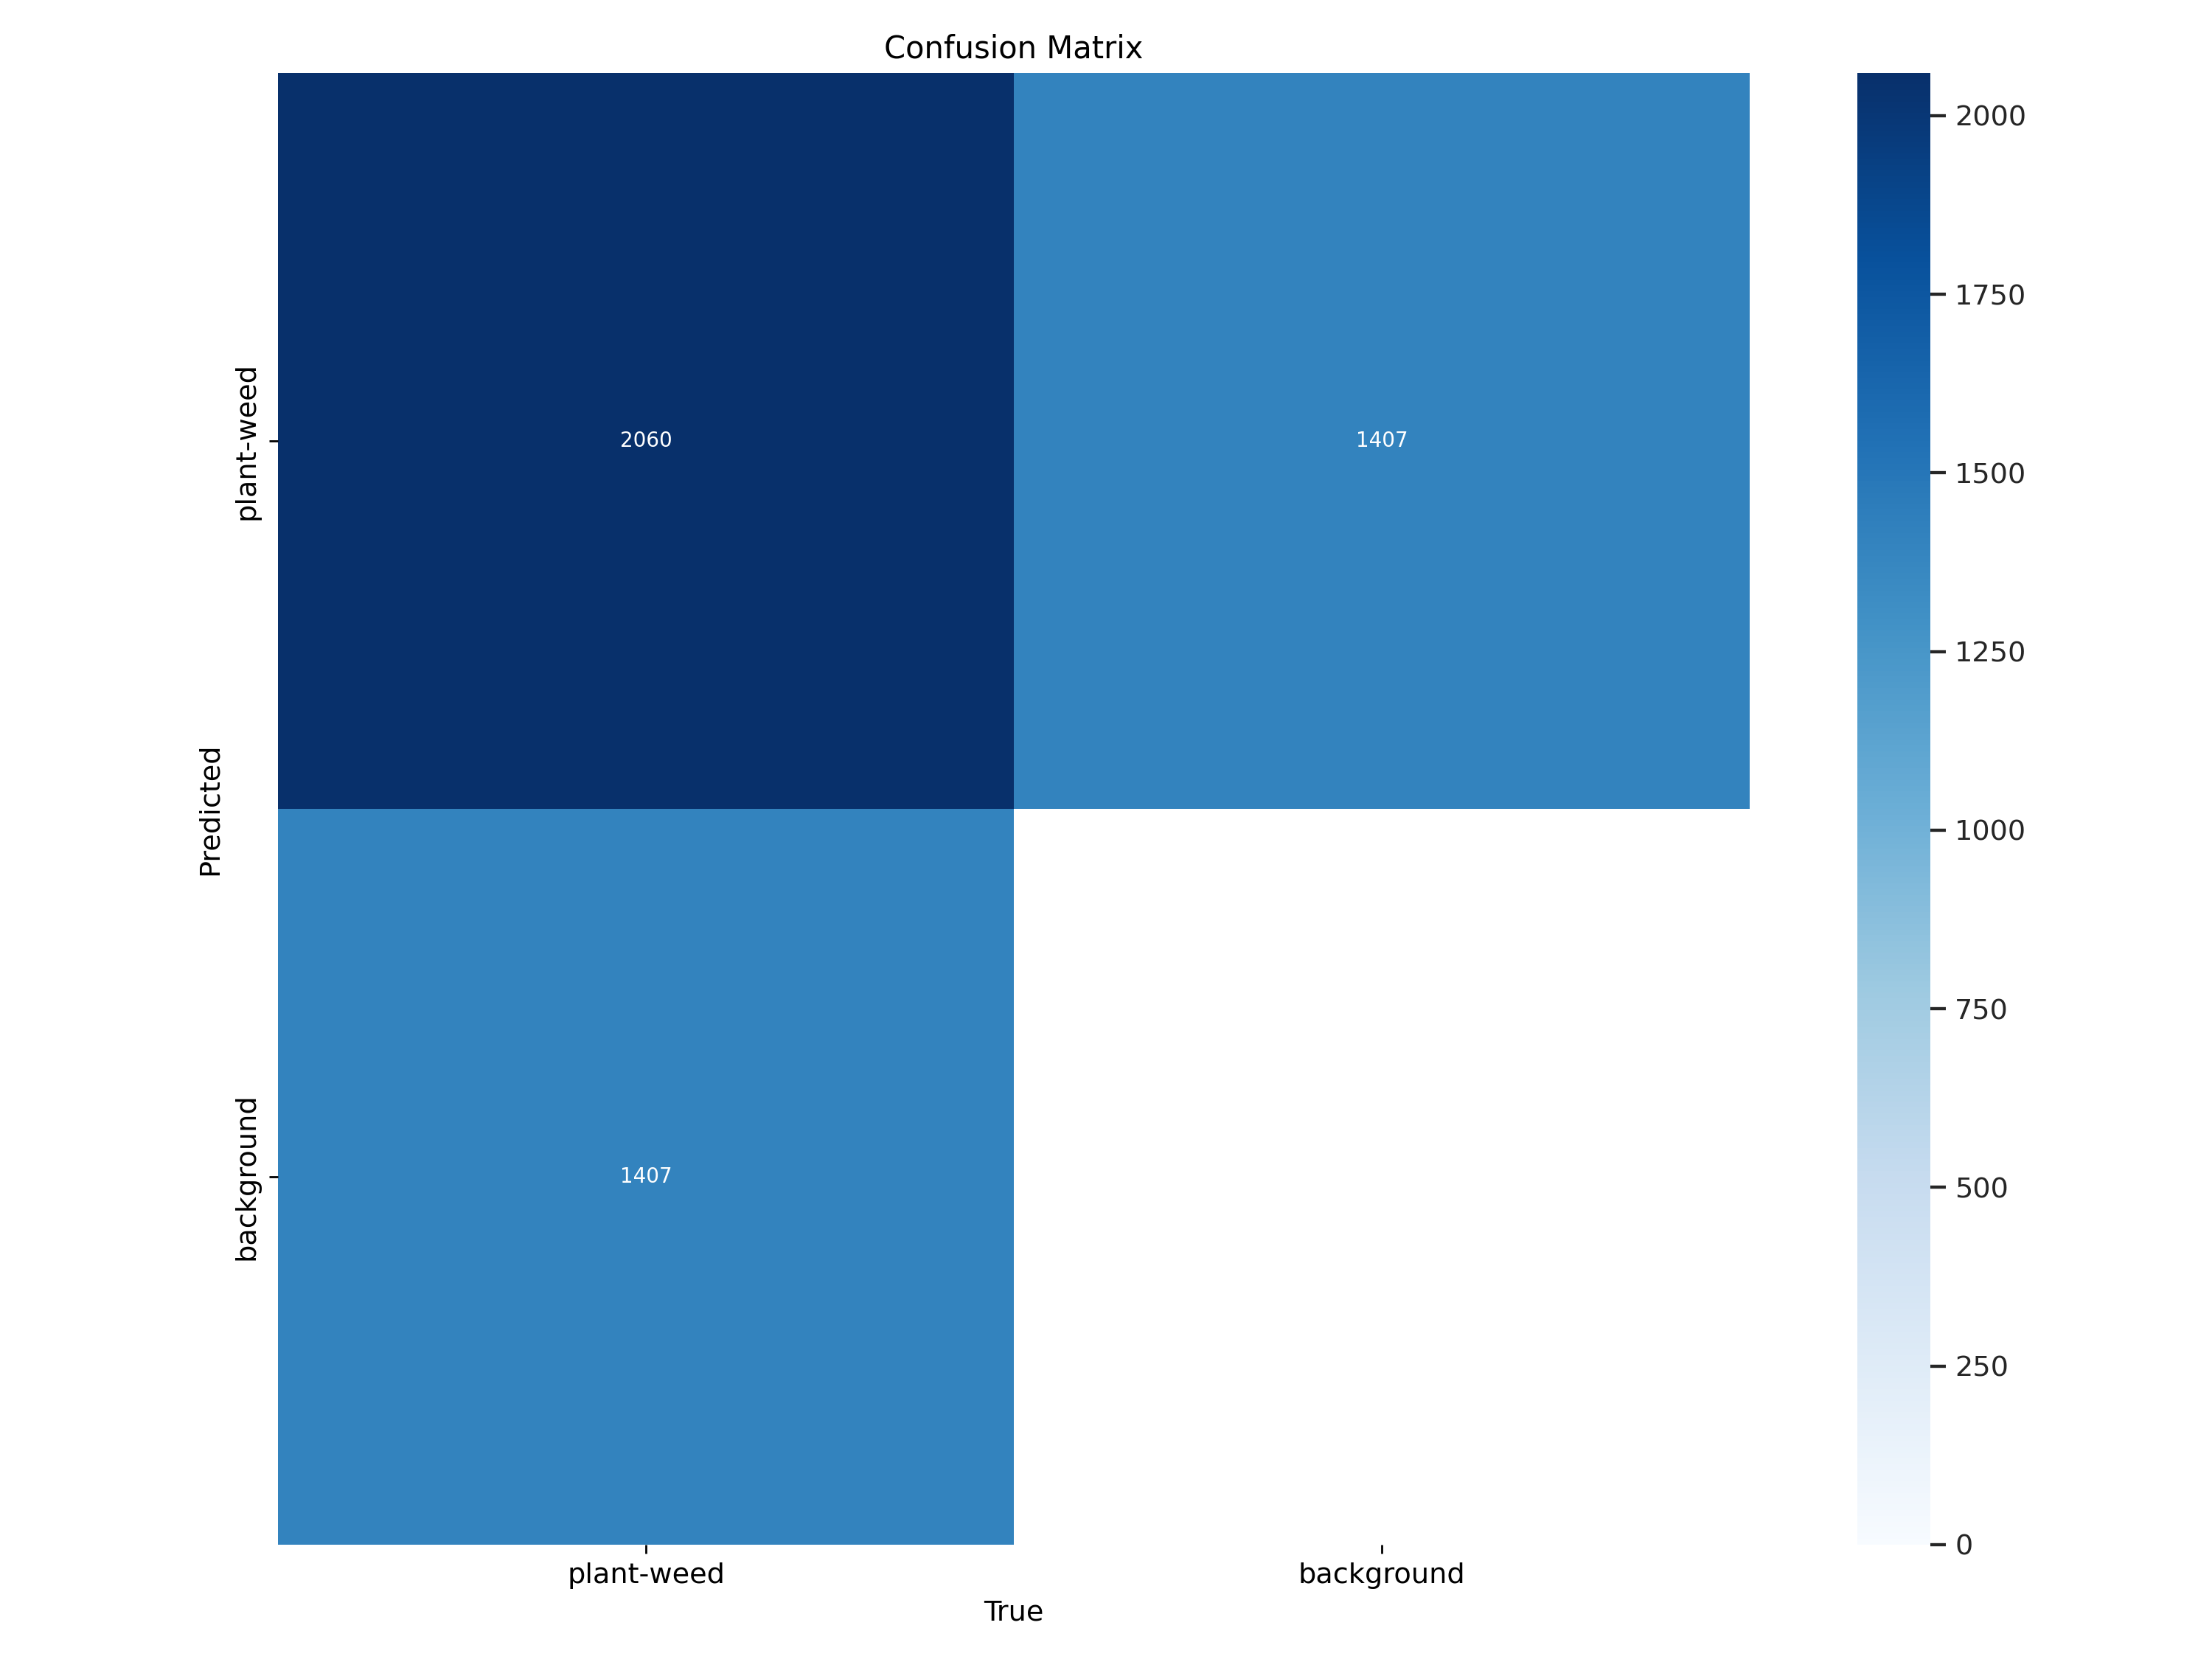

In [22]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

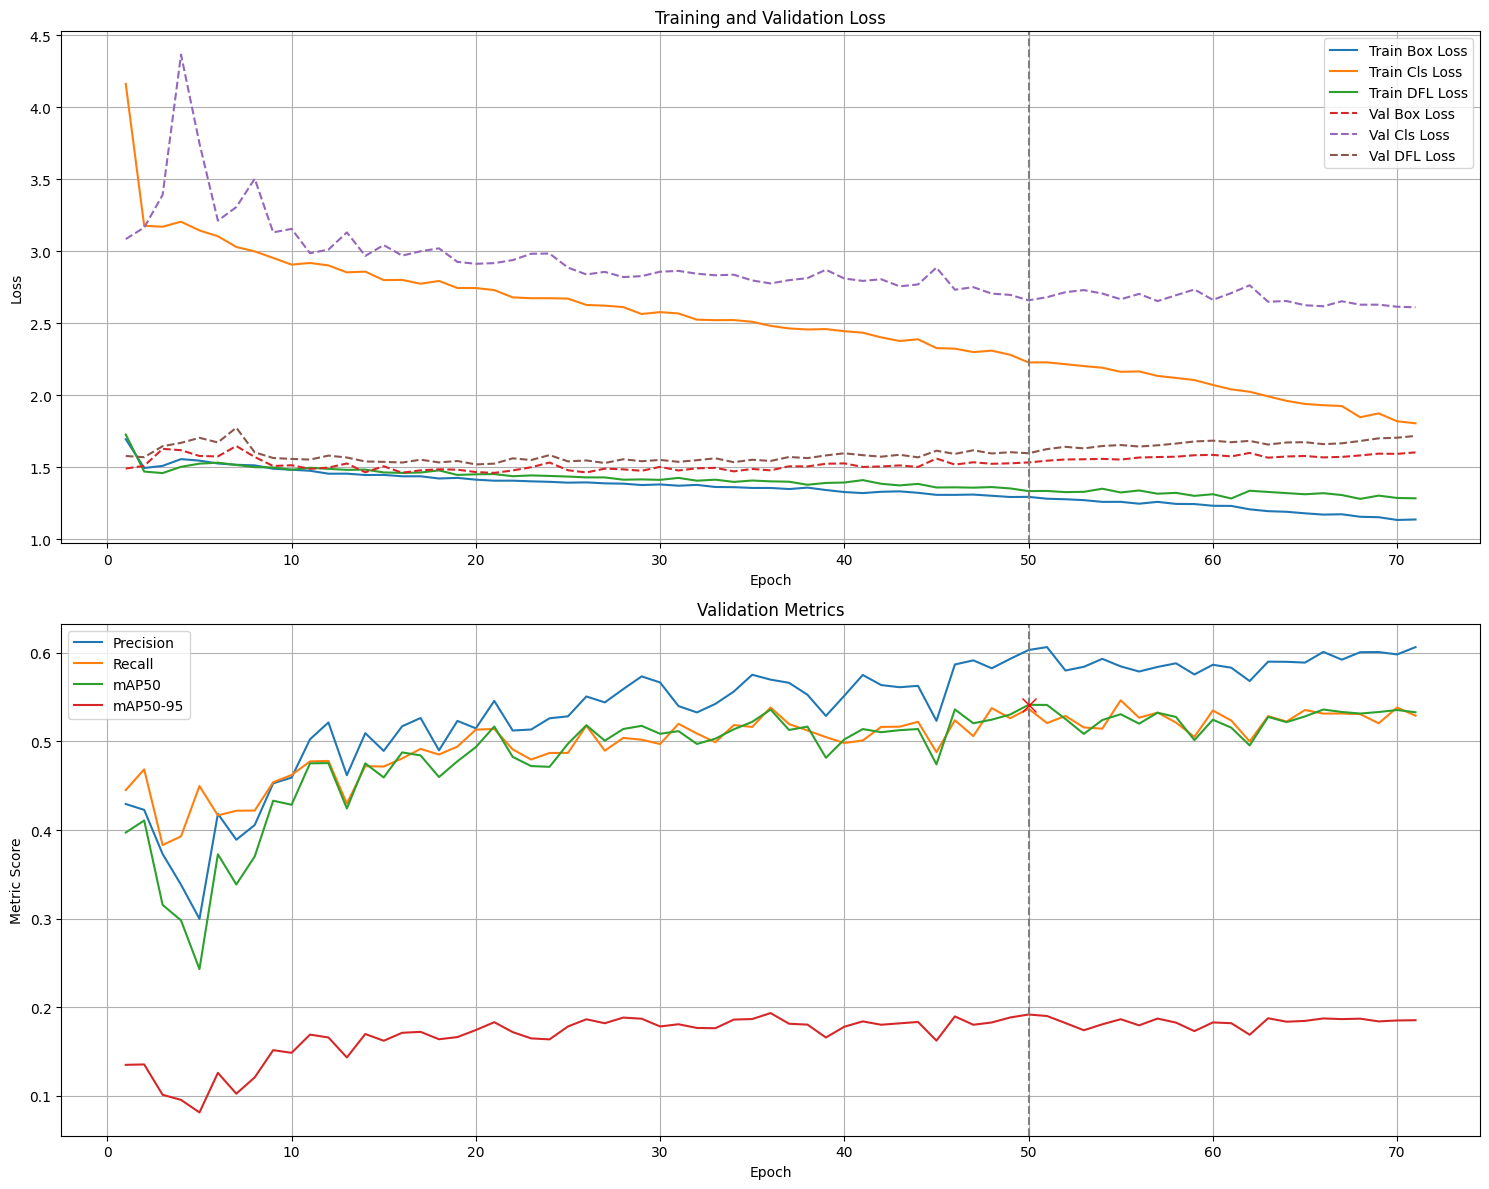

In [23]:
graph_training_metrics(df, epoch, graph="full")

In [24]:
graph_LrLoss_3D(df)

Validation set


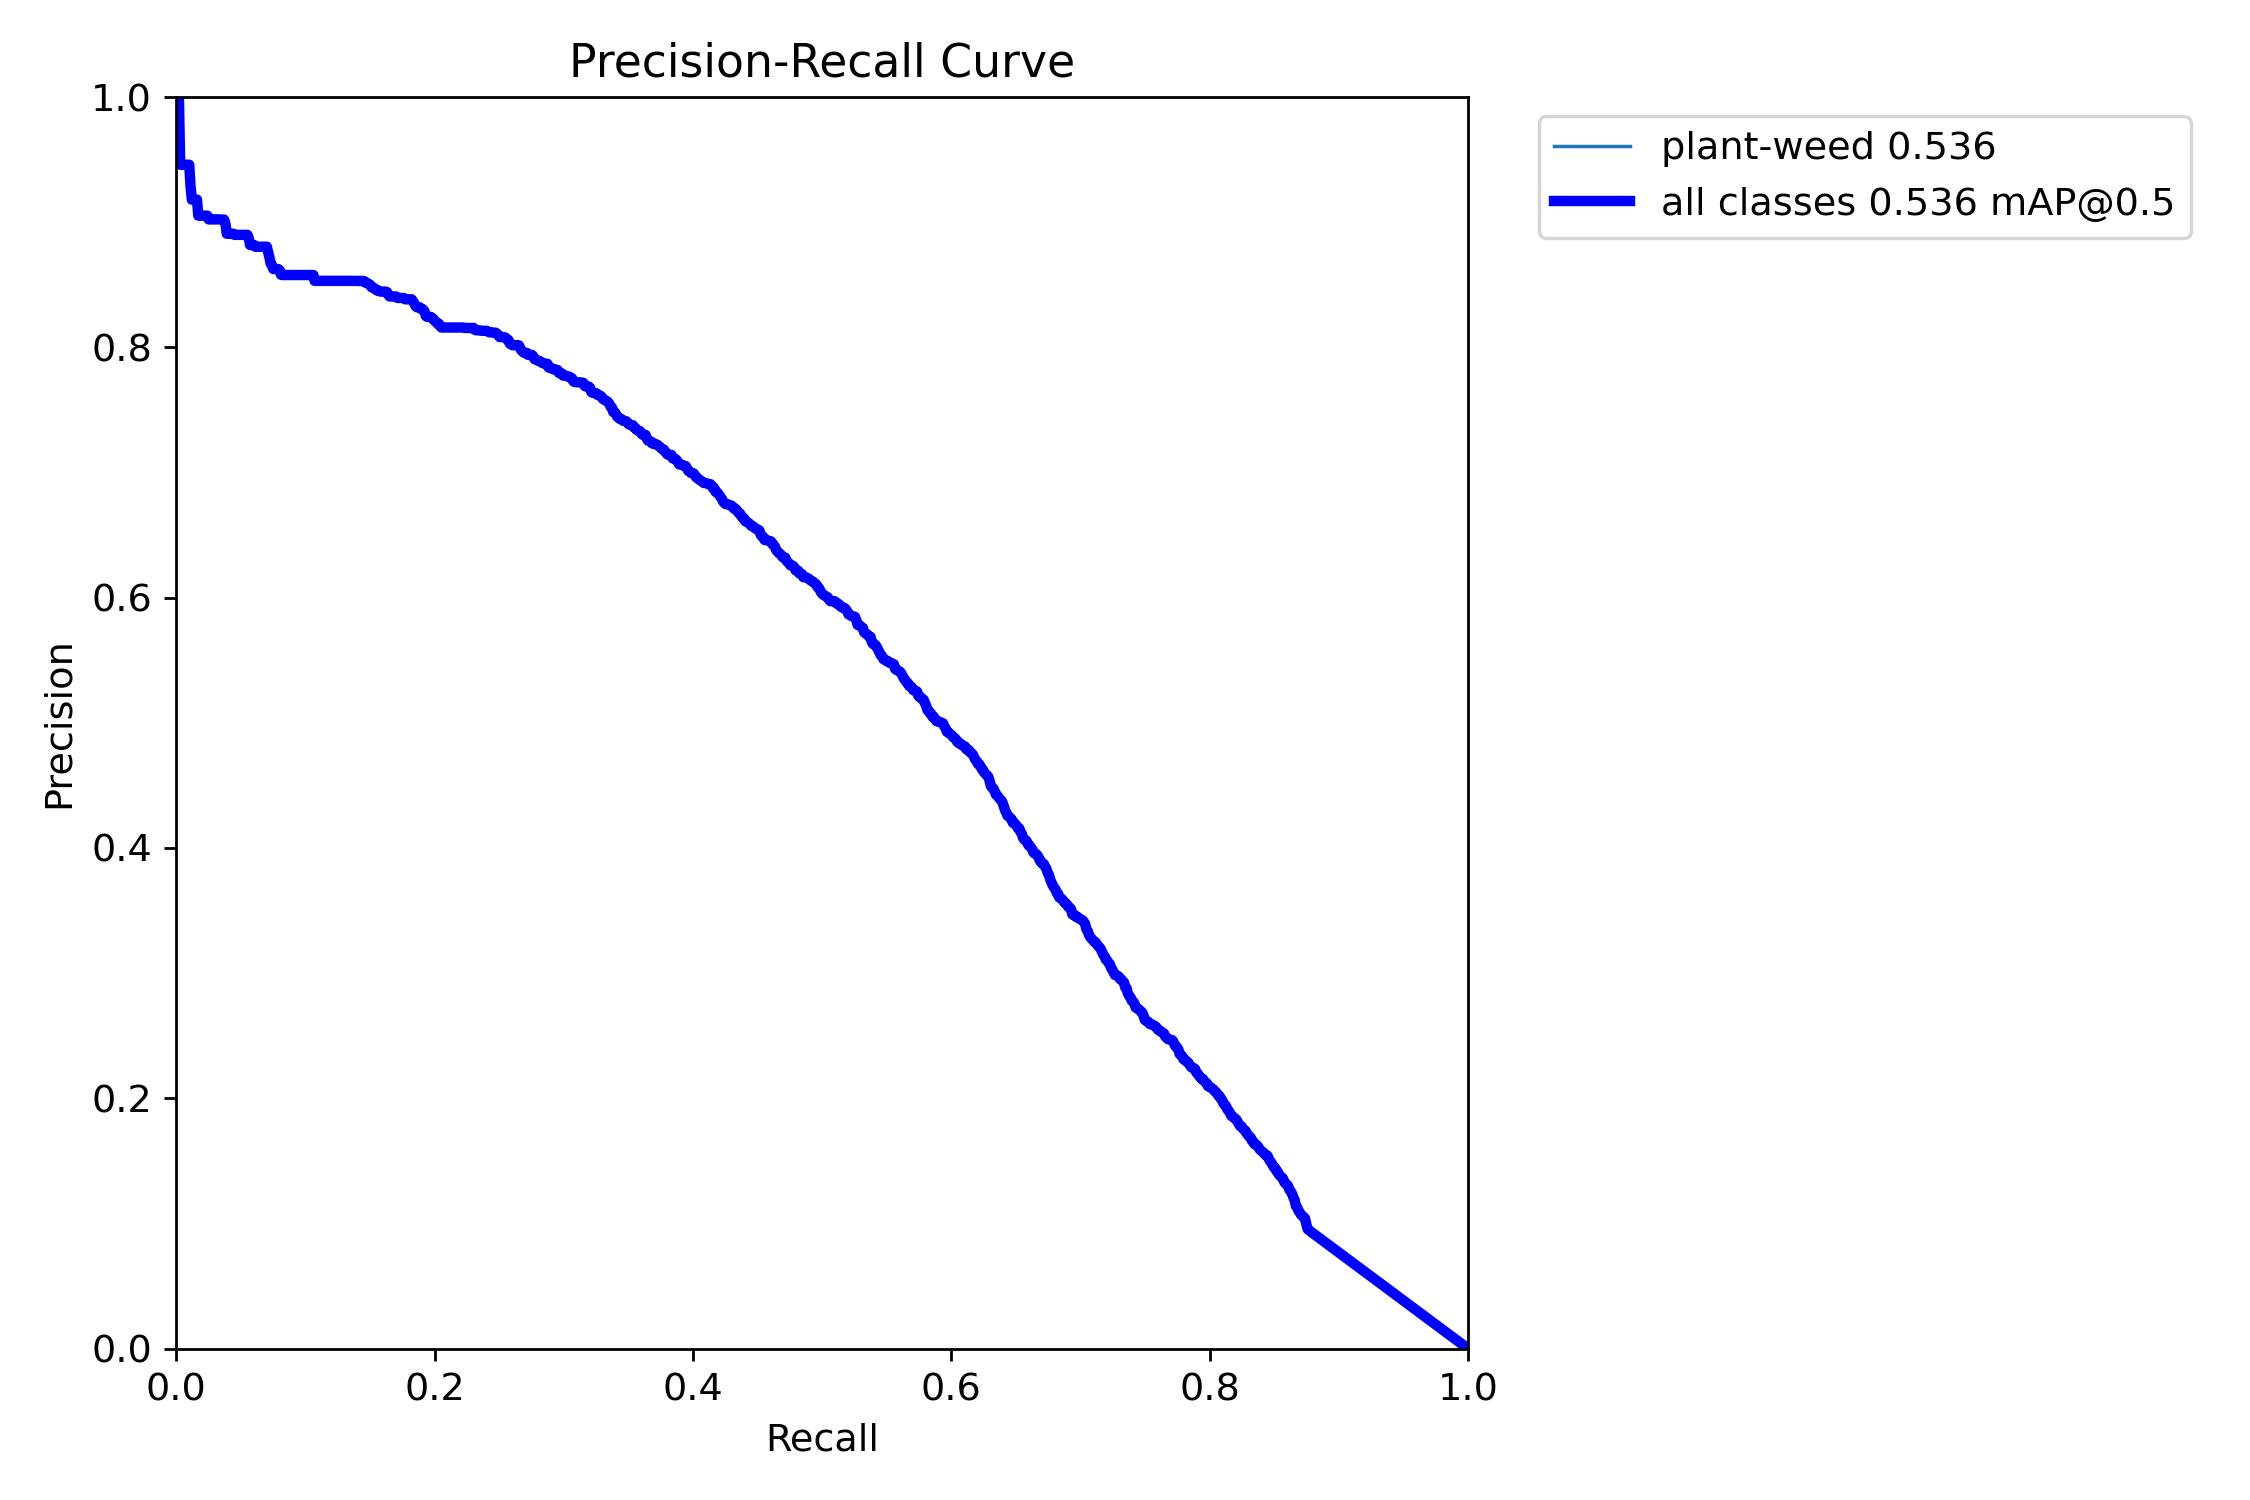

In [25]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

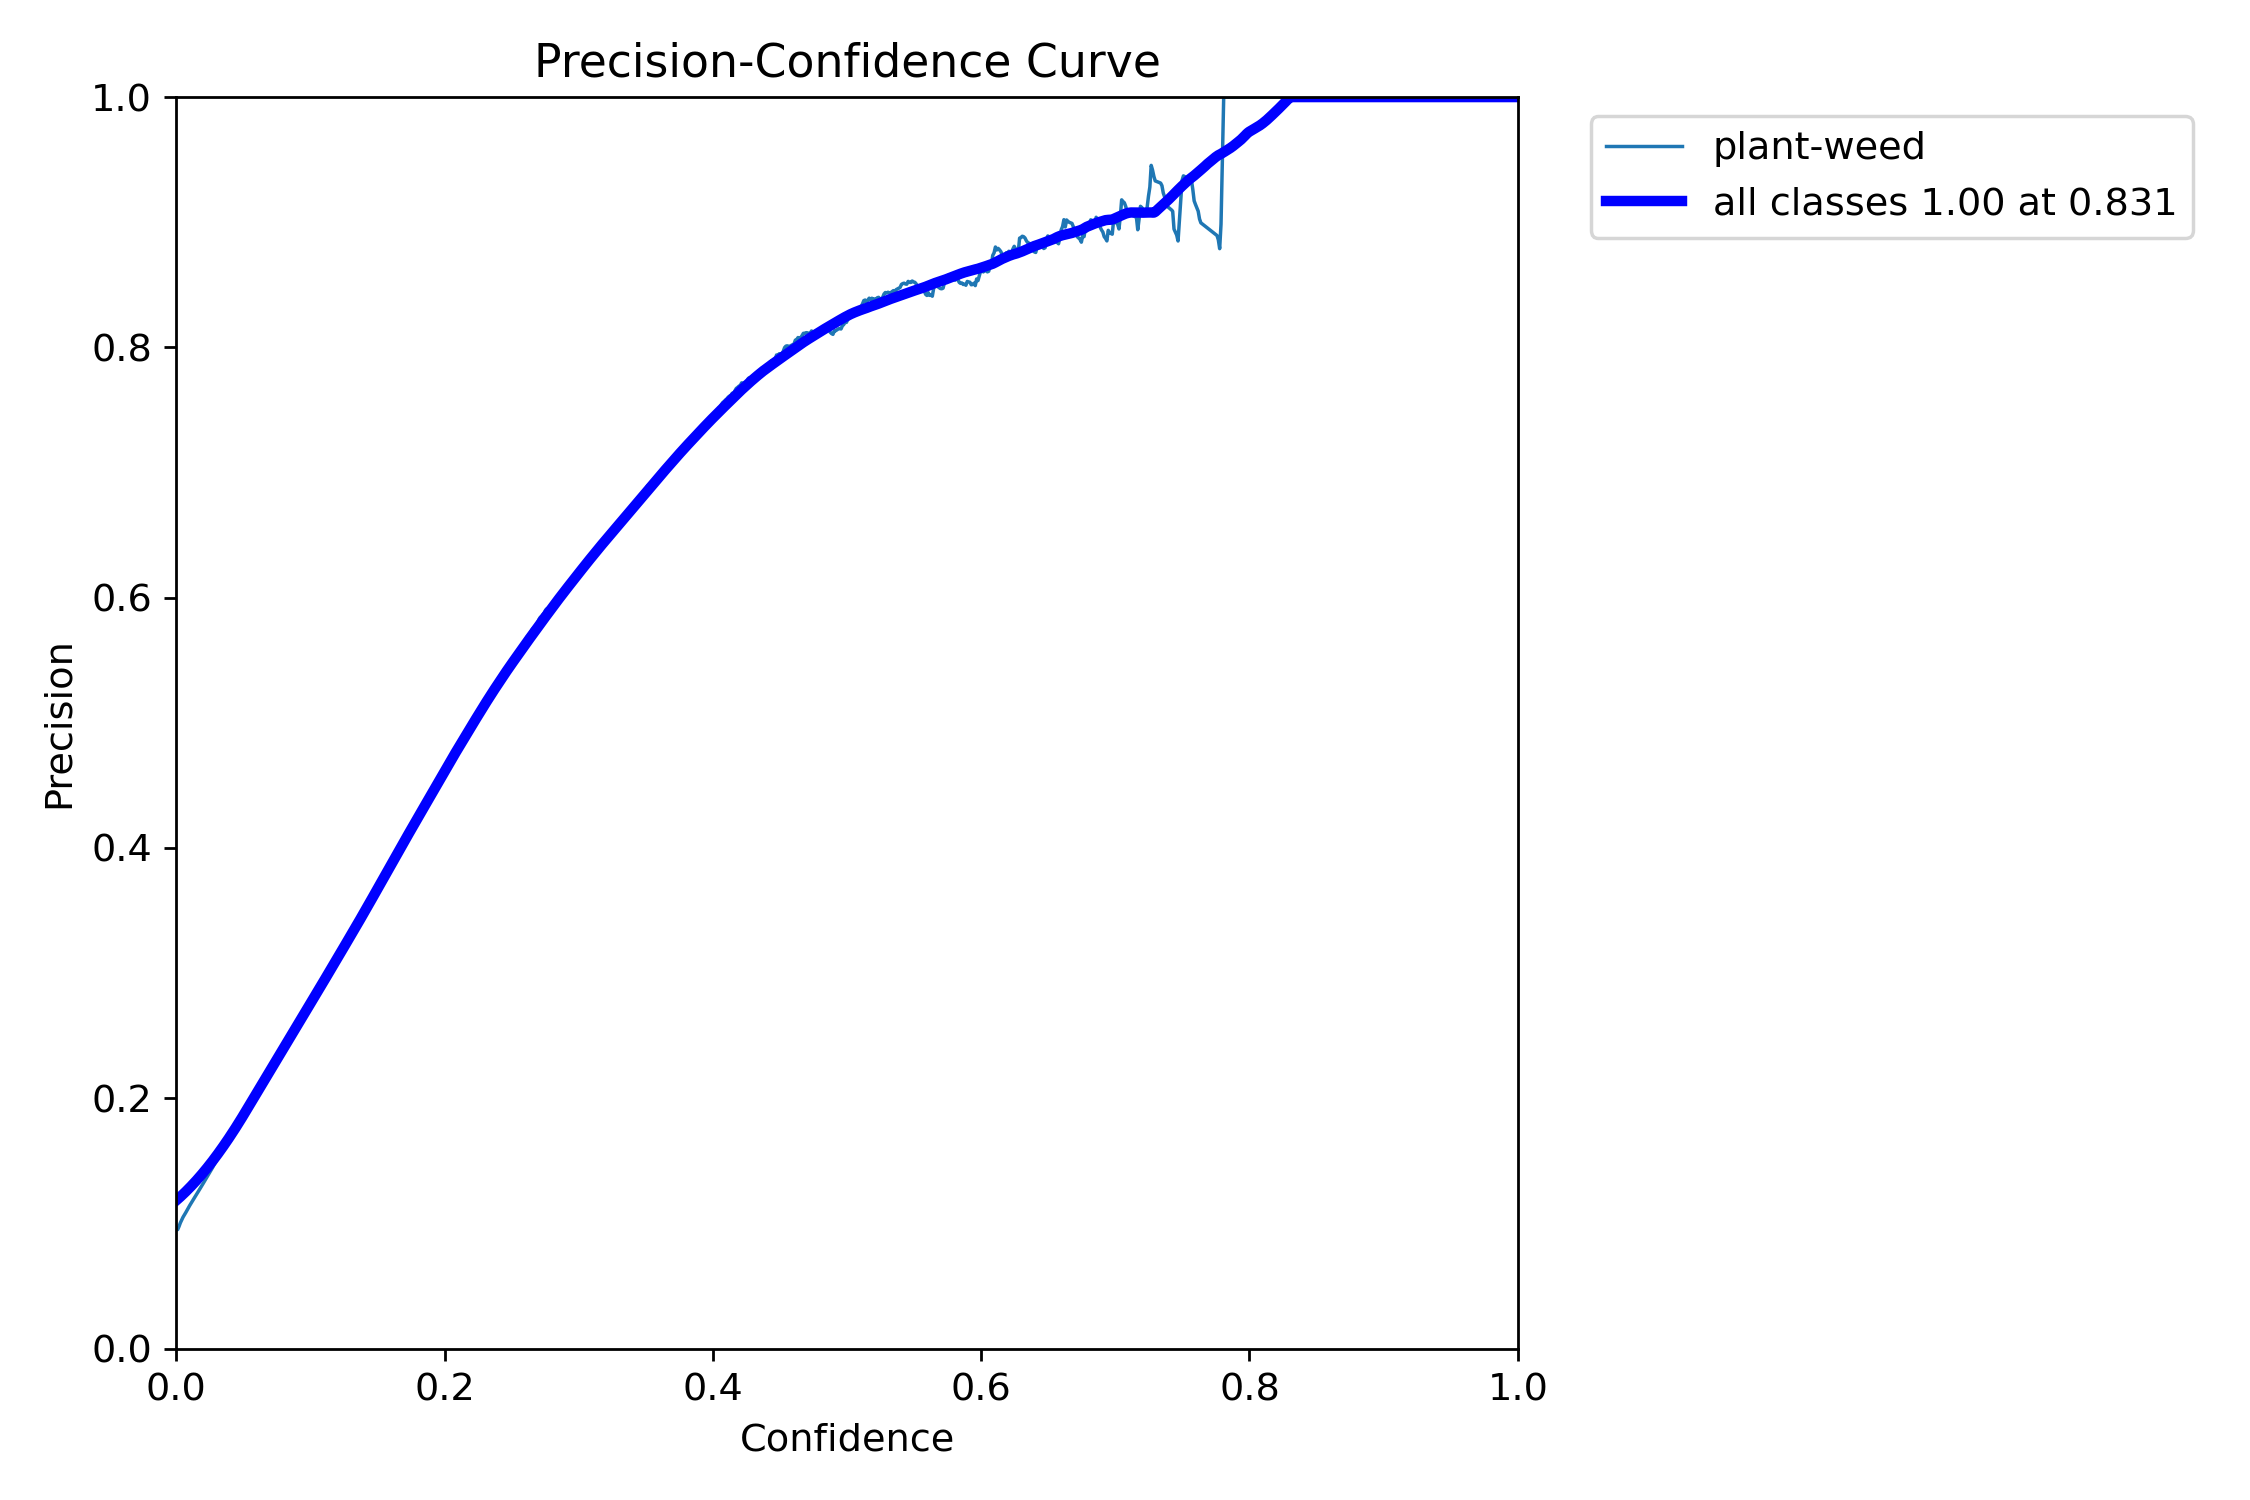

In [26]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

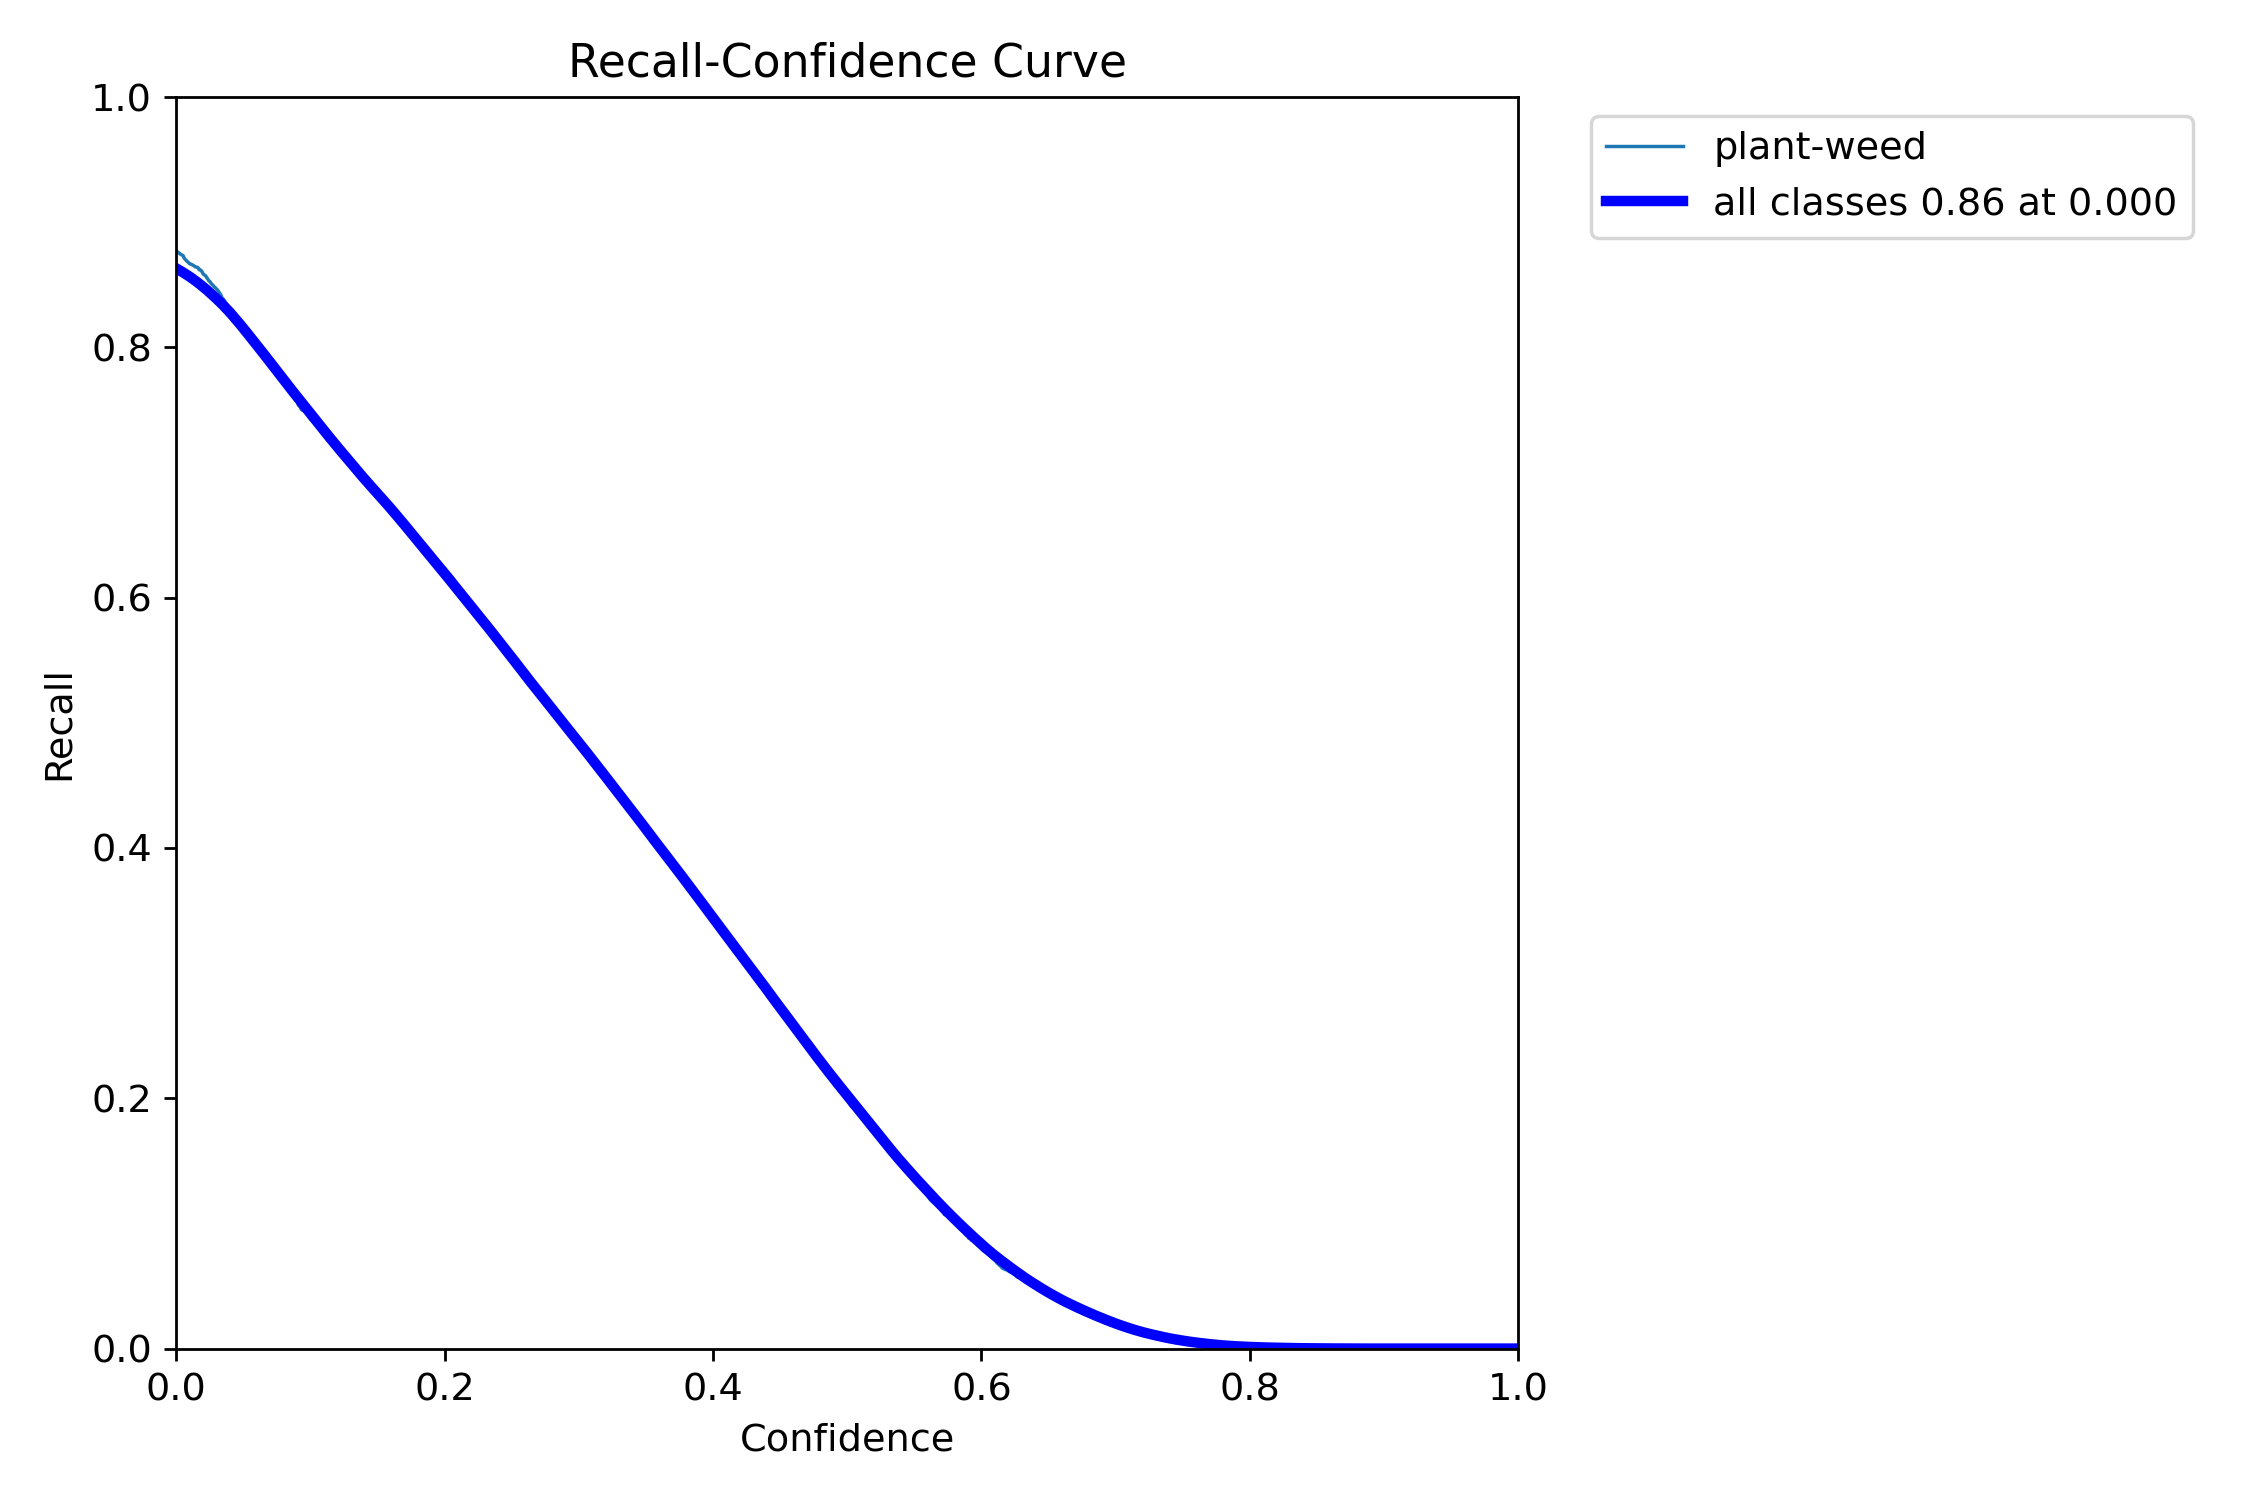

In [27]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

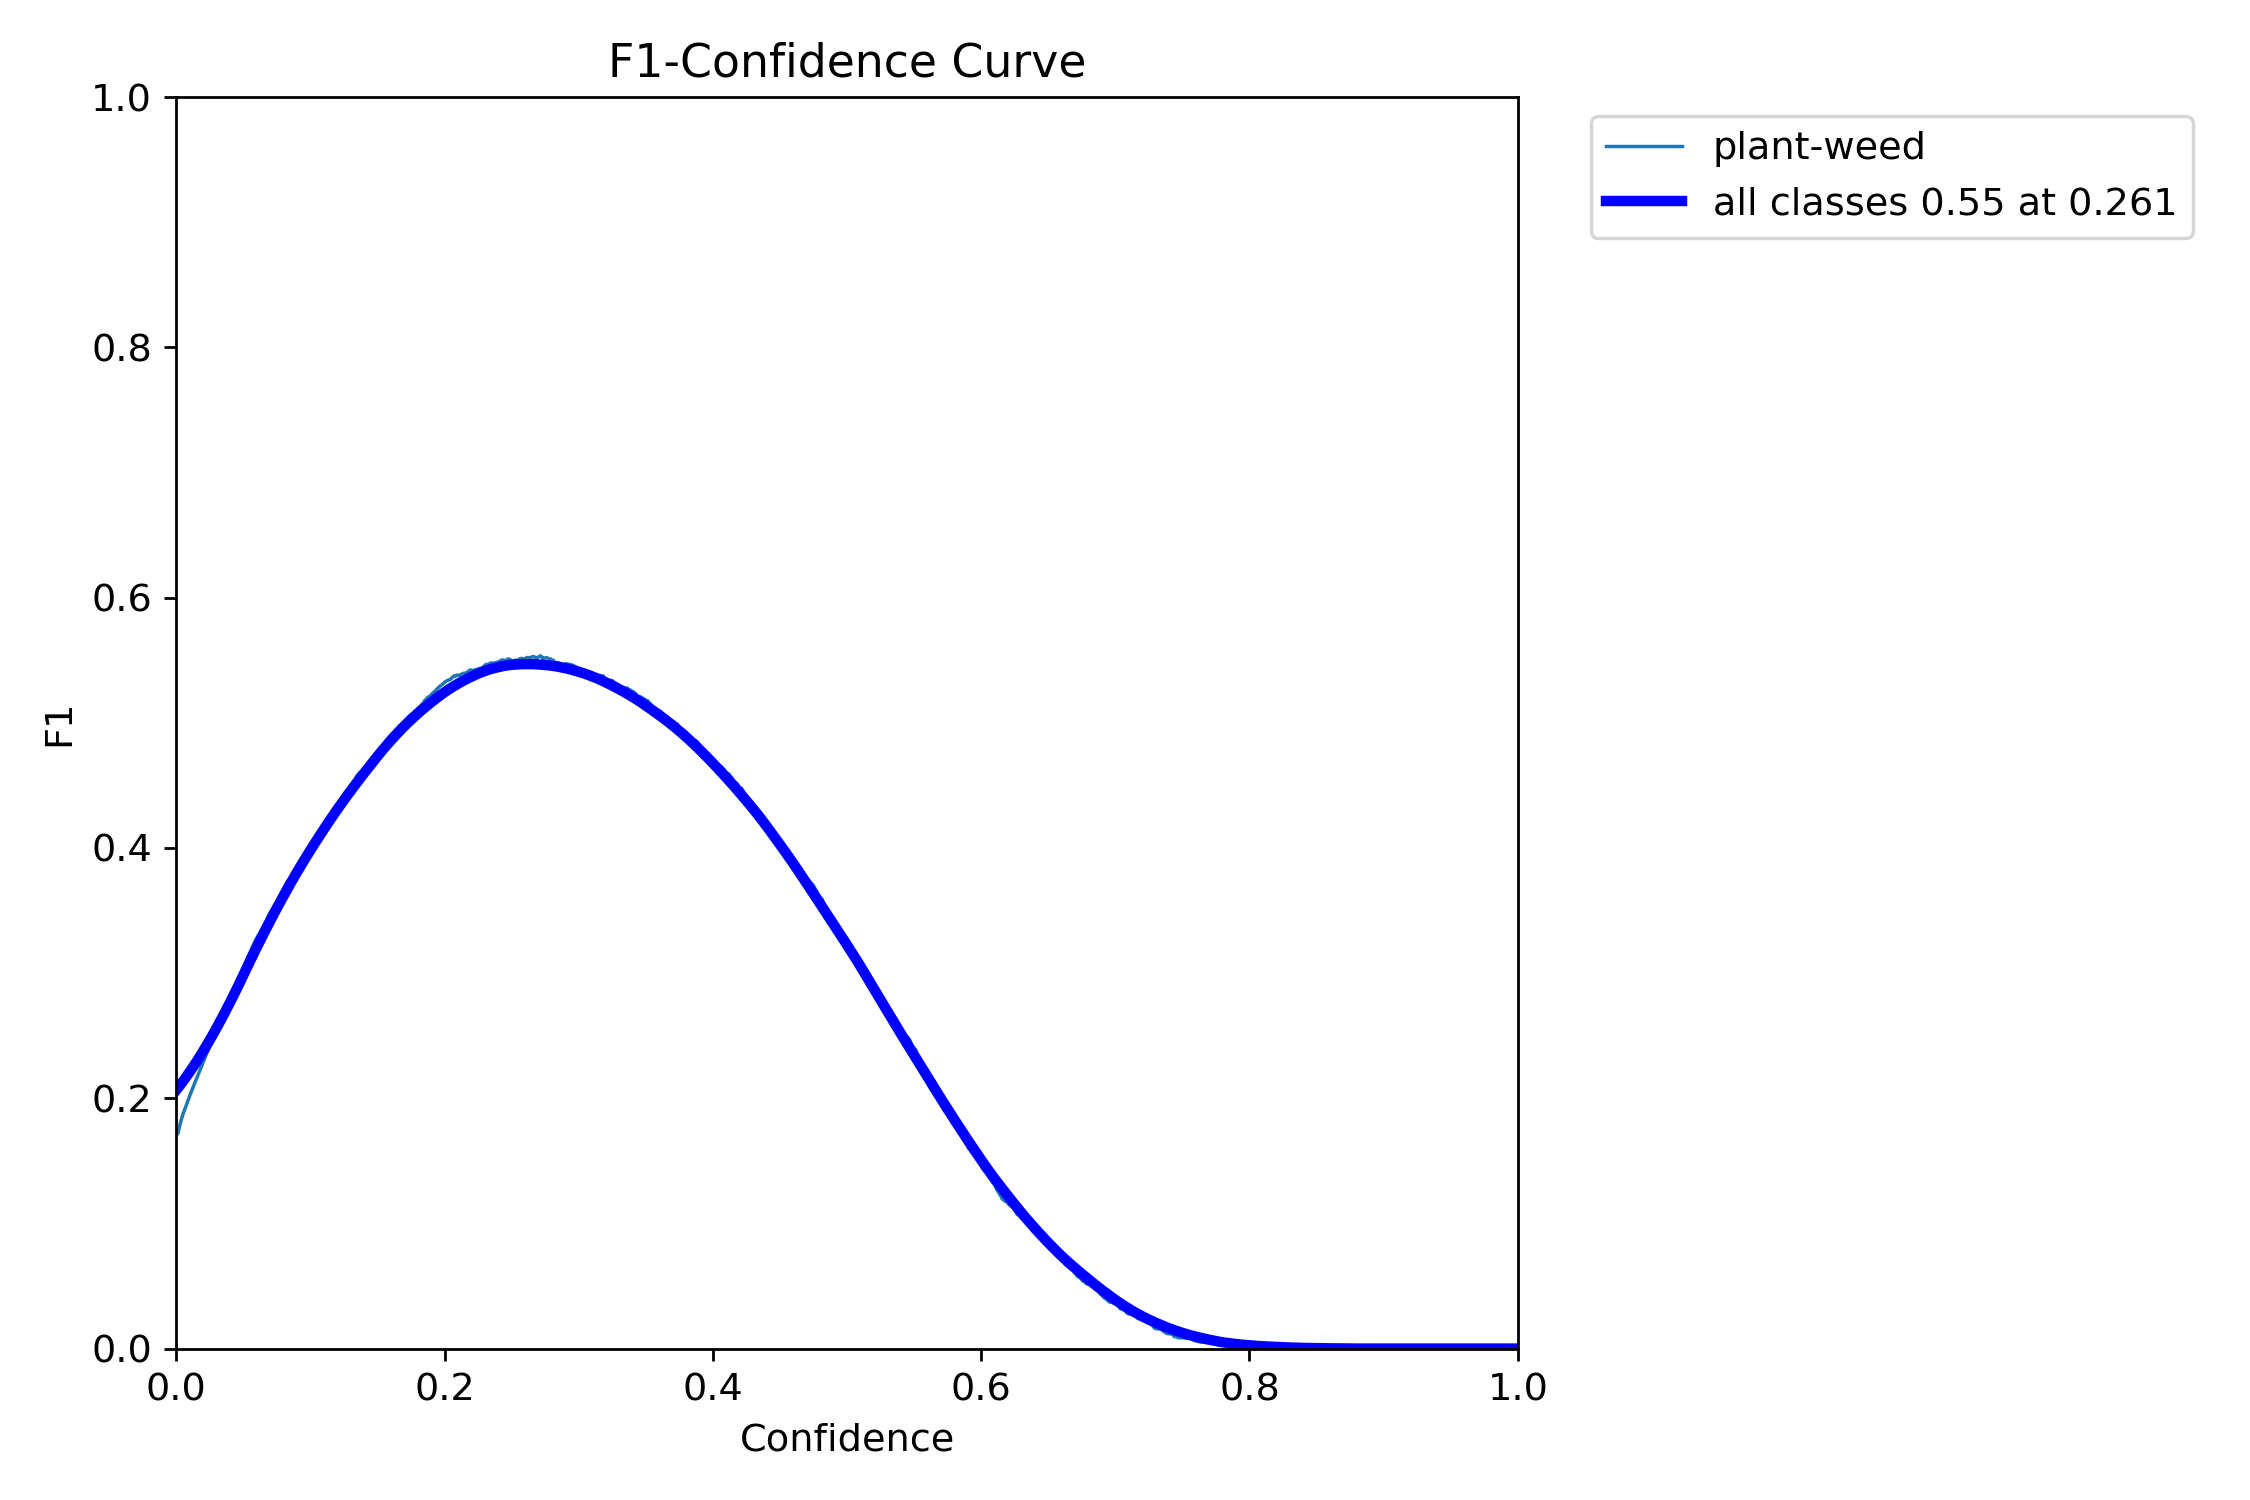

In [28]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

## Validation

In [29]:
folder = "val/"

#### Classification metrics

In [86]:
# Setting values from CM graph
TP = 2128
FP = 1125
FN = 1339

In [87]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4592

Confusion matrix:
[ 46.34% , 24.50% ]
[ 29.16% , 0.00% ]

Metrics:
- Accuracy: 0.463
- Precision: 0.654
- Recall: 0.614
- F1 Score: 0.633
- F½ Score: 0.646
- G-mean: 0.634


### Graphs

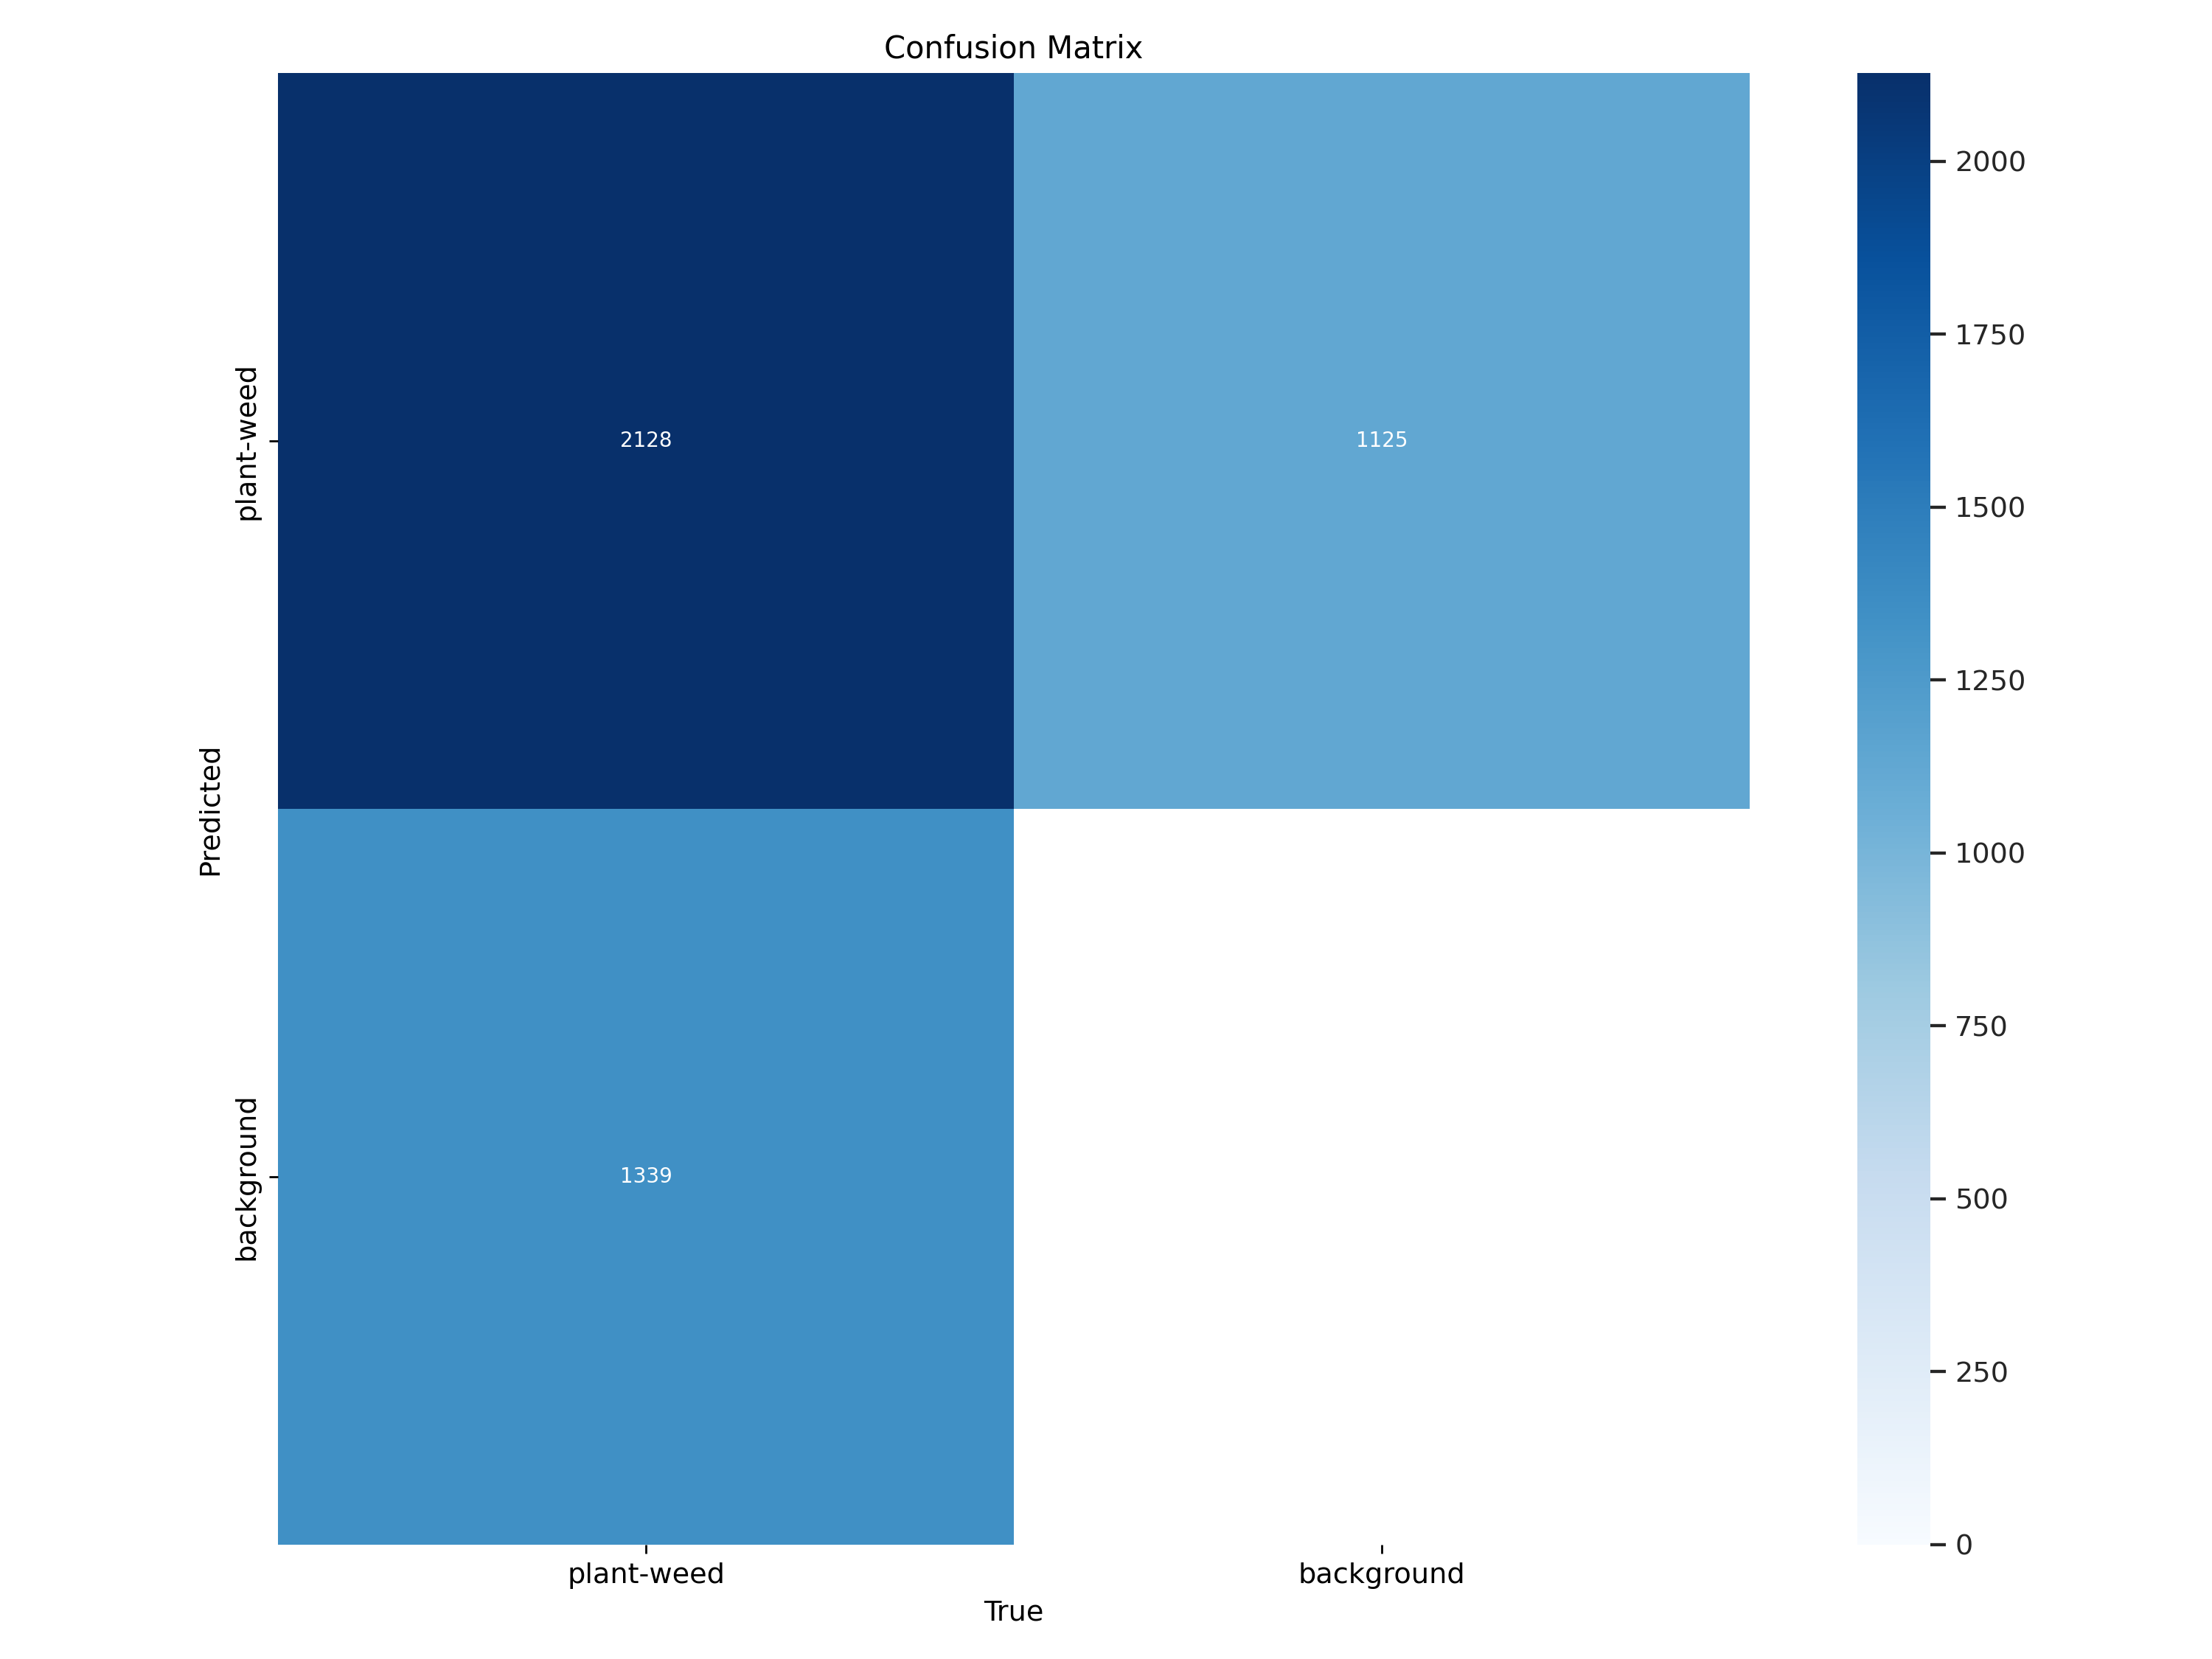

In [32]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

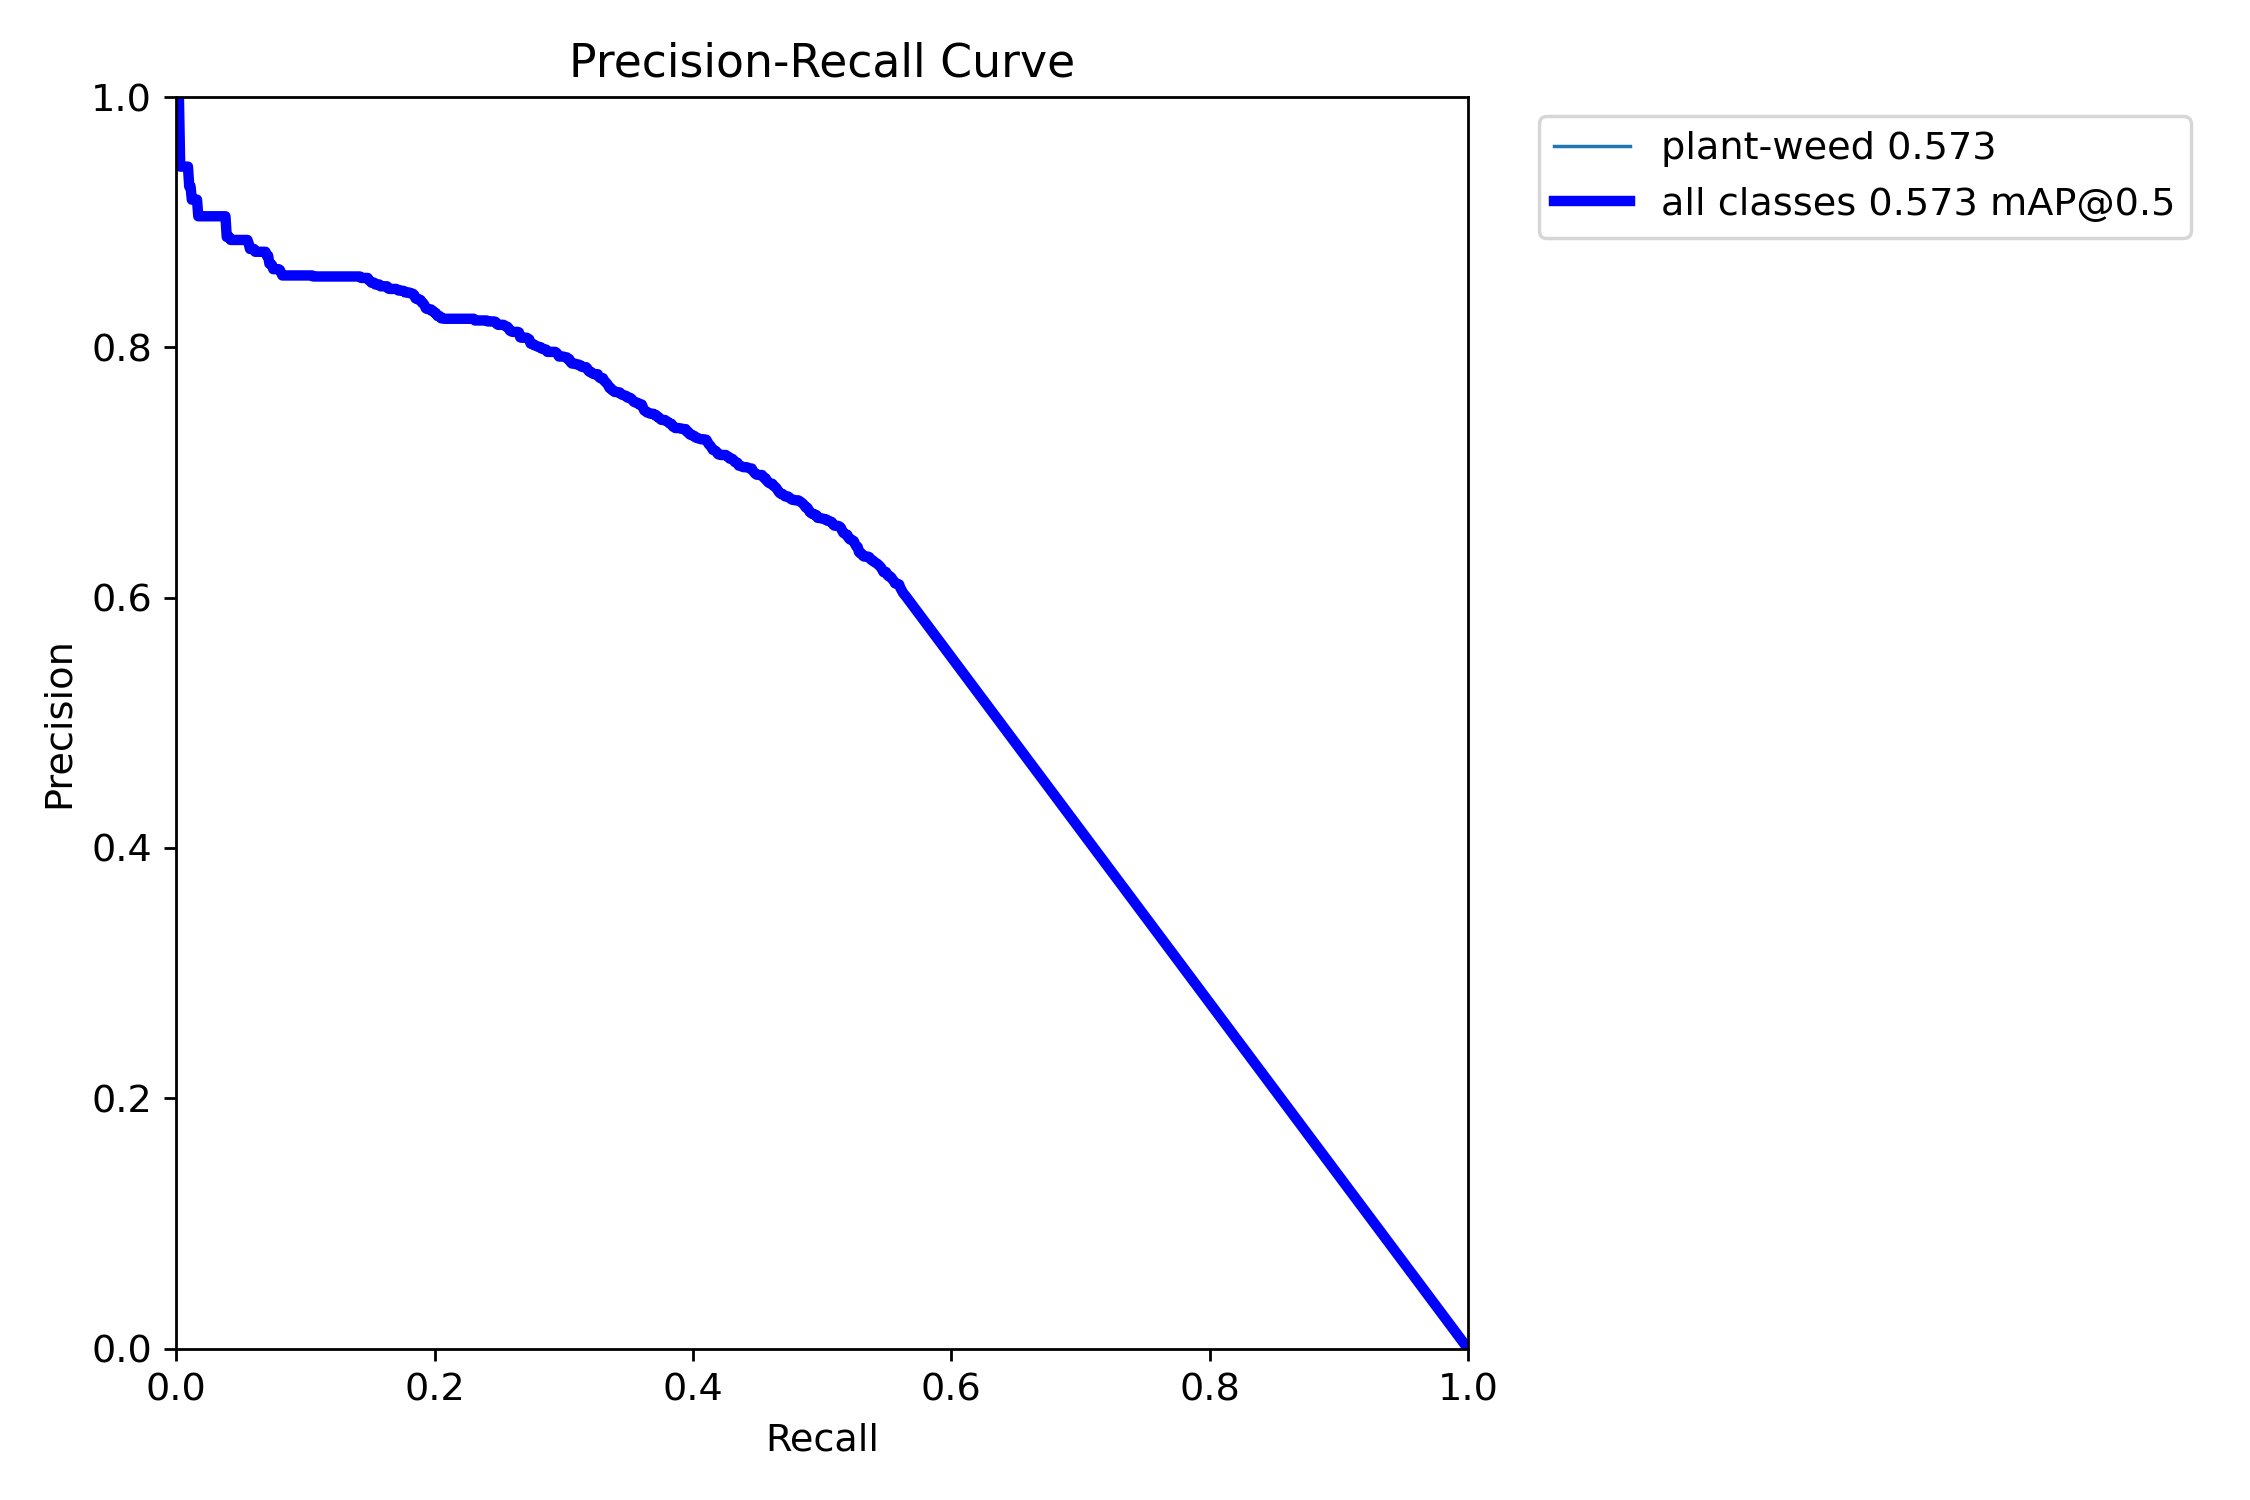

In [33]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

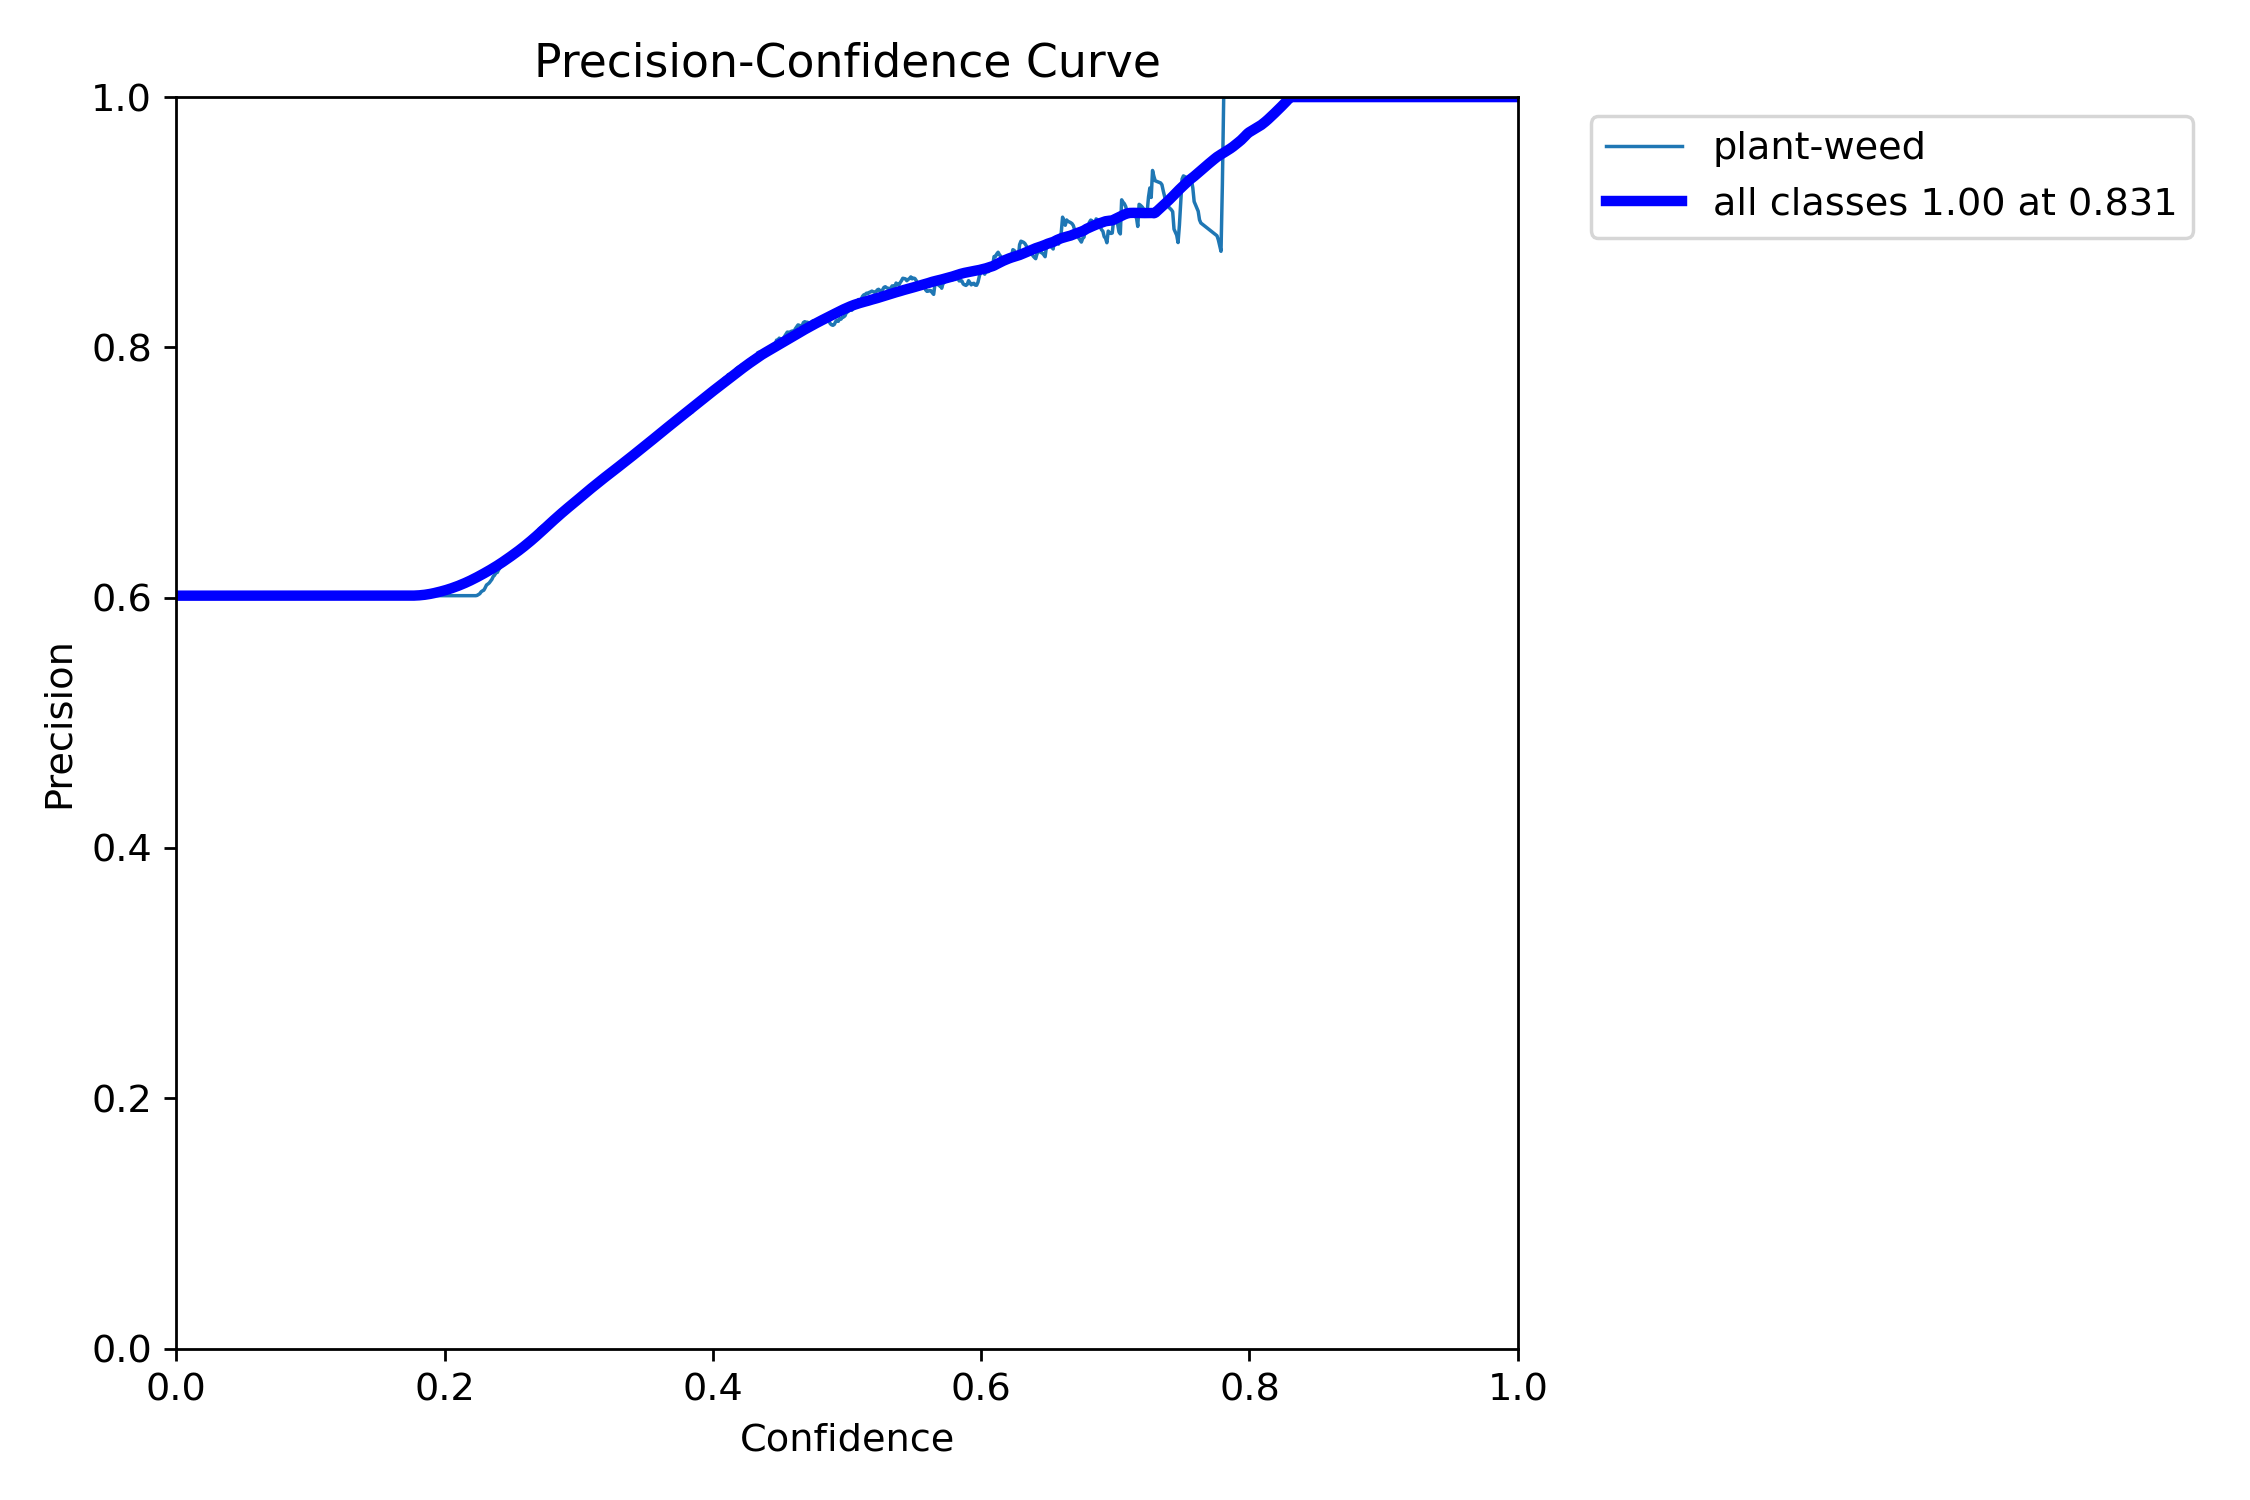

In [34]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

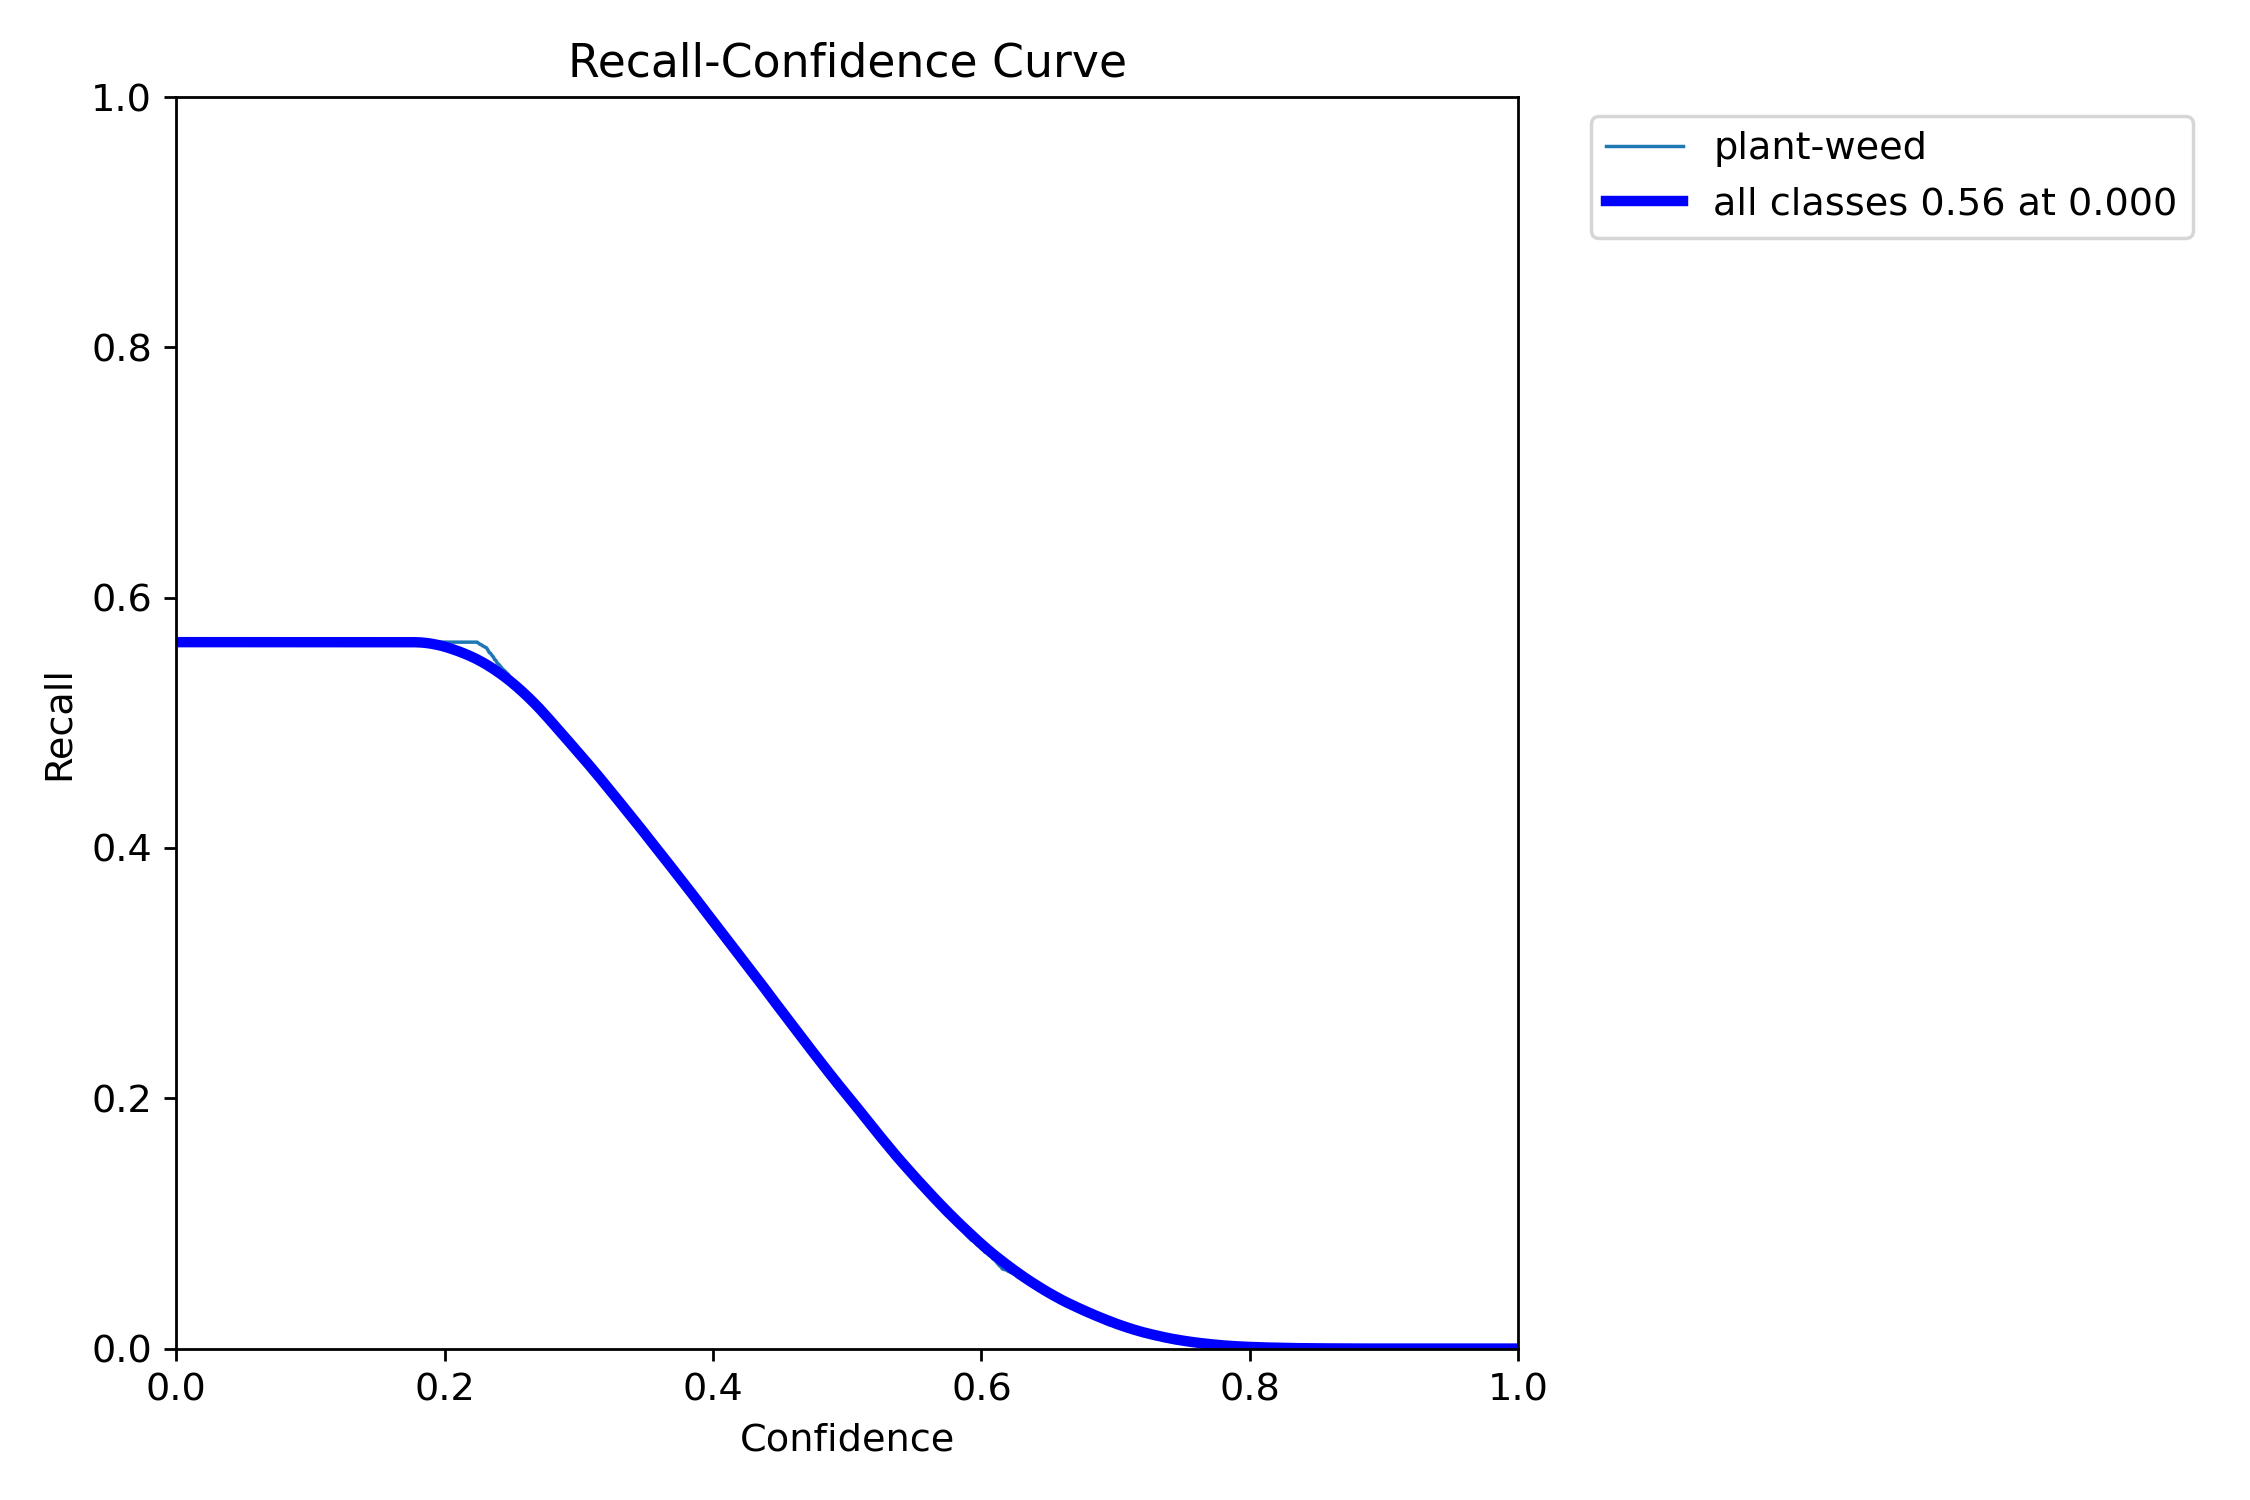

In [35]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

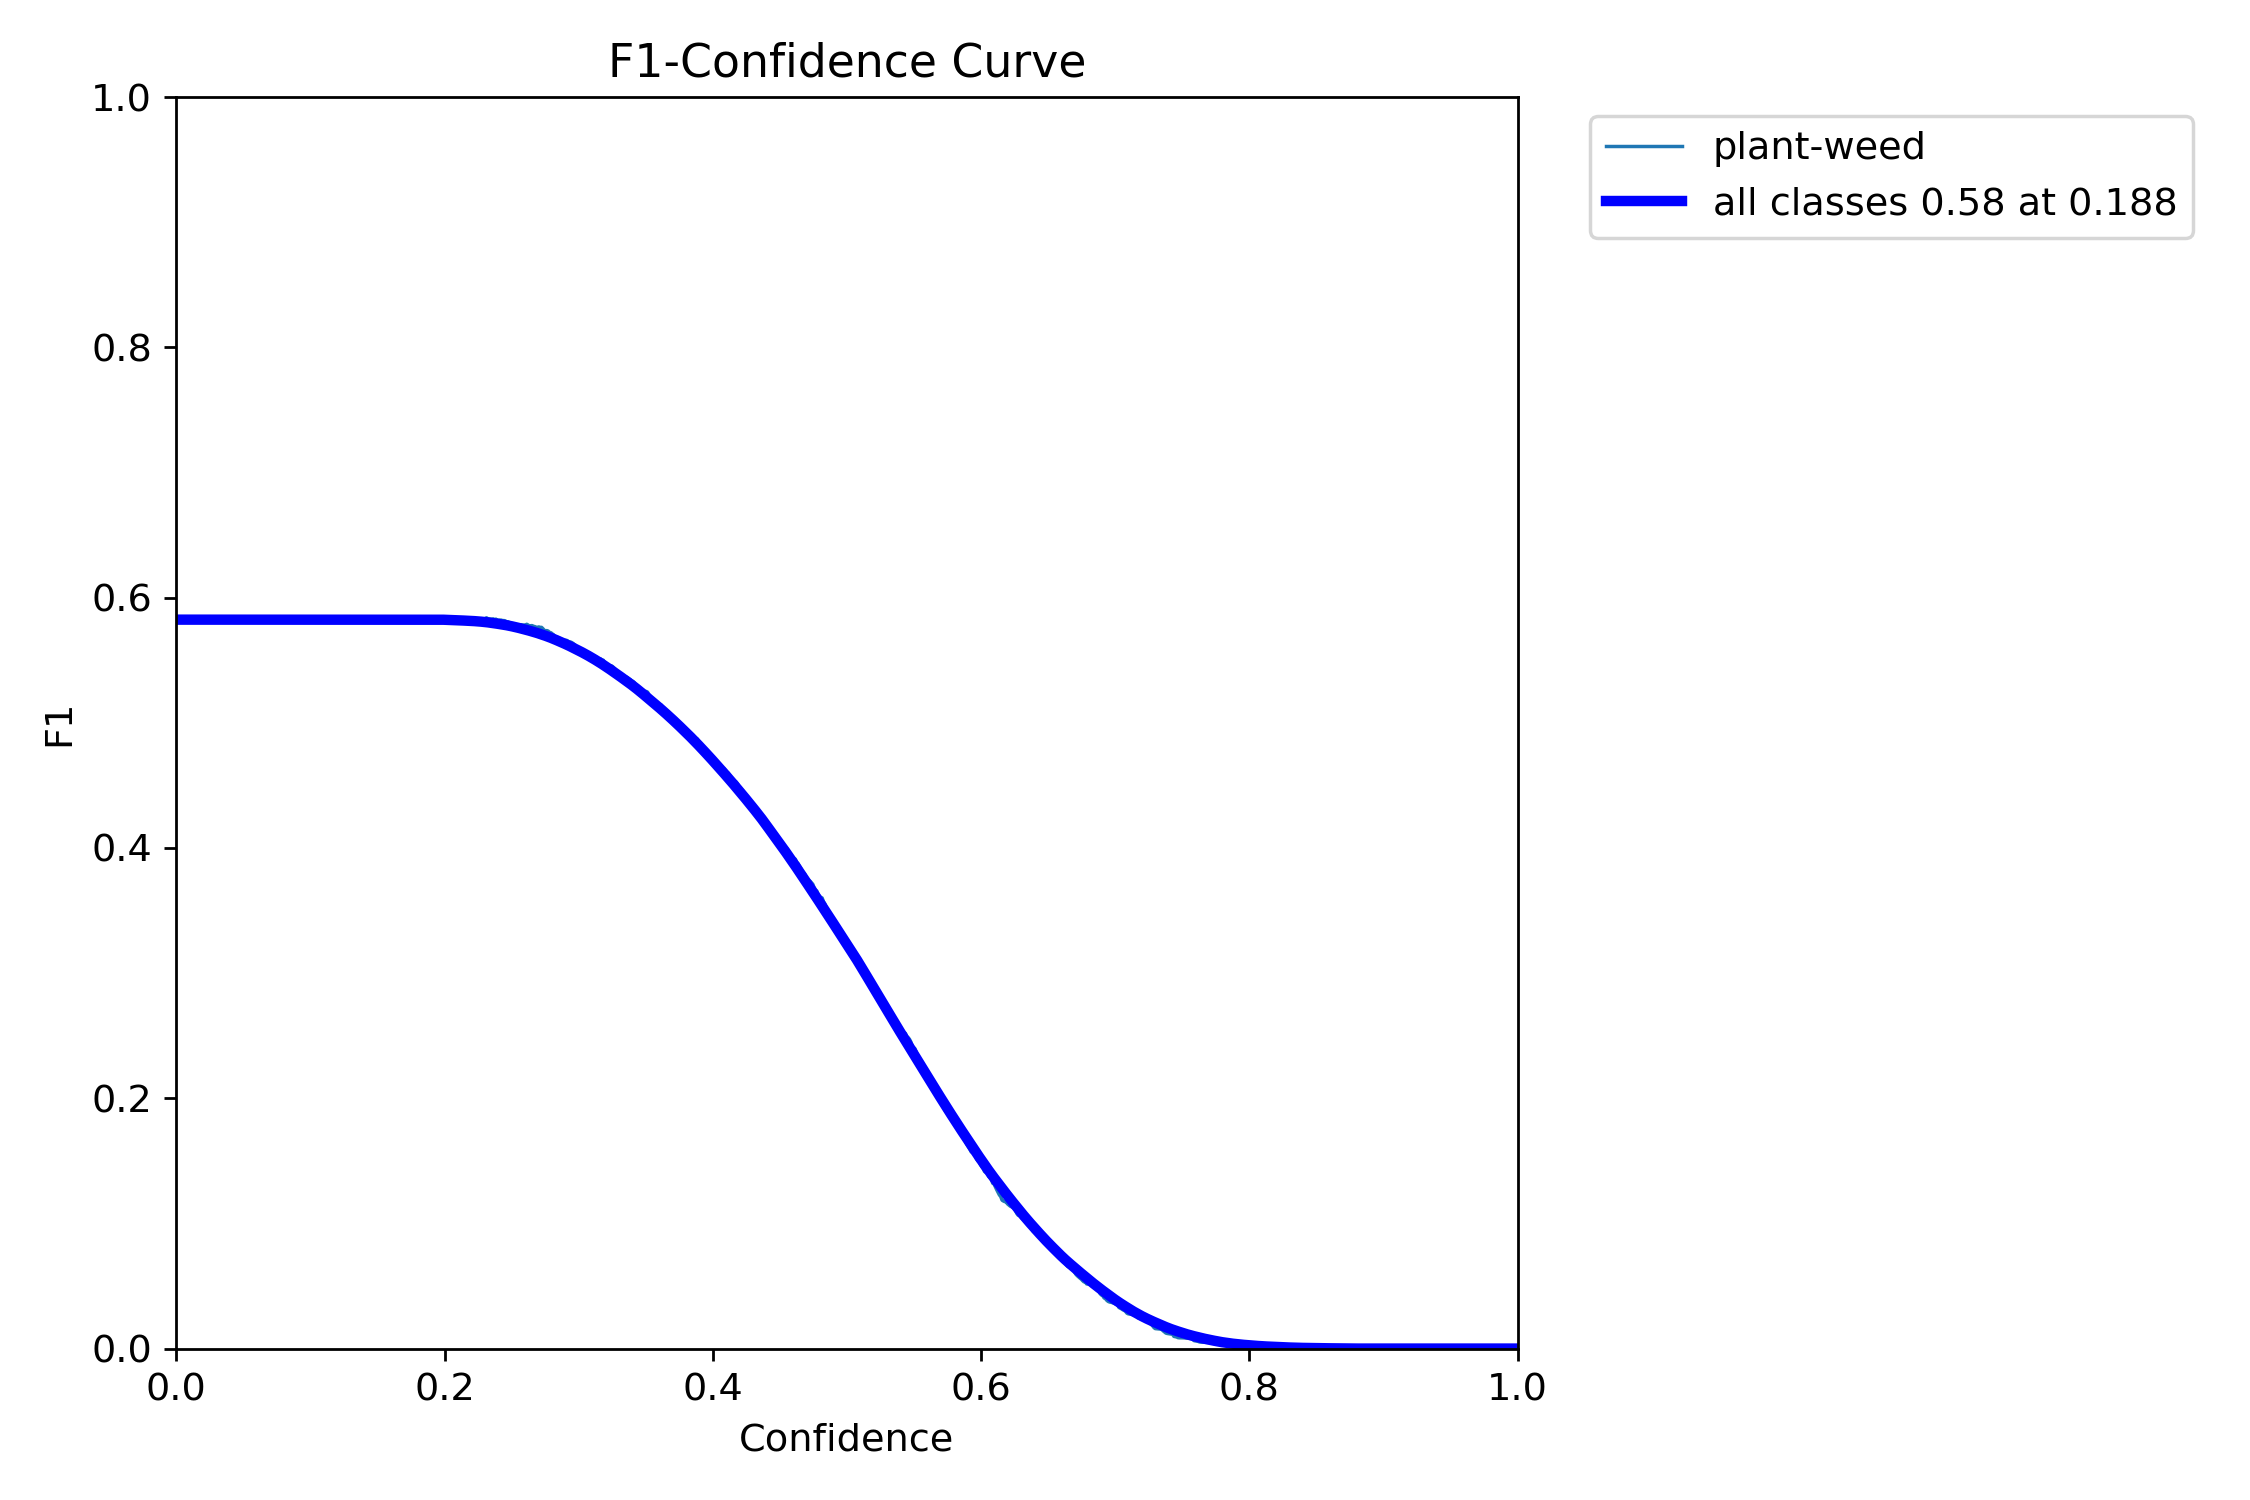

In [36]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

## Experiment 85
### *YOLOv8 Mid | exGreen images*
Images created by applying exGreen

In [37]:
folder = "train2/"

In [38]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
12,13,1389.68,1.31055,2.41197,1.36697,0.59136,0.52293,0.53296,0.18953,1.47684,2.71943,1.49306,0.003012,0.003012,0.003012
13,14,1497.71,1.28801,2.35762,1.35765,0.59360,0.52062,0.54345,0.19884,1.45415,2.70640,1.47874,0.002429,0.002429,0.002429
14,15,1600.17,1.27090,2.26672,1.32858,0.57142,0.53263,0.53508,0.19361,1.46428,2.70500,1.49027,0.001847,0.001847,0.001847
15,16,1703.91,1.25135,2.19392,1.31555,0.59704,0.53101,0.54616,0.19869,1.47716,2.64925,1.51030,0.001265,0.001265,0.001265
16,17,1802.91,1.24348,2.13770,1.30927,0.59627,0.53632,0.54914,0.20162,1.48170,2.62850,1.51412,0.000682,0.000682,0.000682


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [39]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 30.049 min


#### Best epoch

In [40]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
11,12,1284.0,1.31999,2.47617,1.37952,0.58862,0.5336,0.55066,0.20153,1.44084,2.73333,1.47046,0.003594,0.003594,0.003594,30.0485


In [41]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 12 con mAP50 de 0.551


In [42]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [82]:
# Setting values from CM graph
TP = 1970
FP = 1036
FN = 1497

In [83]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4503

Confusion matrix:
[ 43.75% , 23.01% ]
[ 33.24% , 0.00% ]

Metrics:
- Accuracy: 0.437
- Precision: 0.655
- Recall: 0.568
- F1 Score: 0.609
- F½ Score: 0.636
- G-mean: 0.610


### Graphs

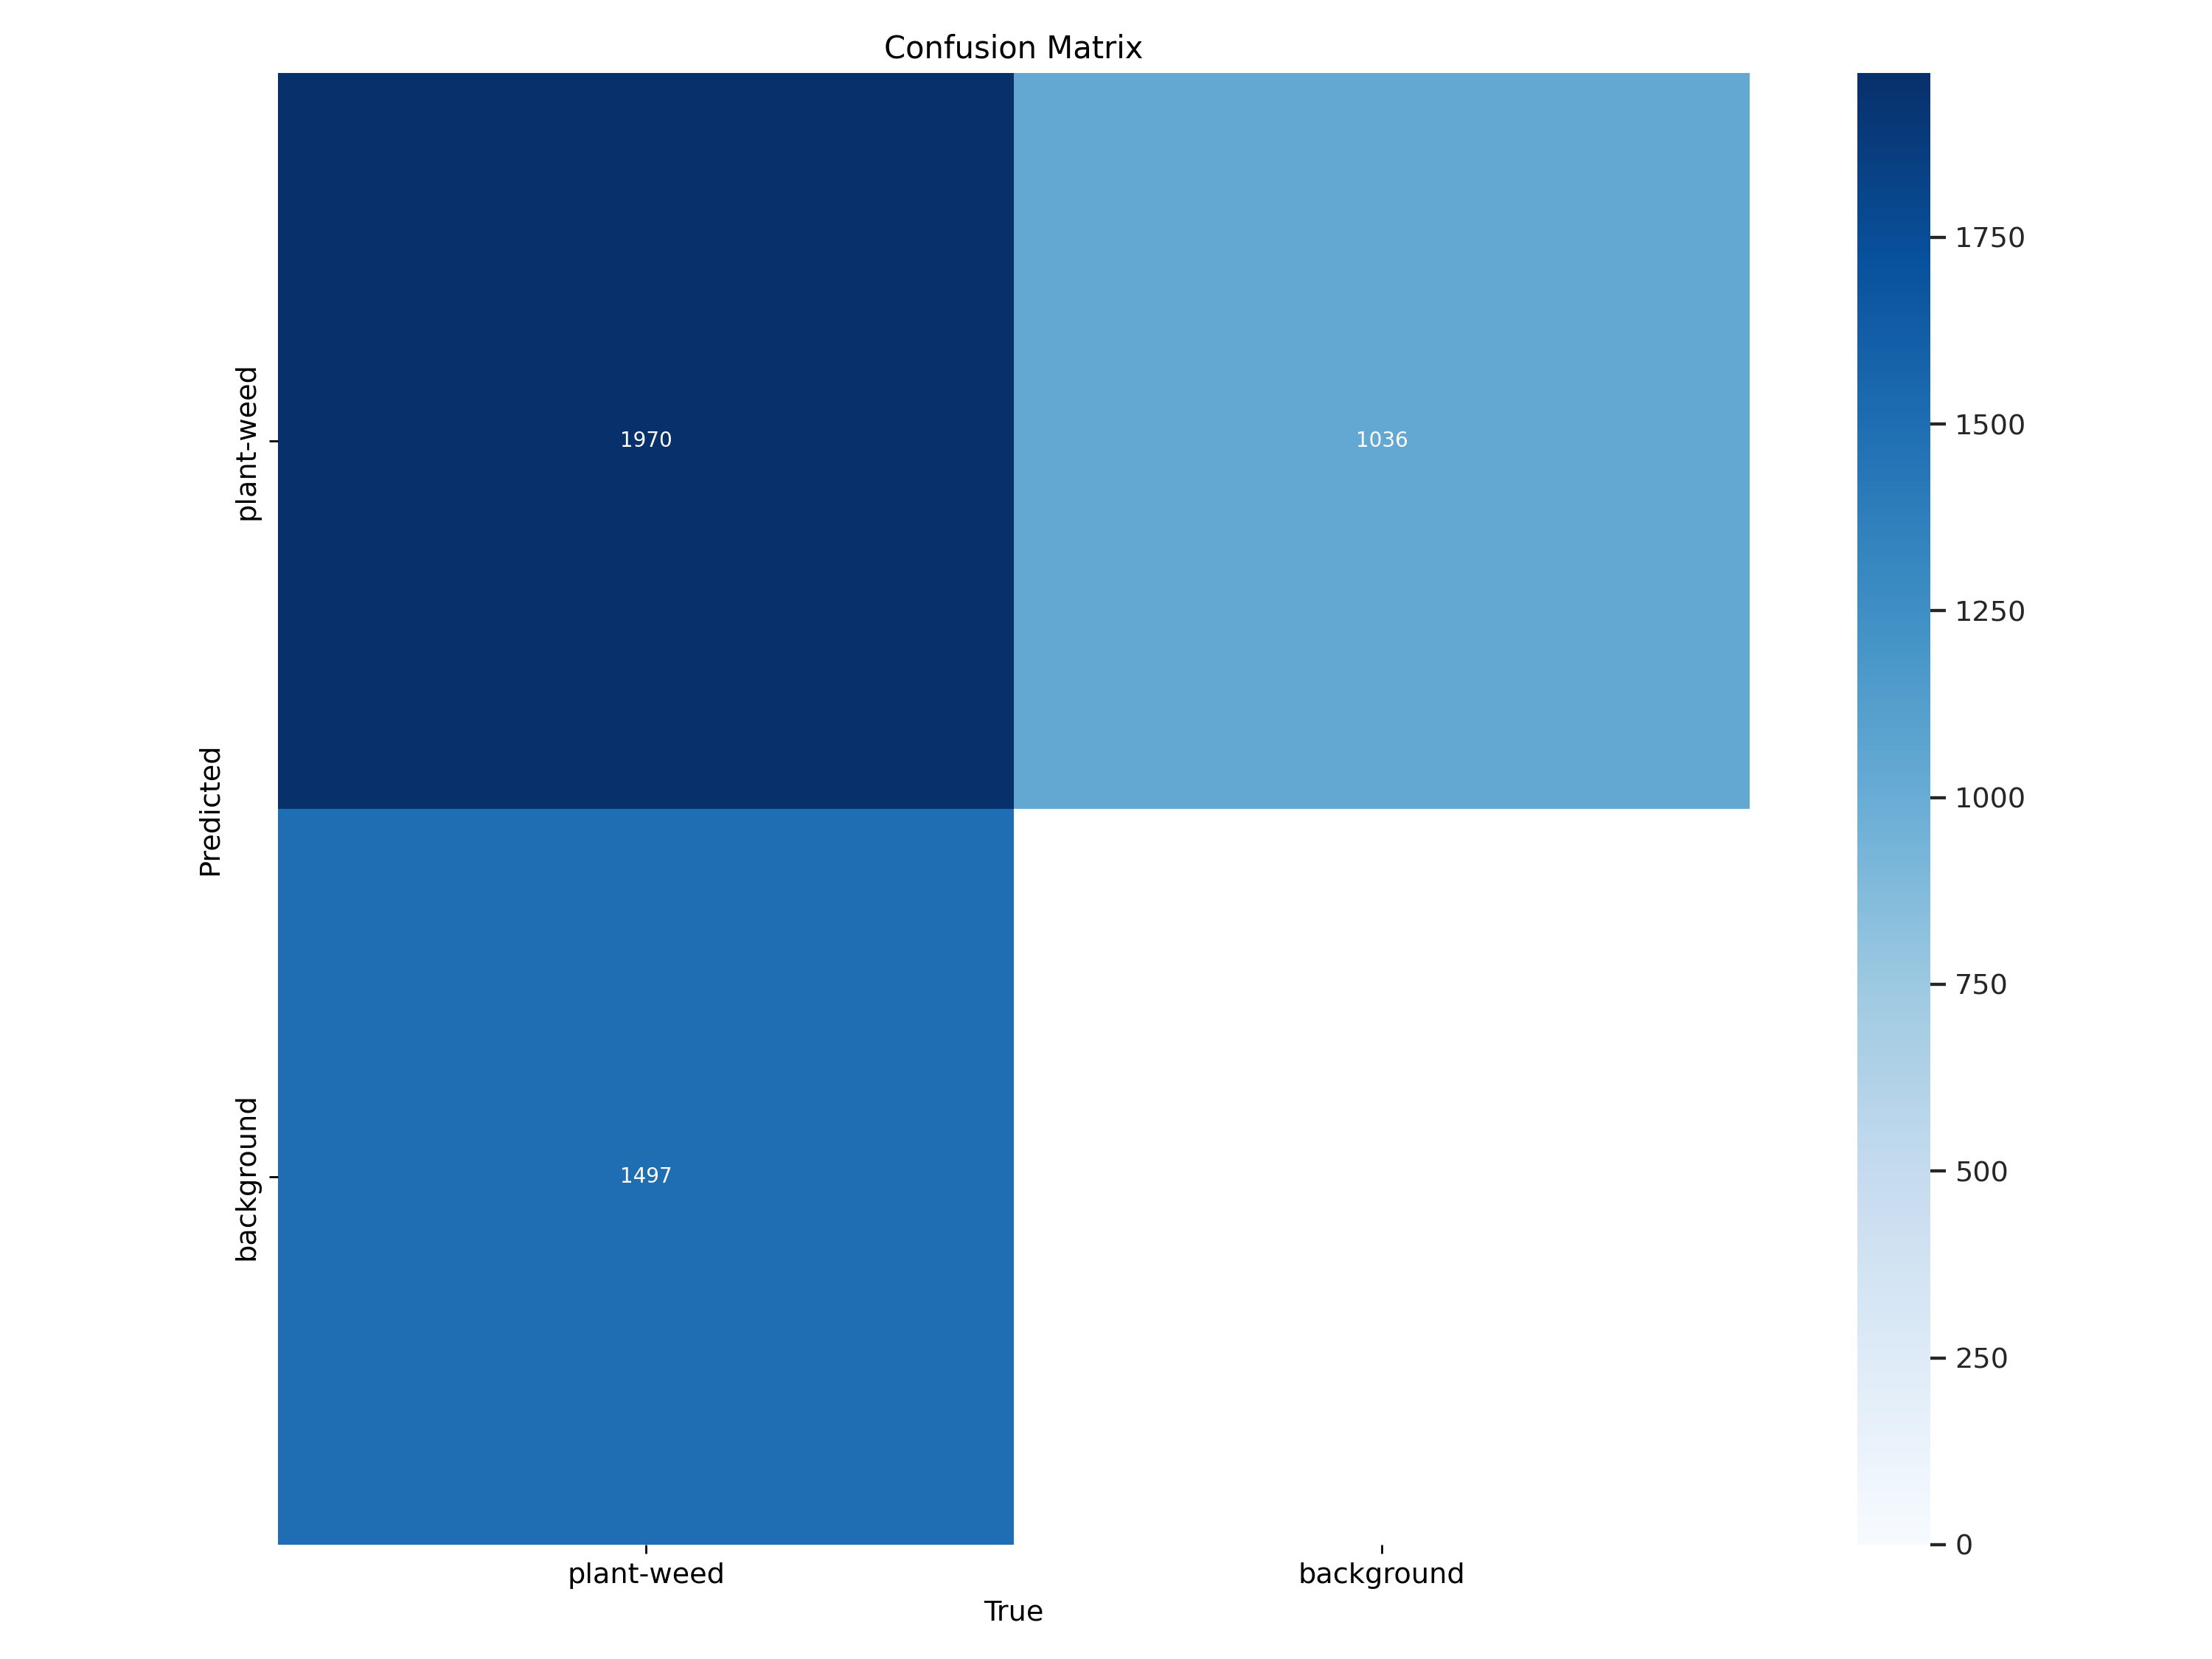

In [45]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

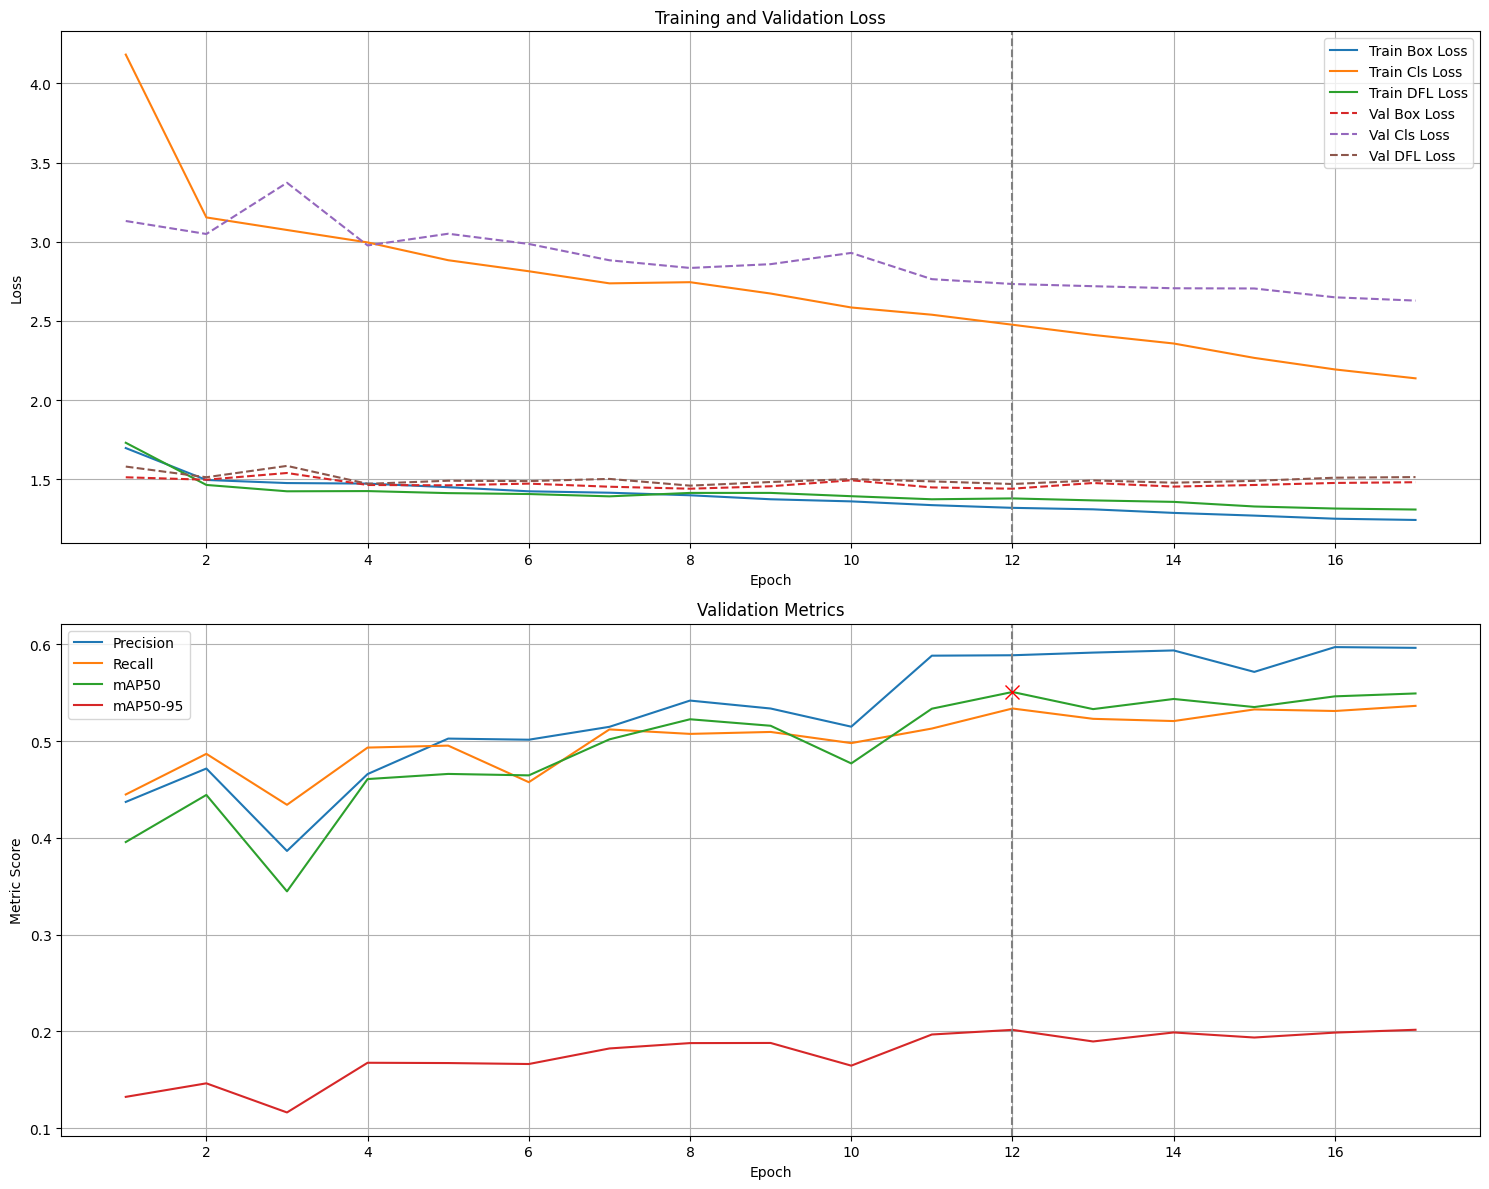

In [46]:
graph_training_metrics(df, epoch, graph="full")

In [47]:
graph_LrLoss_3D(df)

Validation set


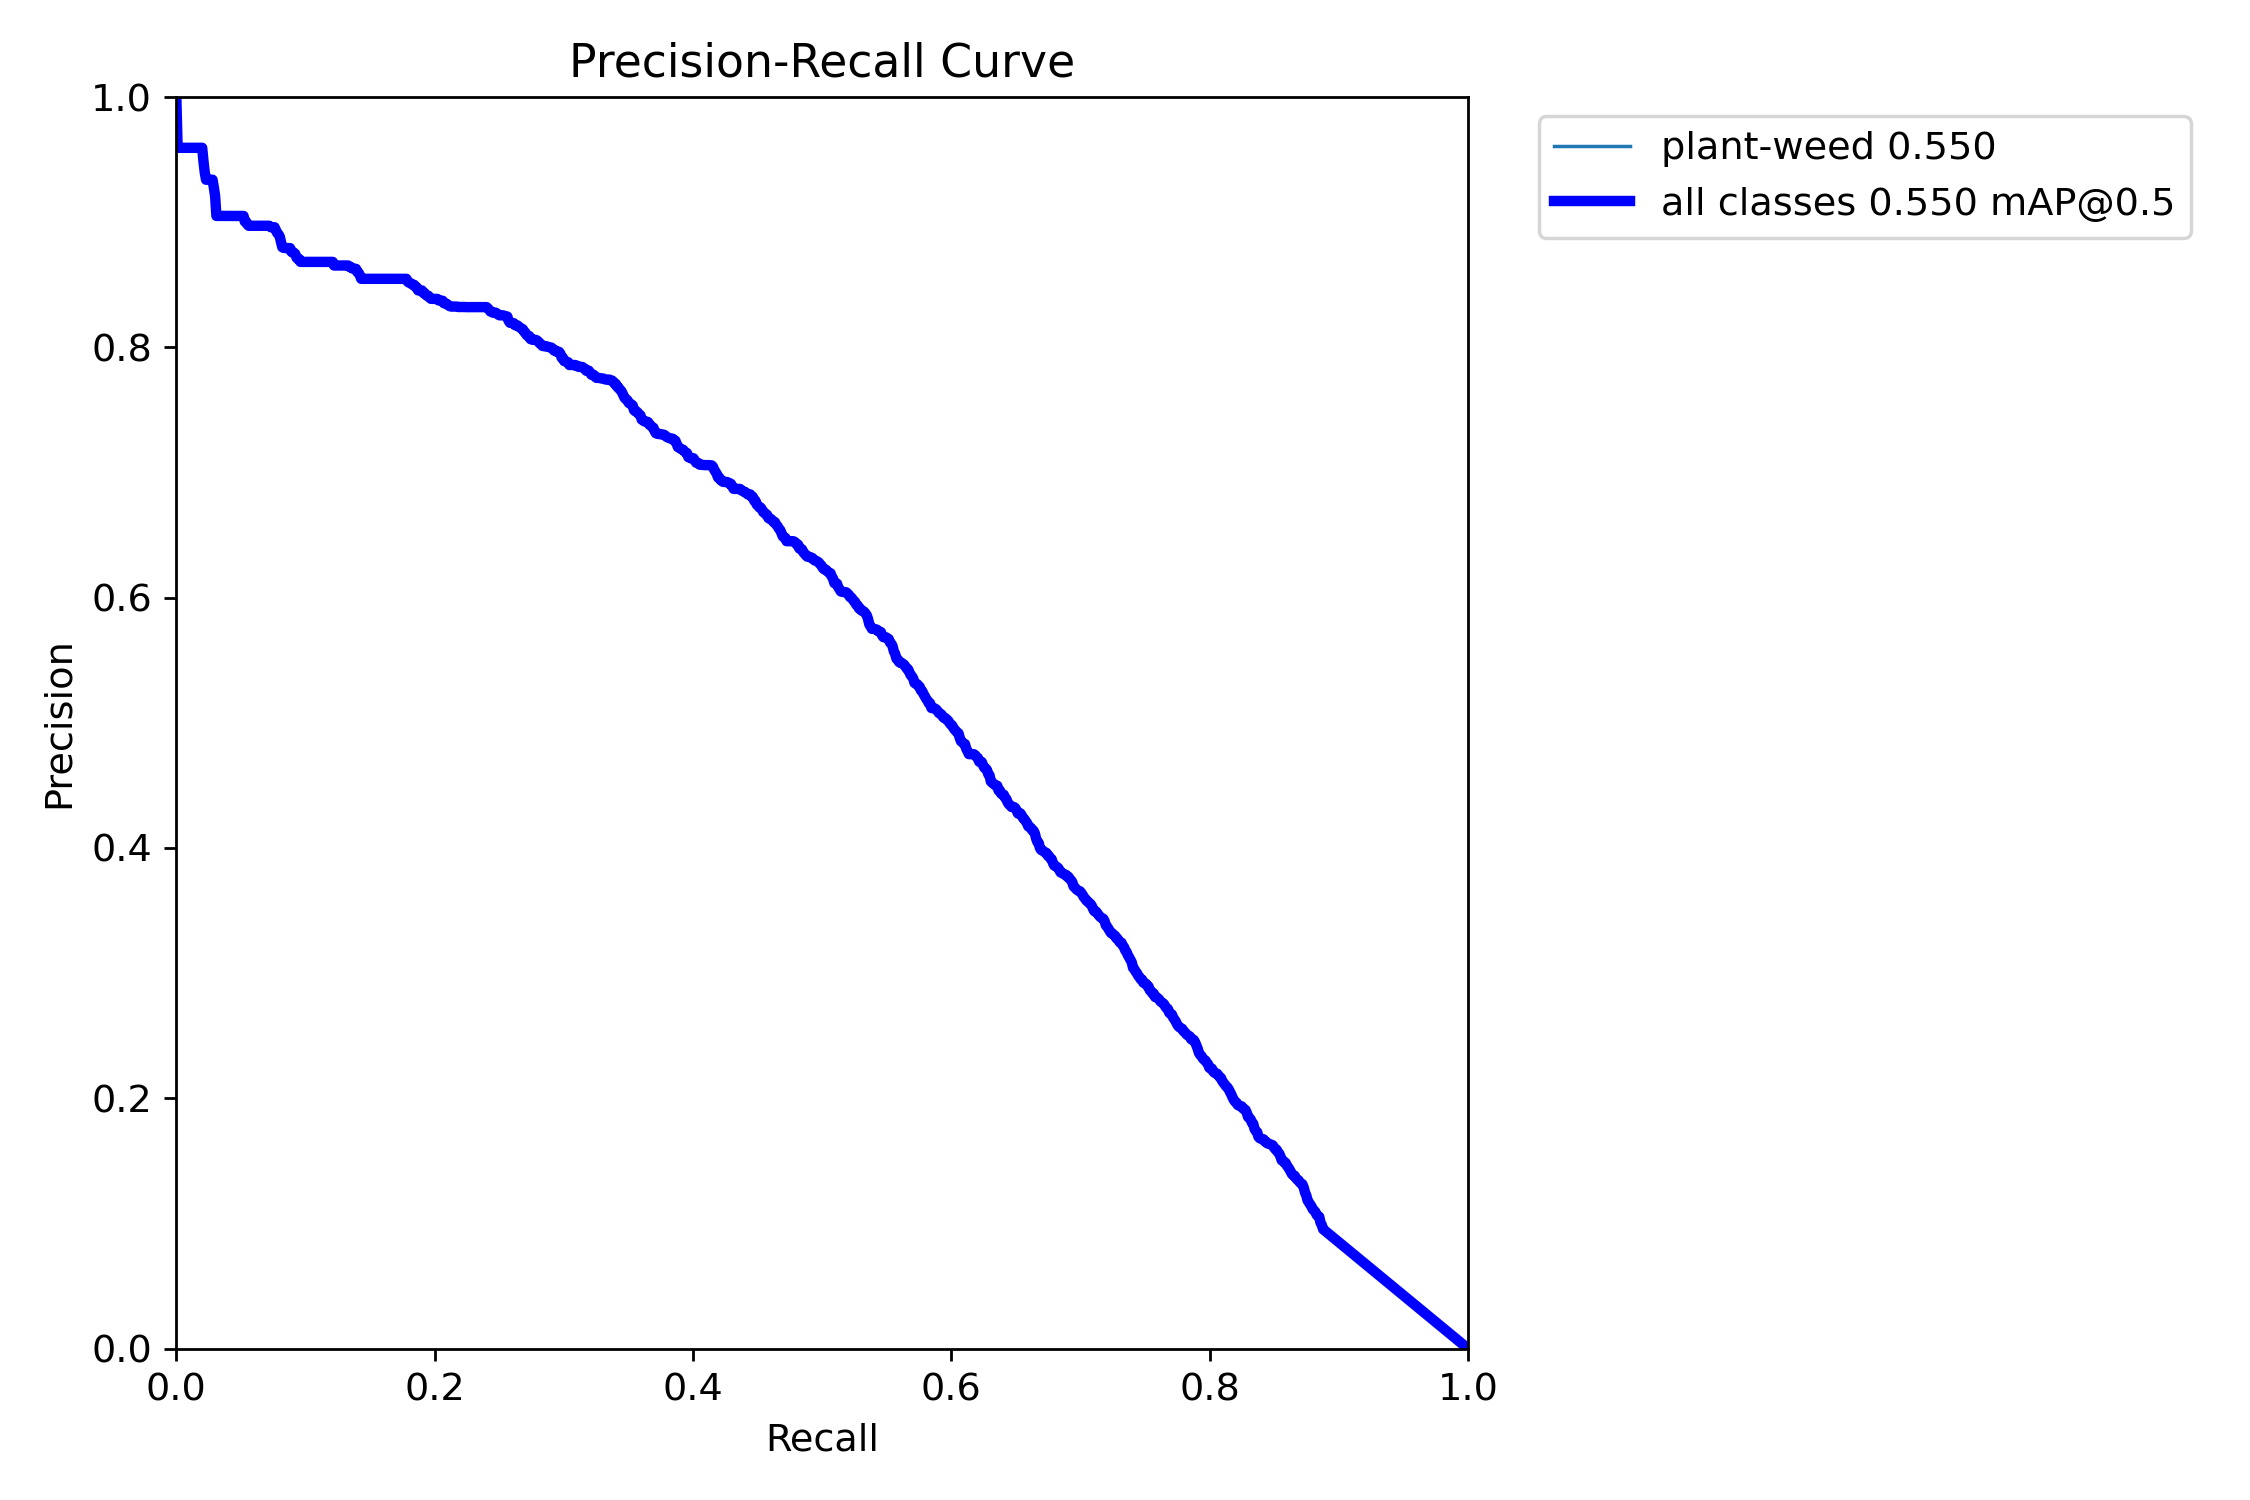

In [48]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

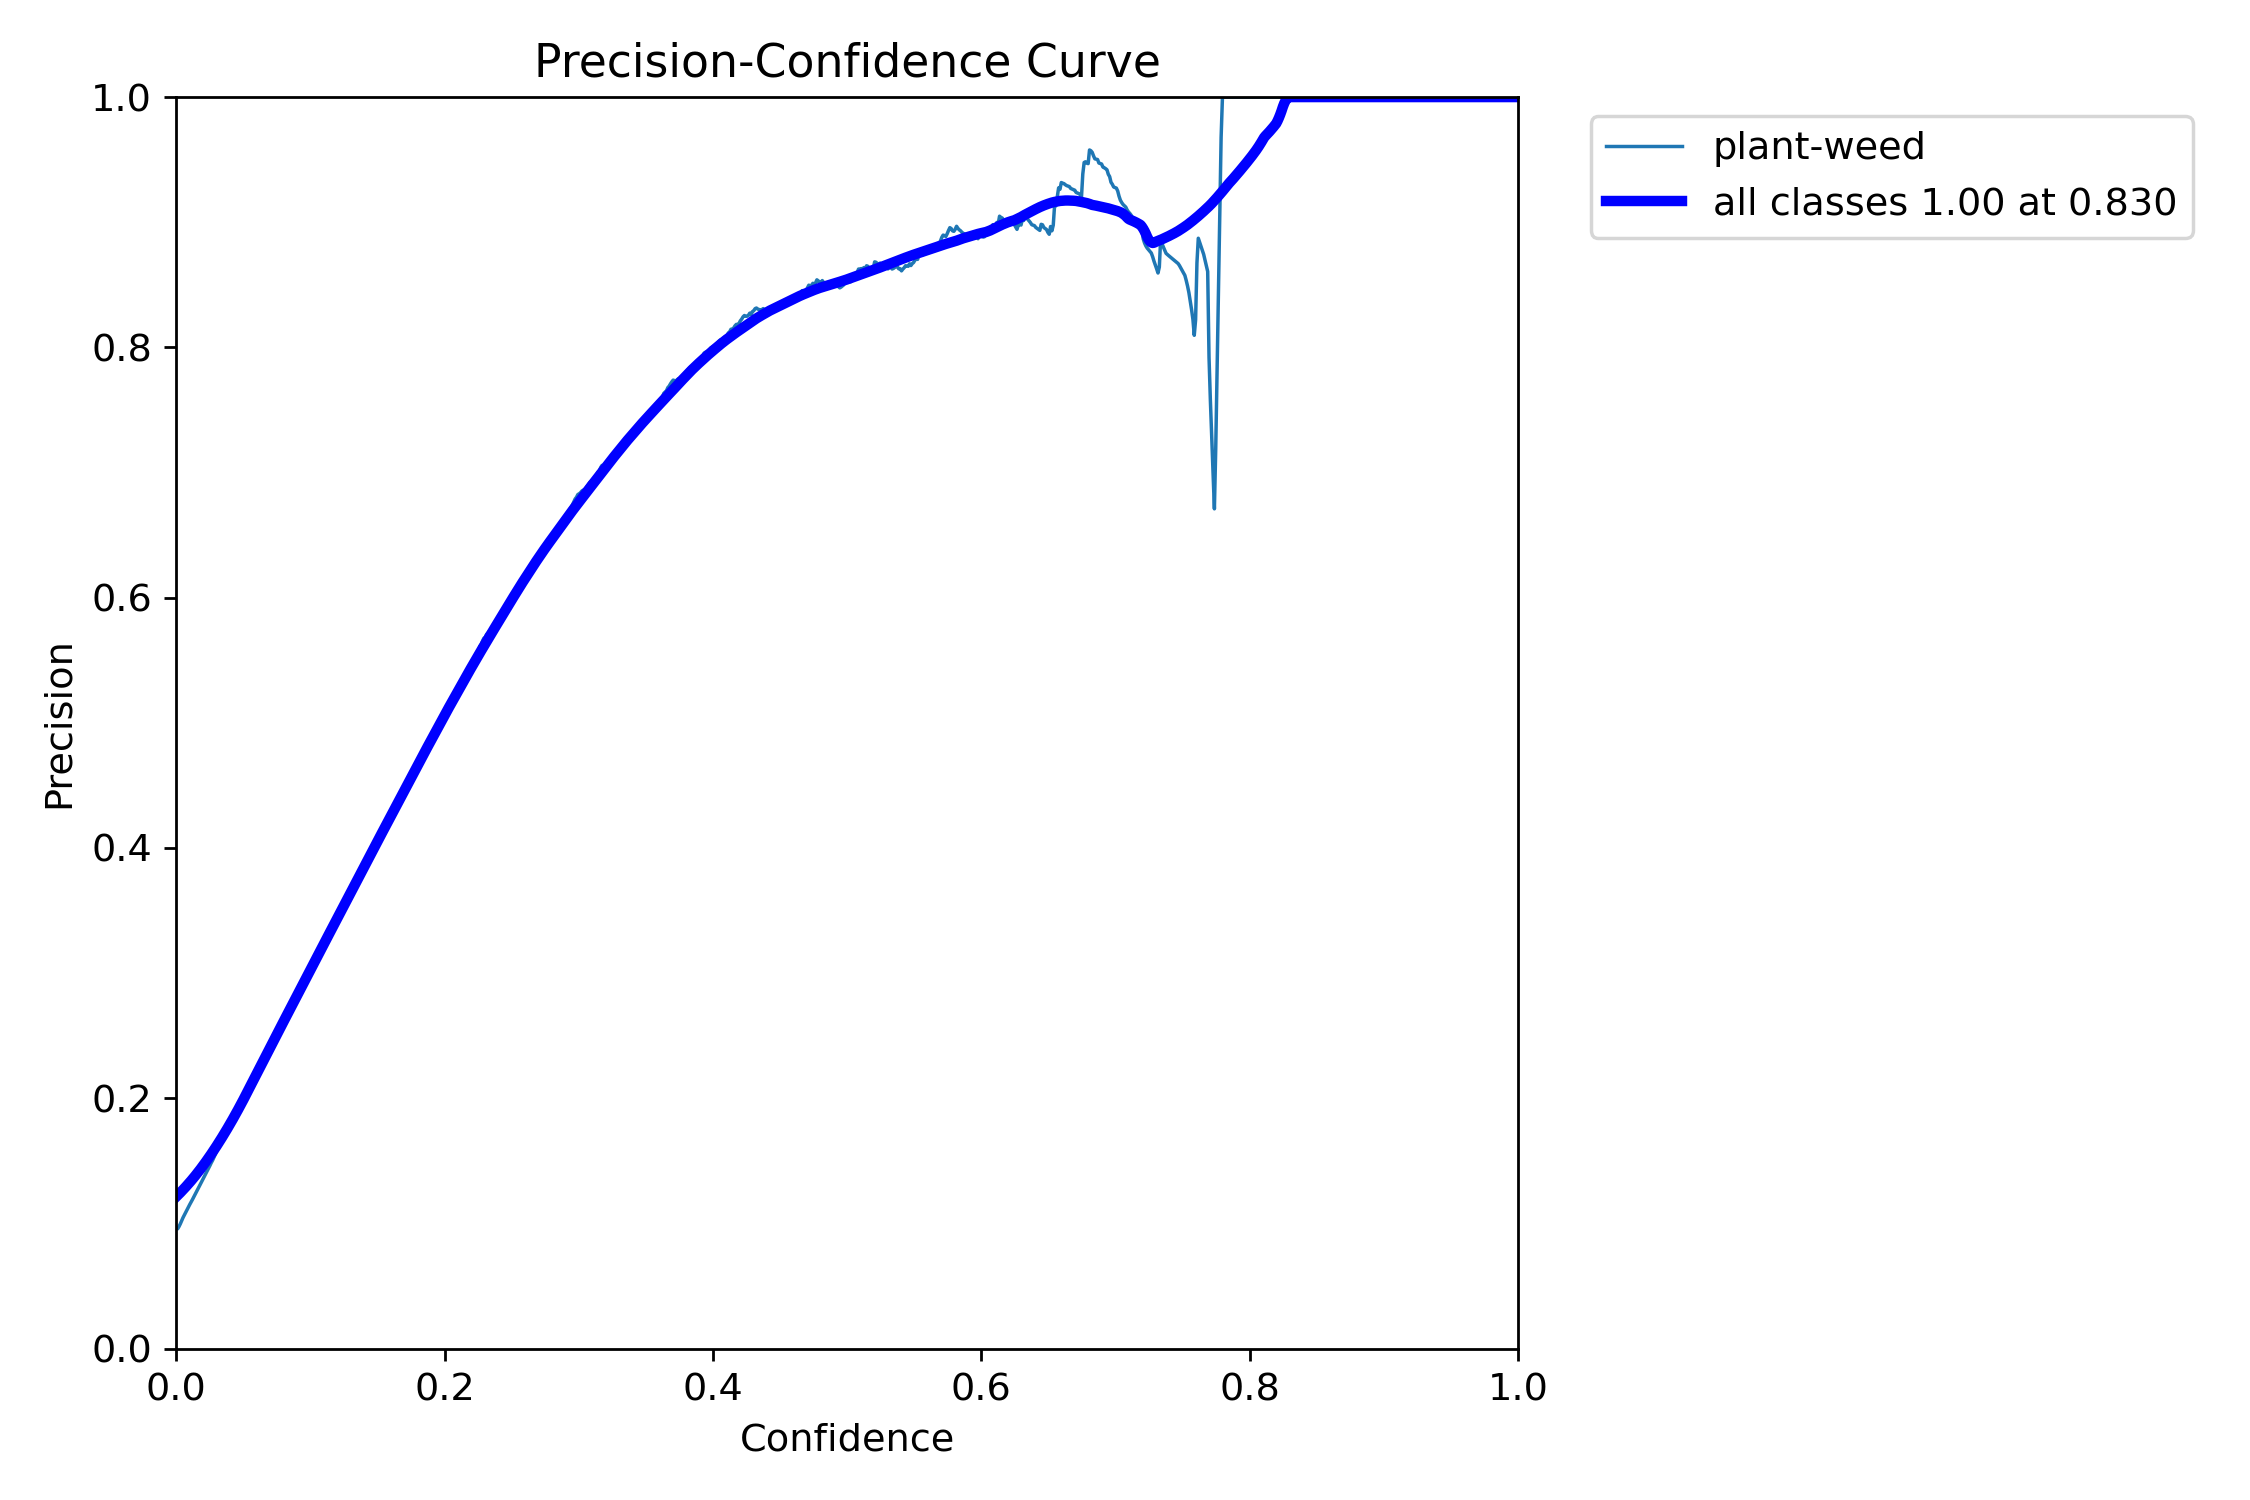

In [49]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

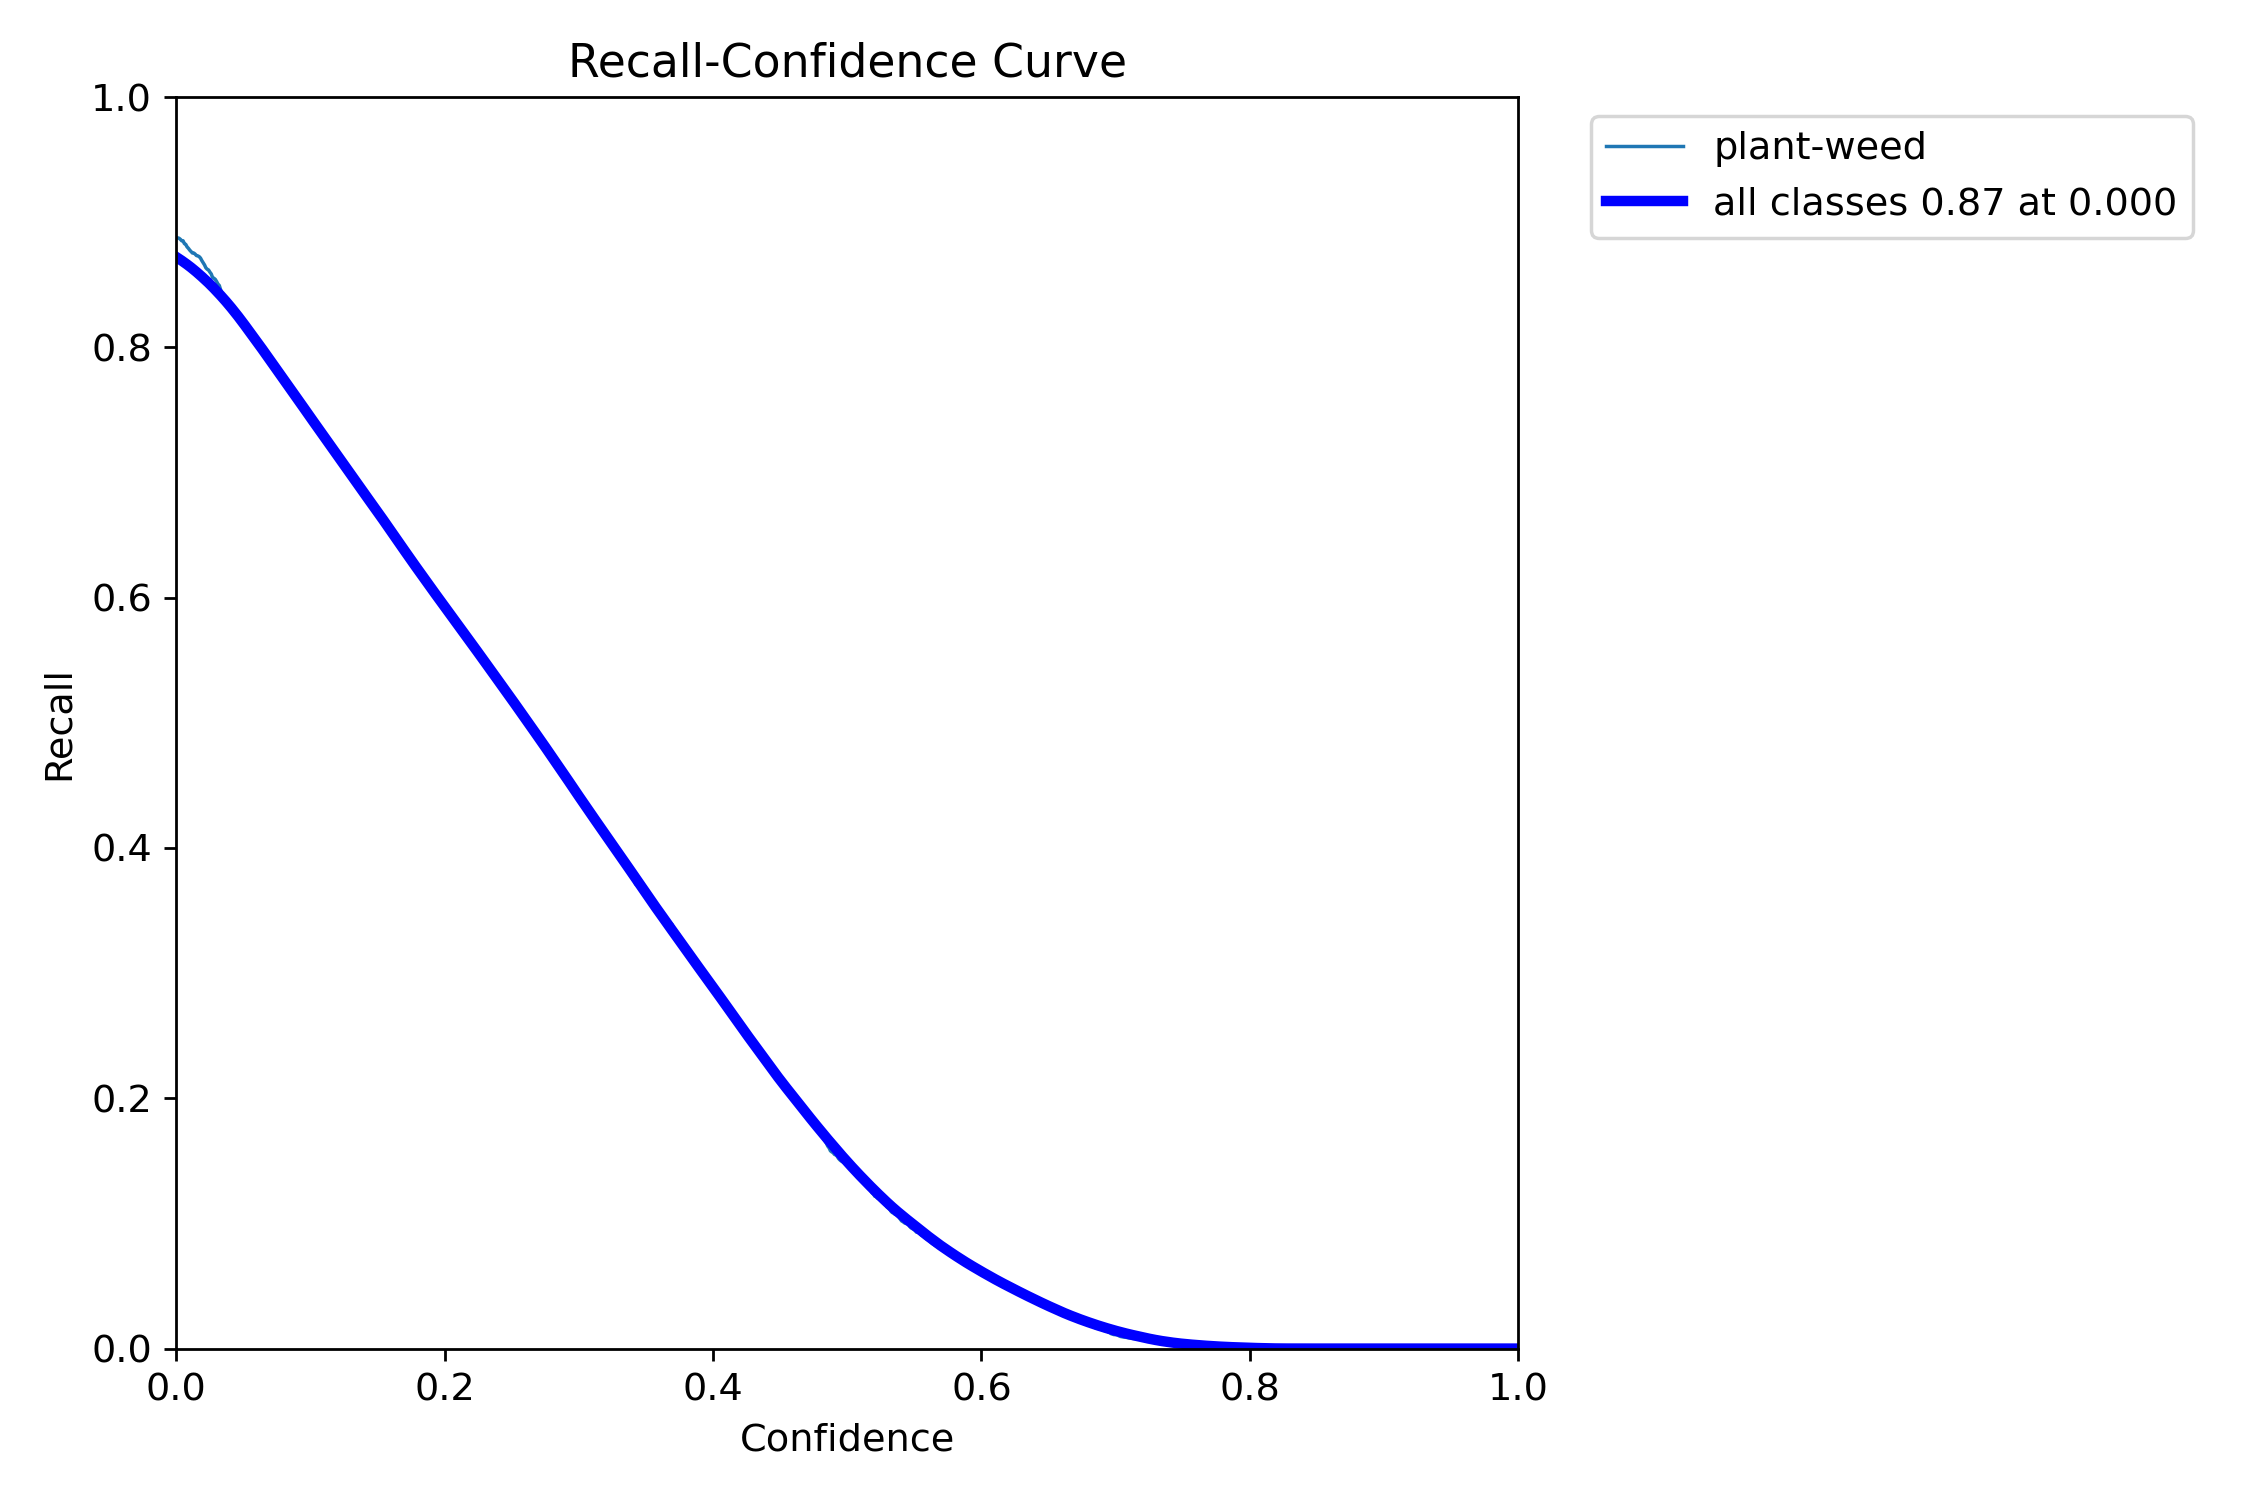

In [50]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

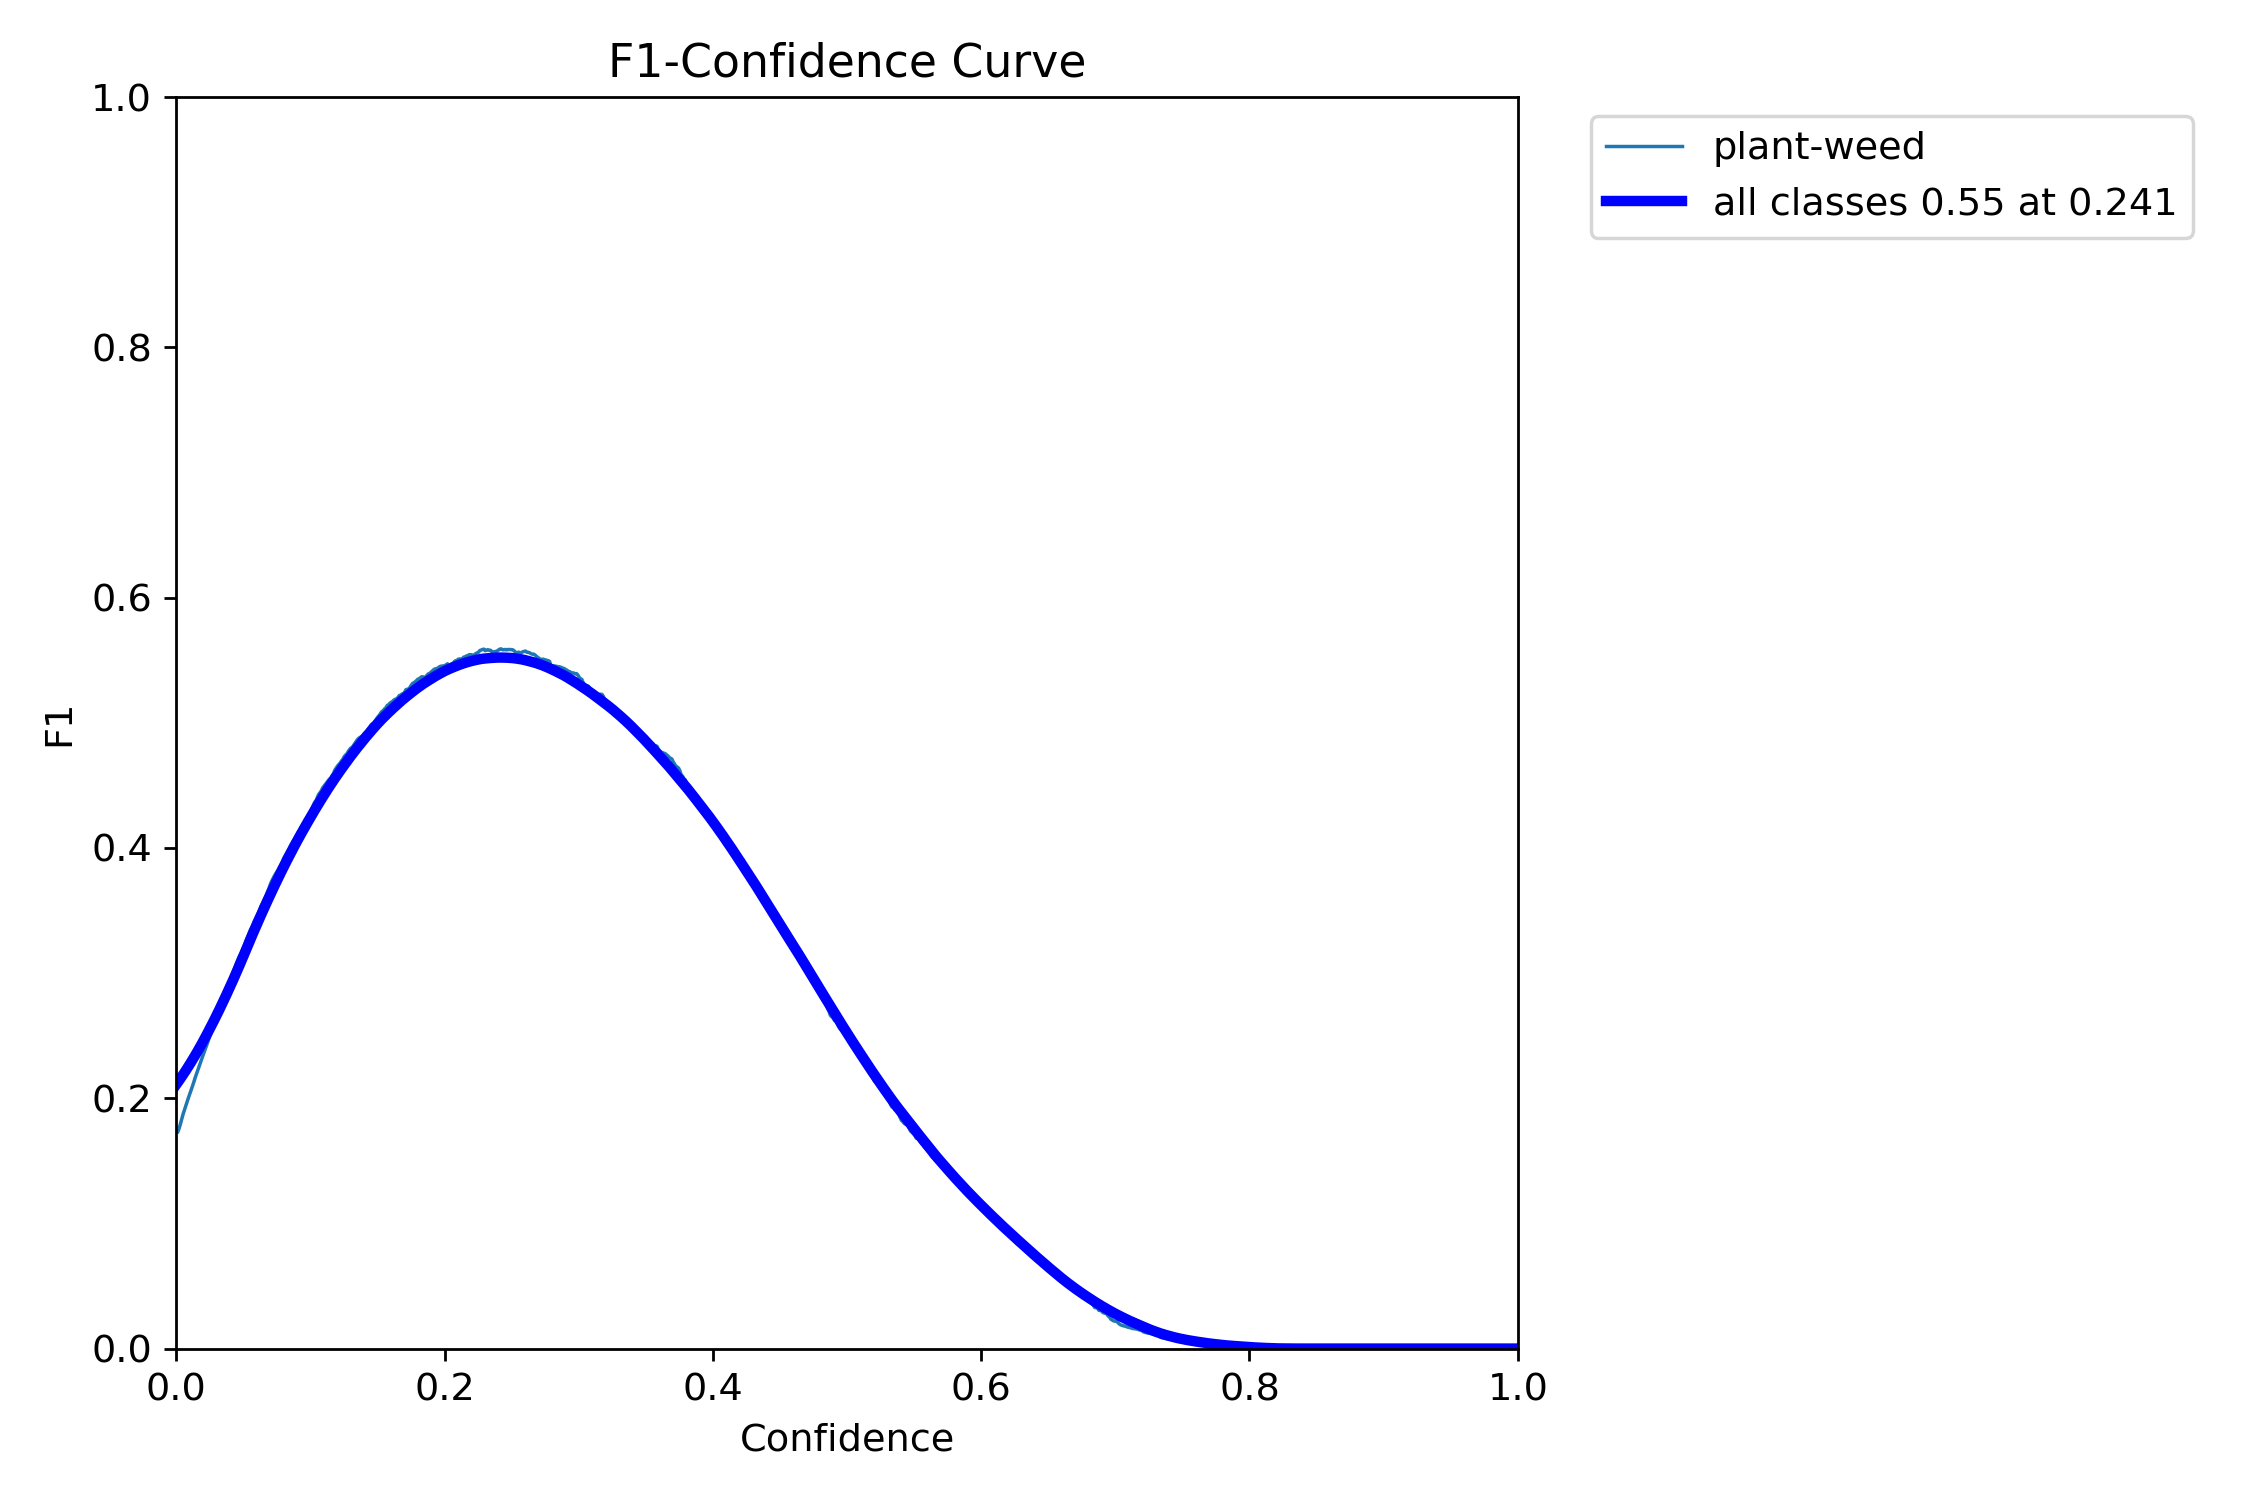

In [51]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

## Validation

In [52]:
folder = "val2/"

#### Classification metrics

In [80]:
# Setting values from CM graph
TP = 2057
FP = 951
FN = 1410

In [81]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 4418

Confusion matrix:
[ 46.56% , 21.53% ]
[ 31.91% , 0.00% ]

Metrics:
- Accuracy: 0.466
- Precision: 0.684
- Recall: 0.593
- F1 Score: 0.635
- F½ Score: 0.664
- G-mean: 0.637


### Graphs

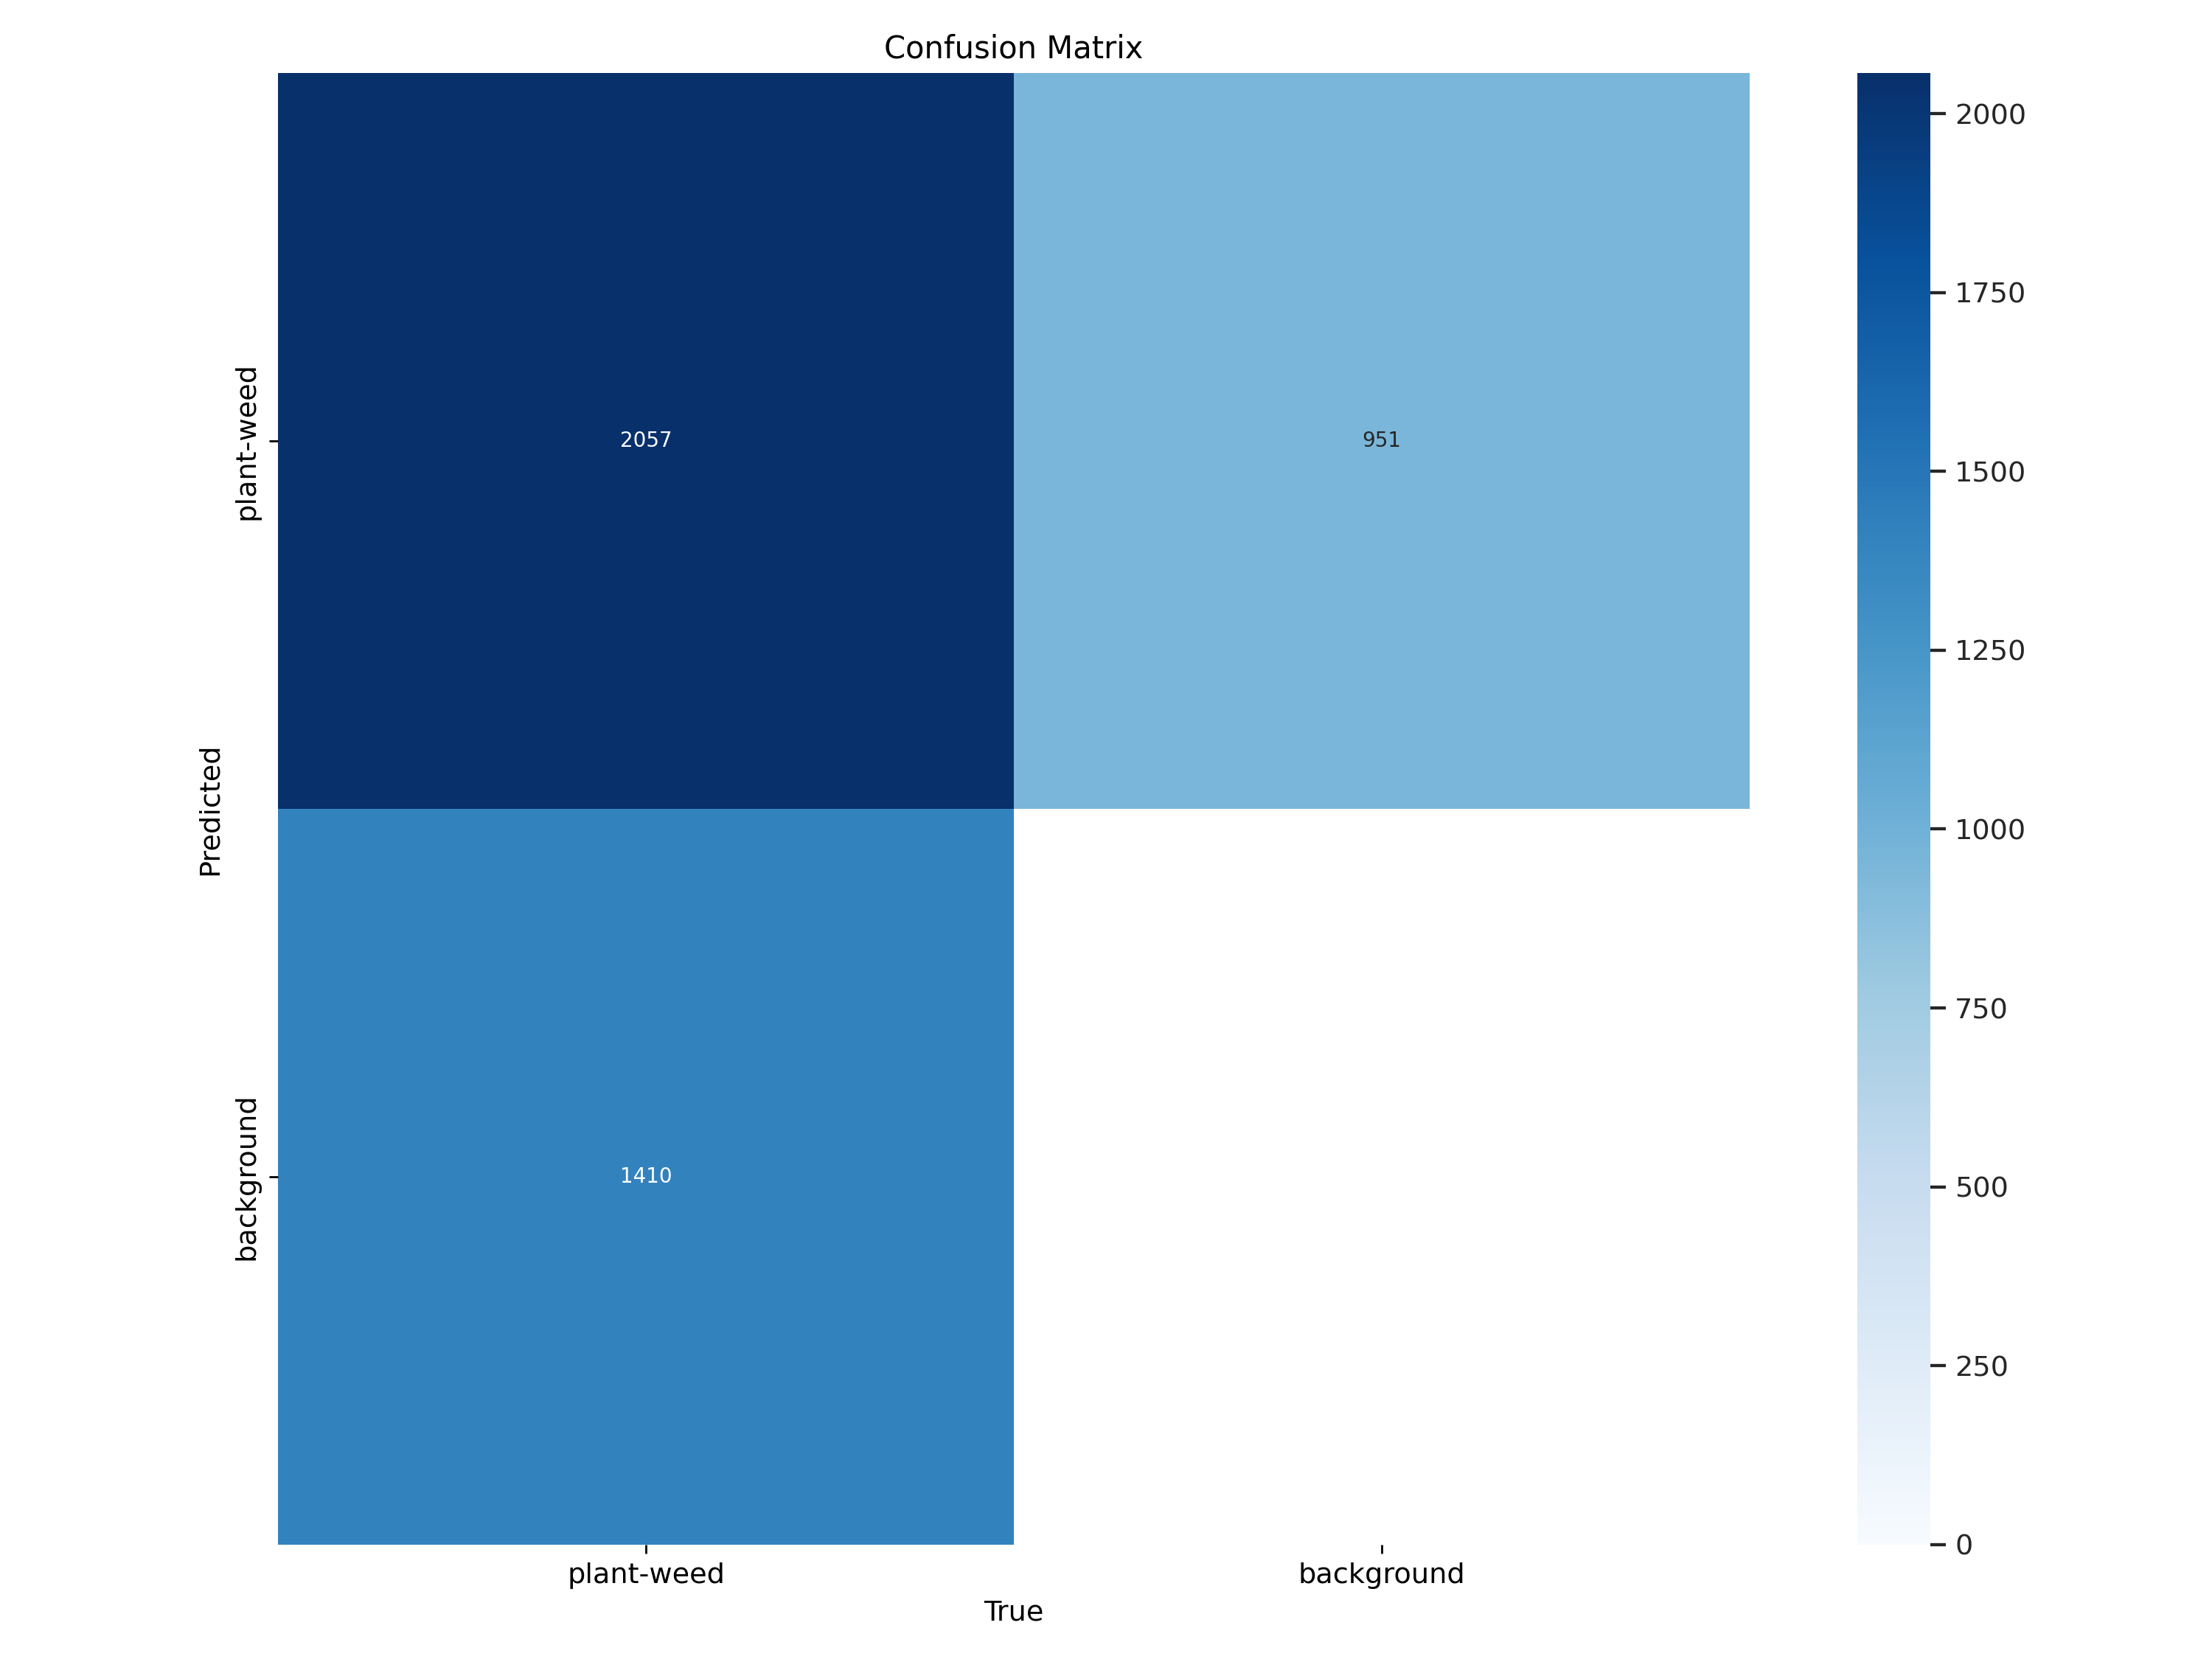

In [55]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

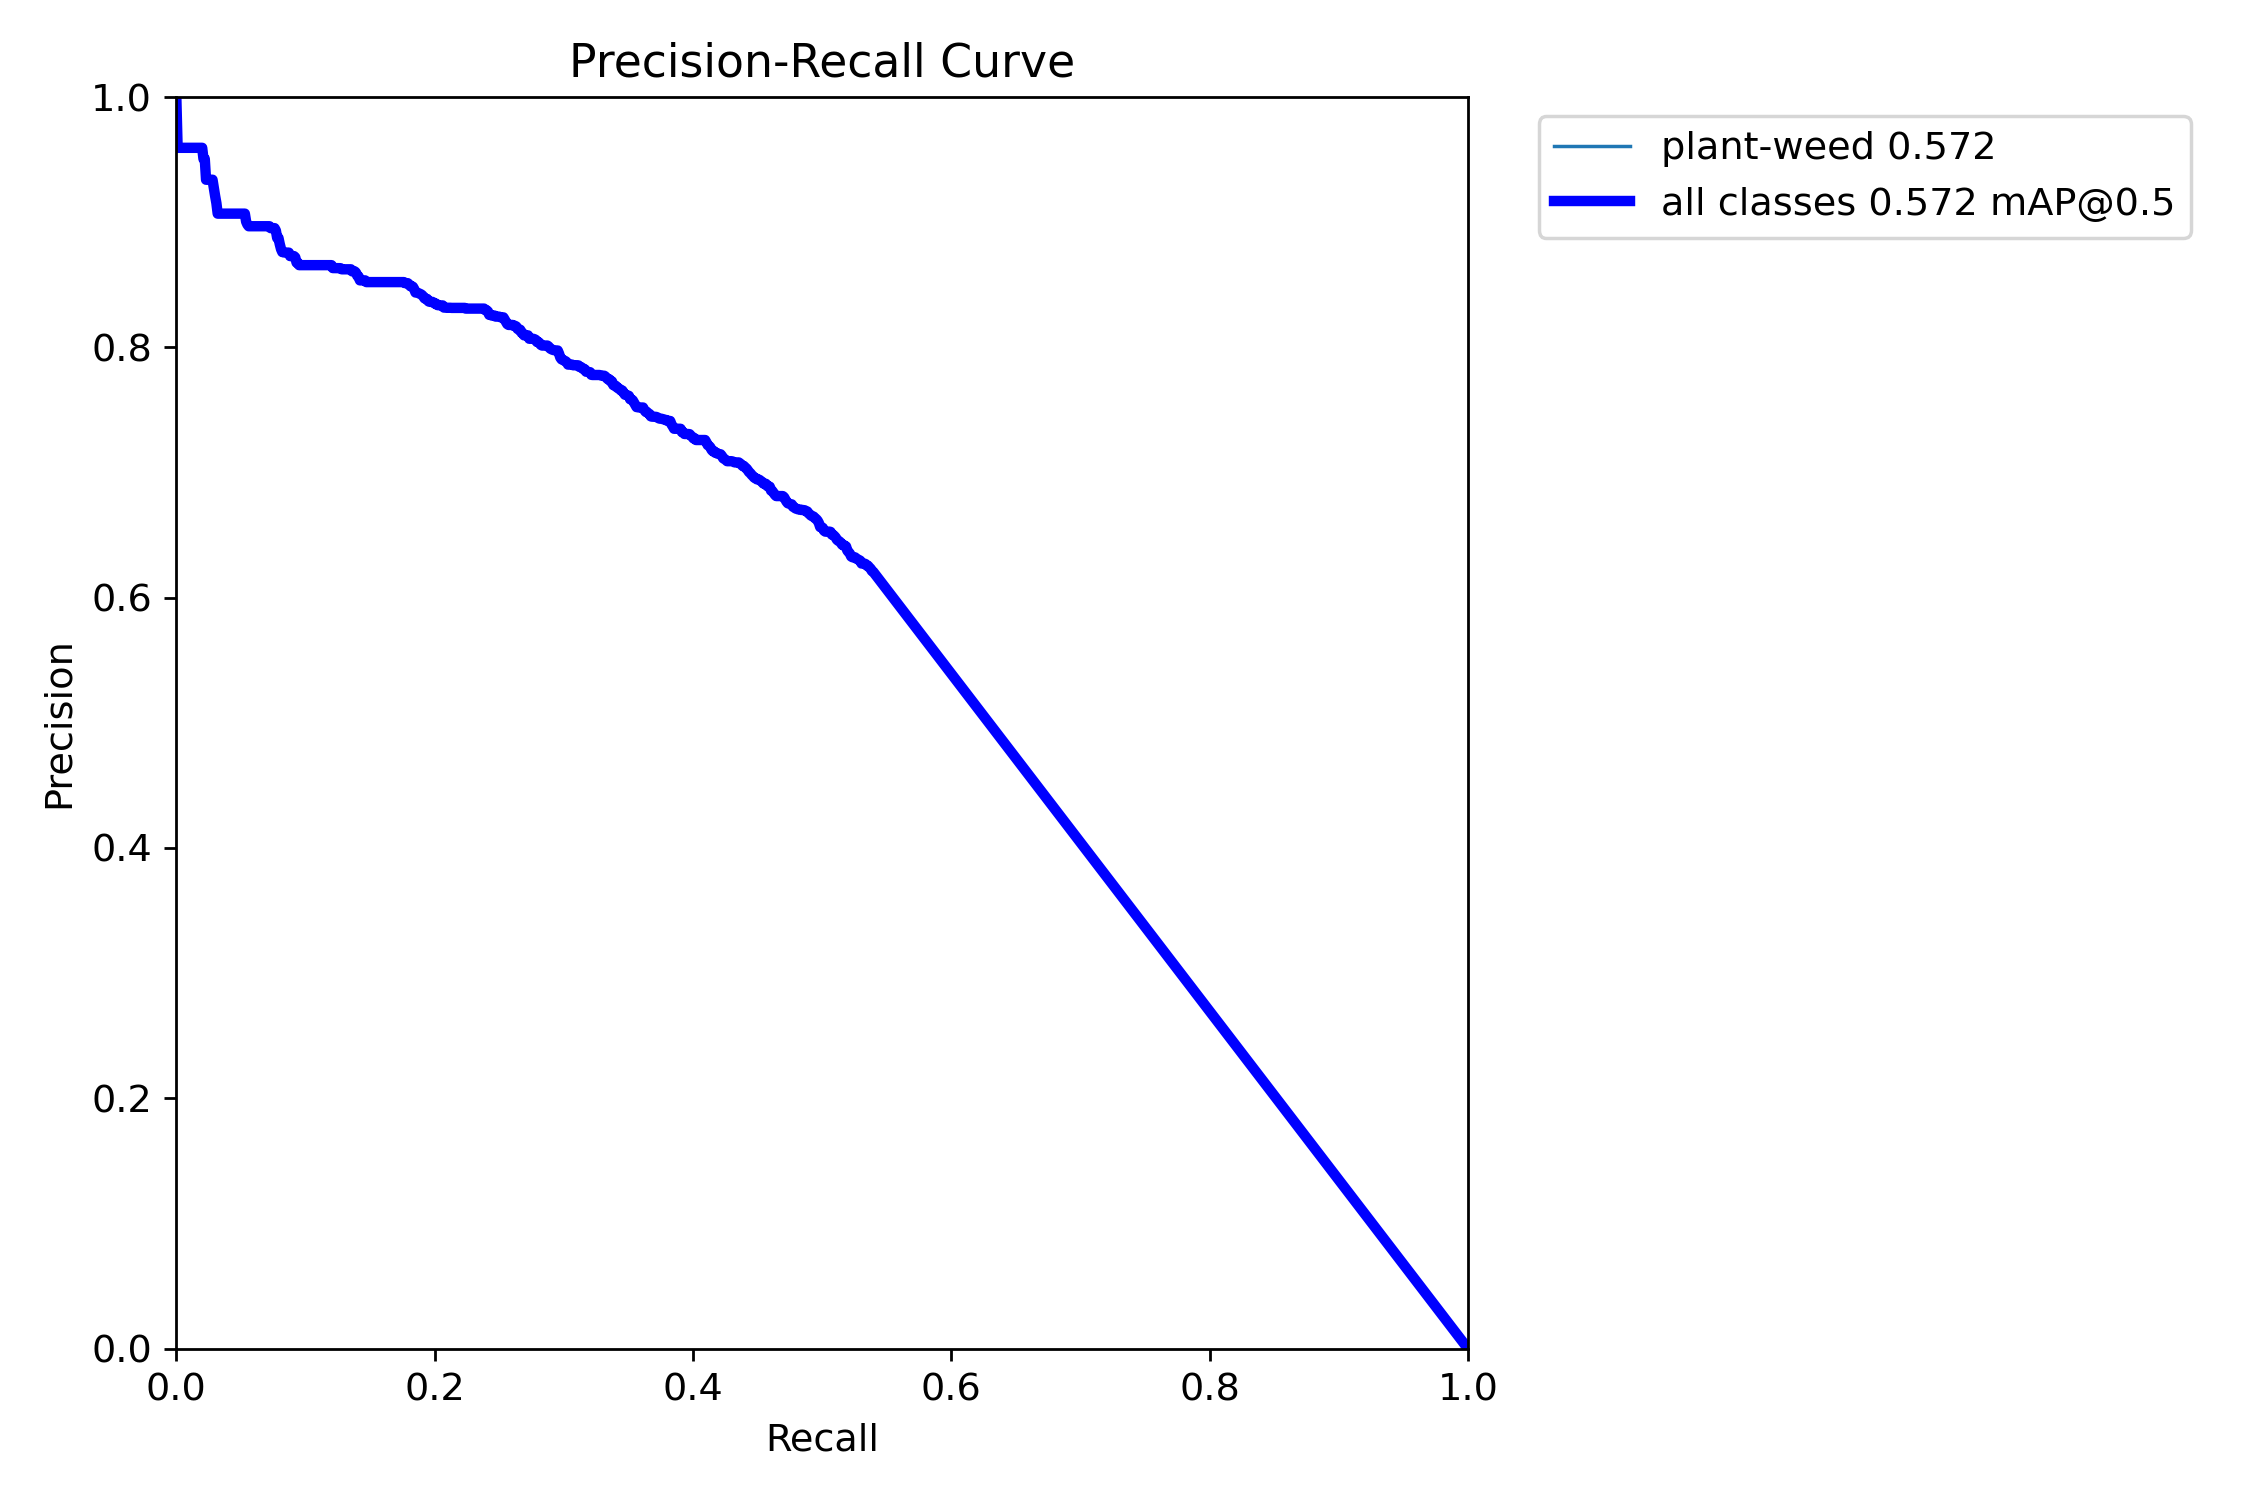

In [56]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

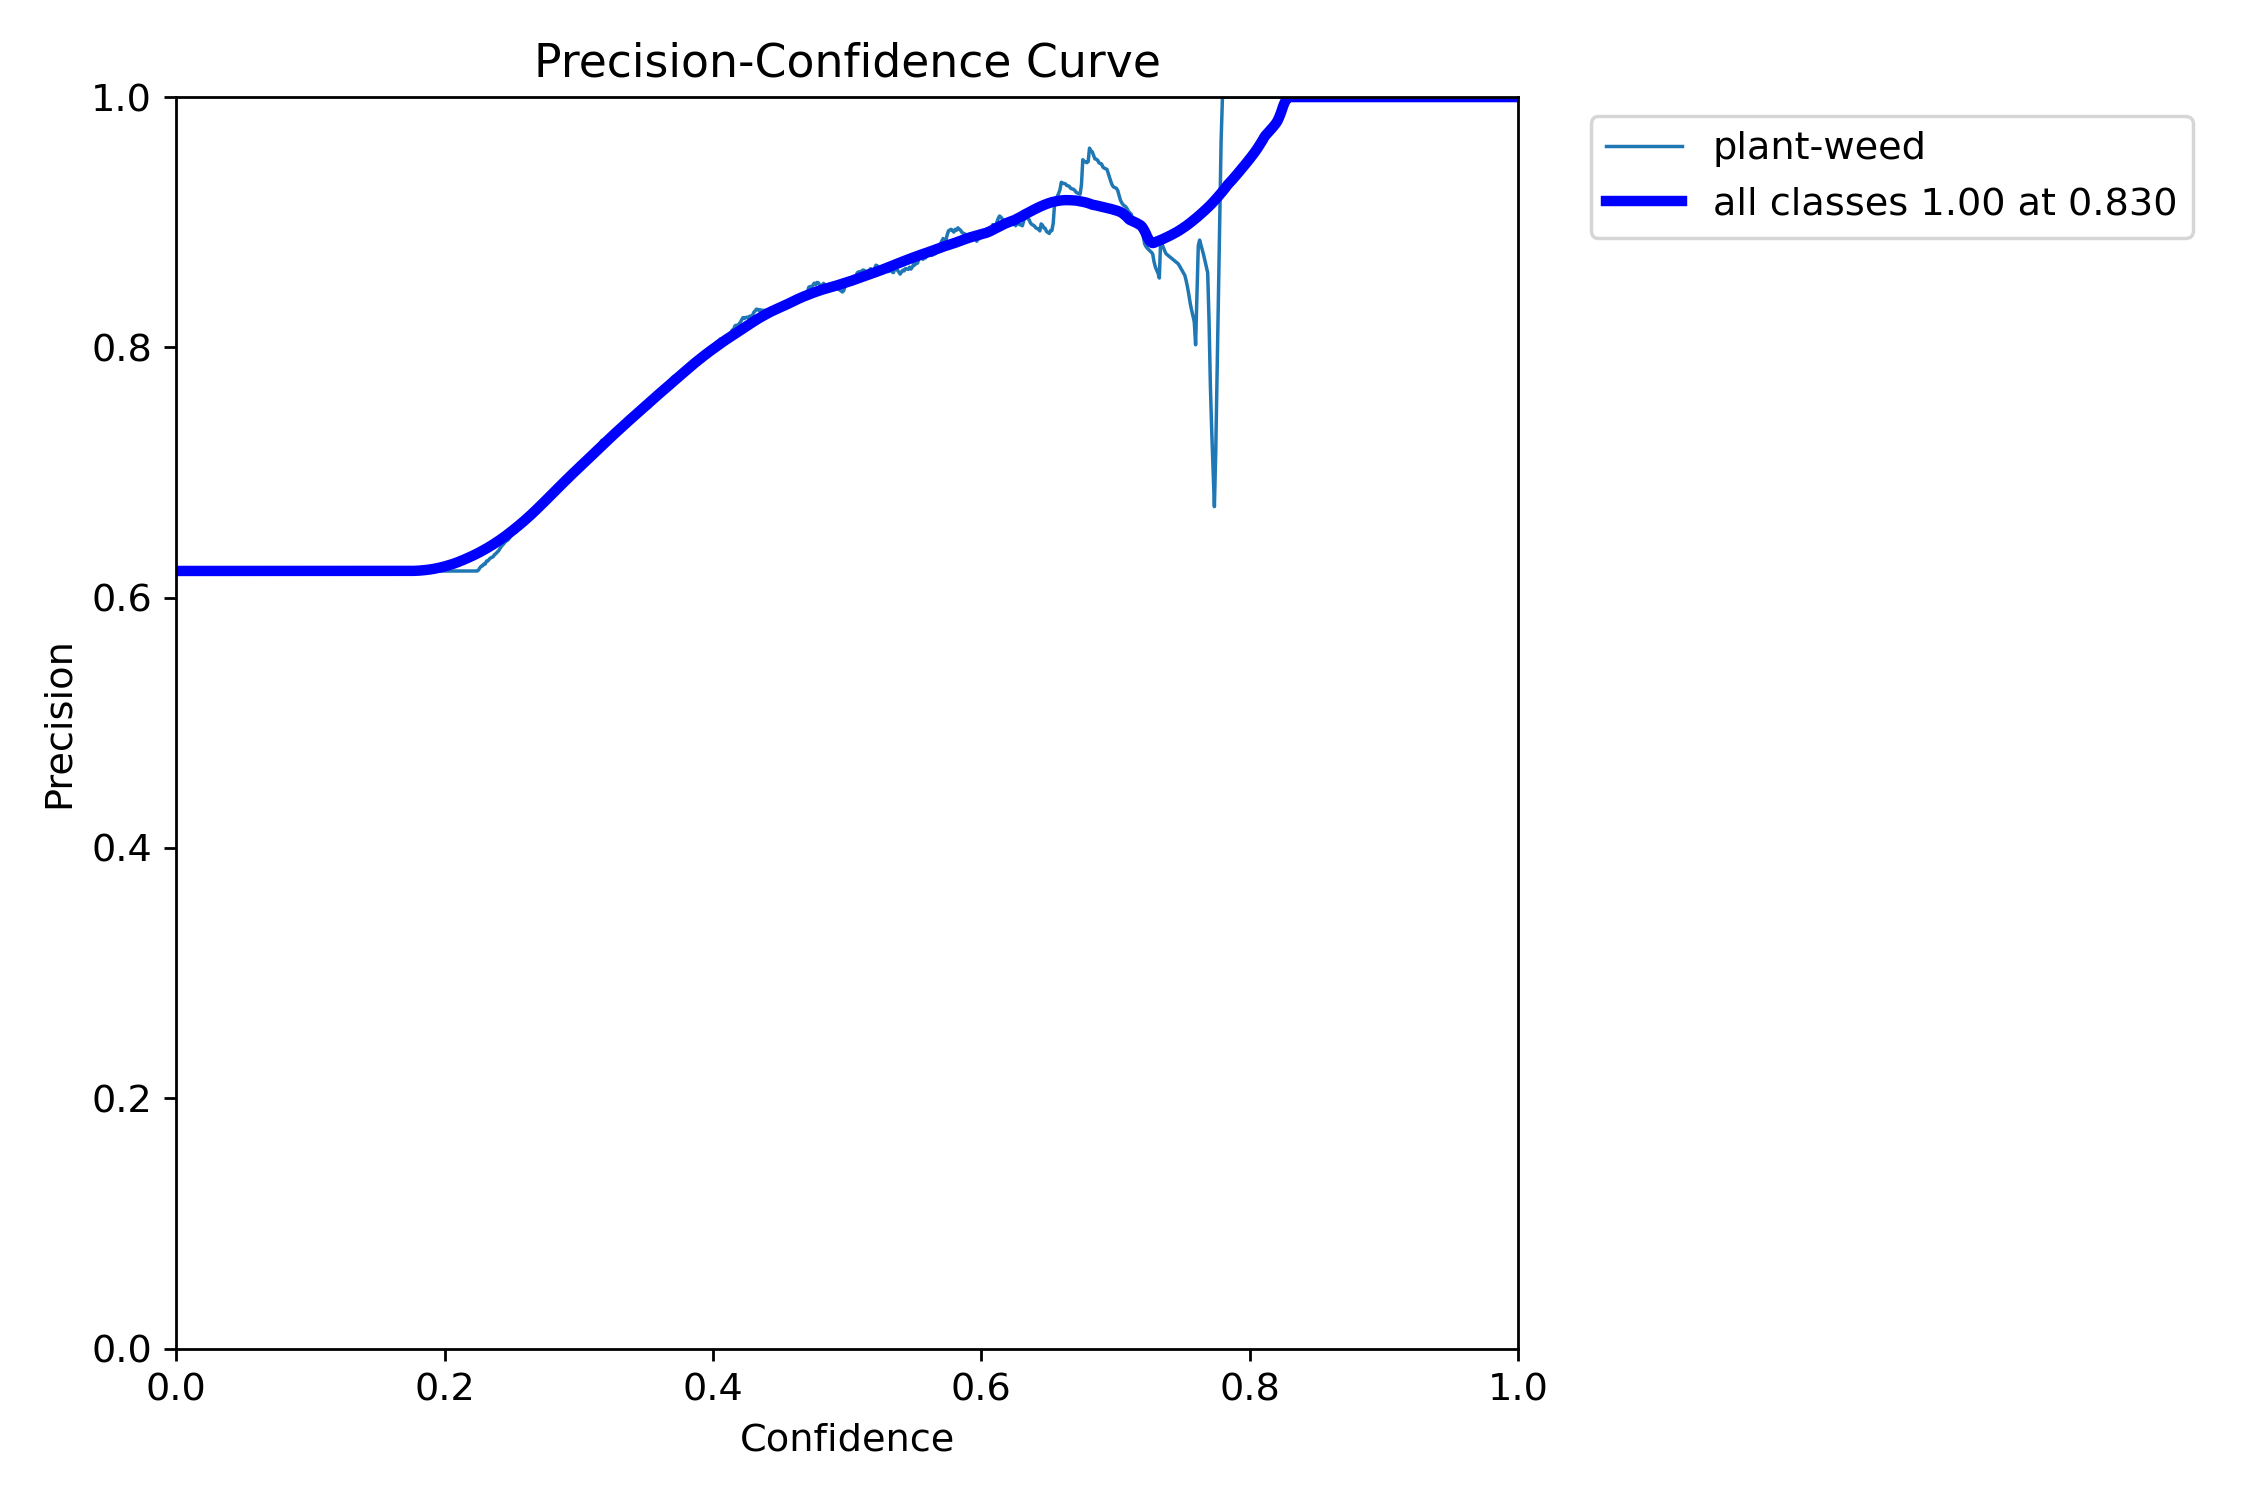

In [57]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

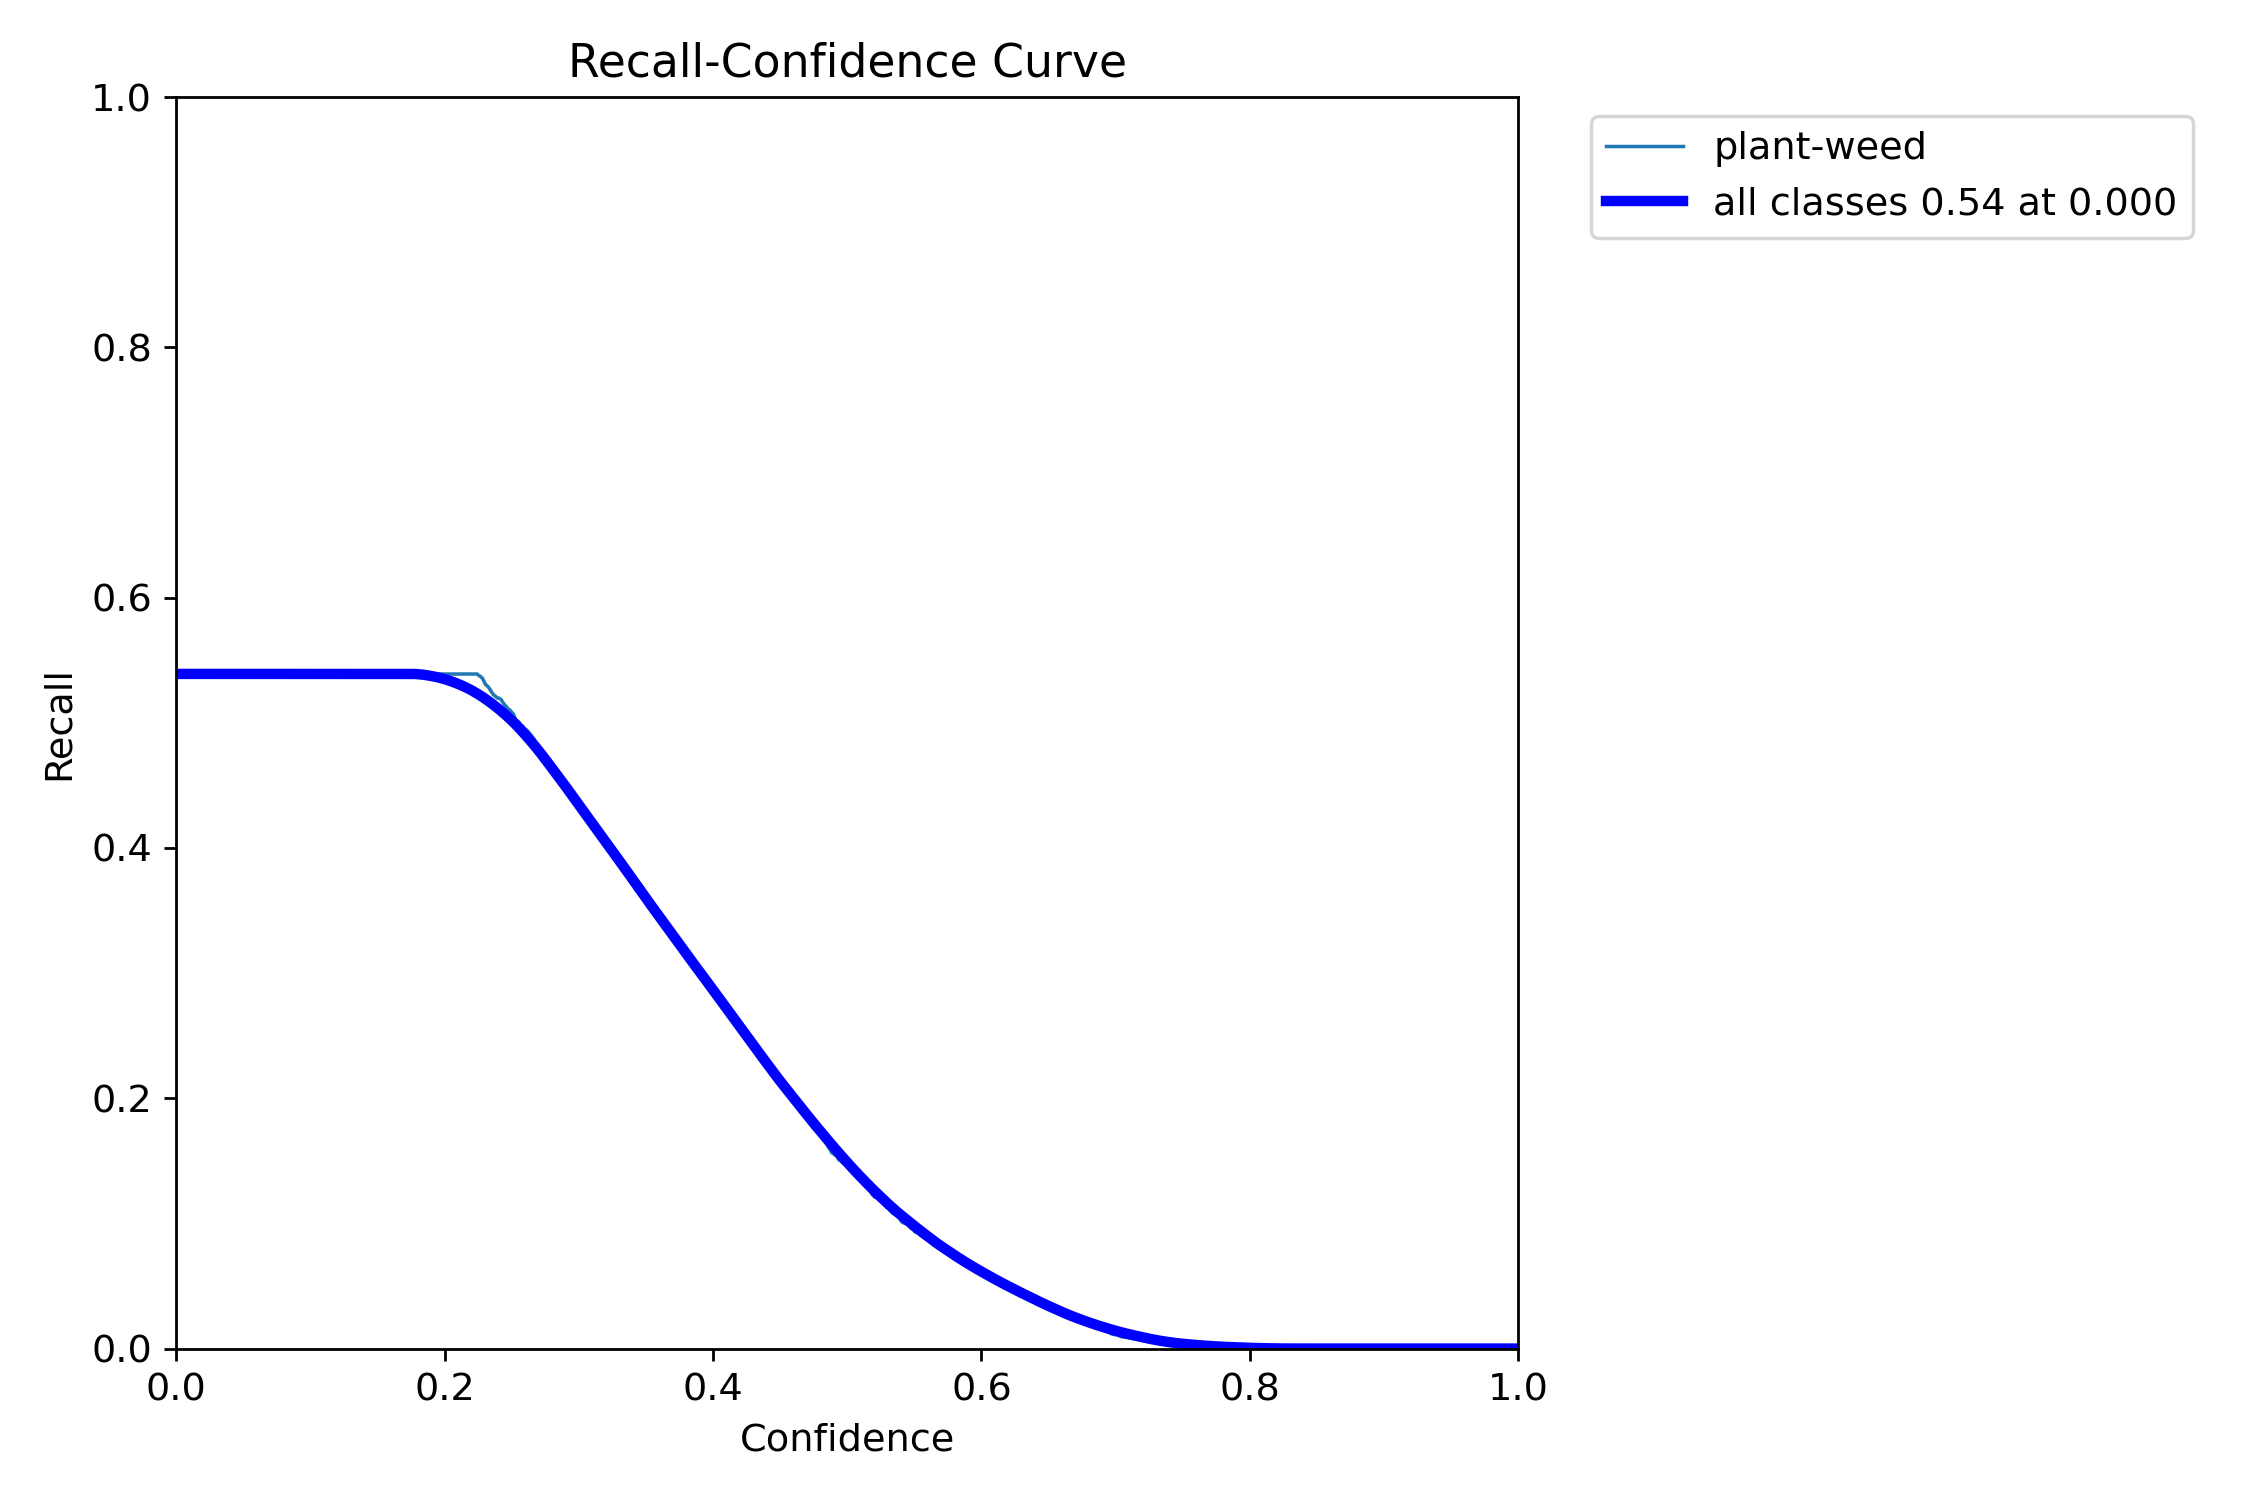

In [58]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

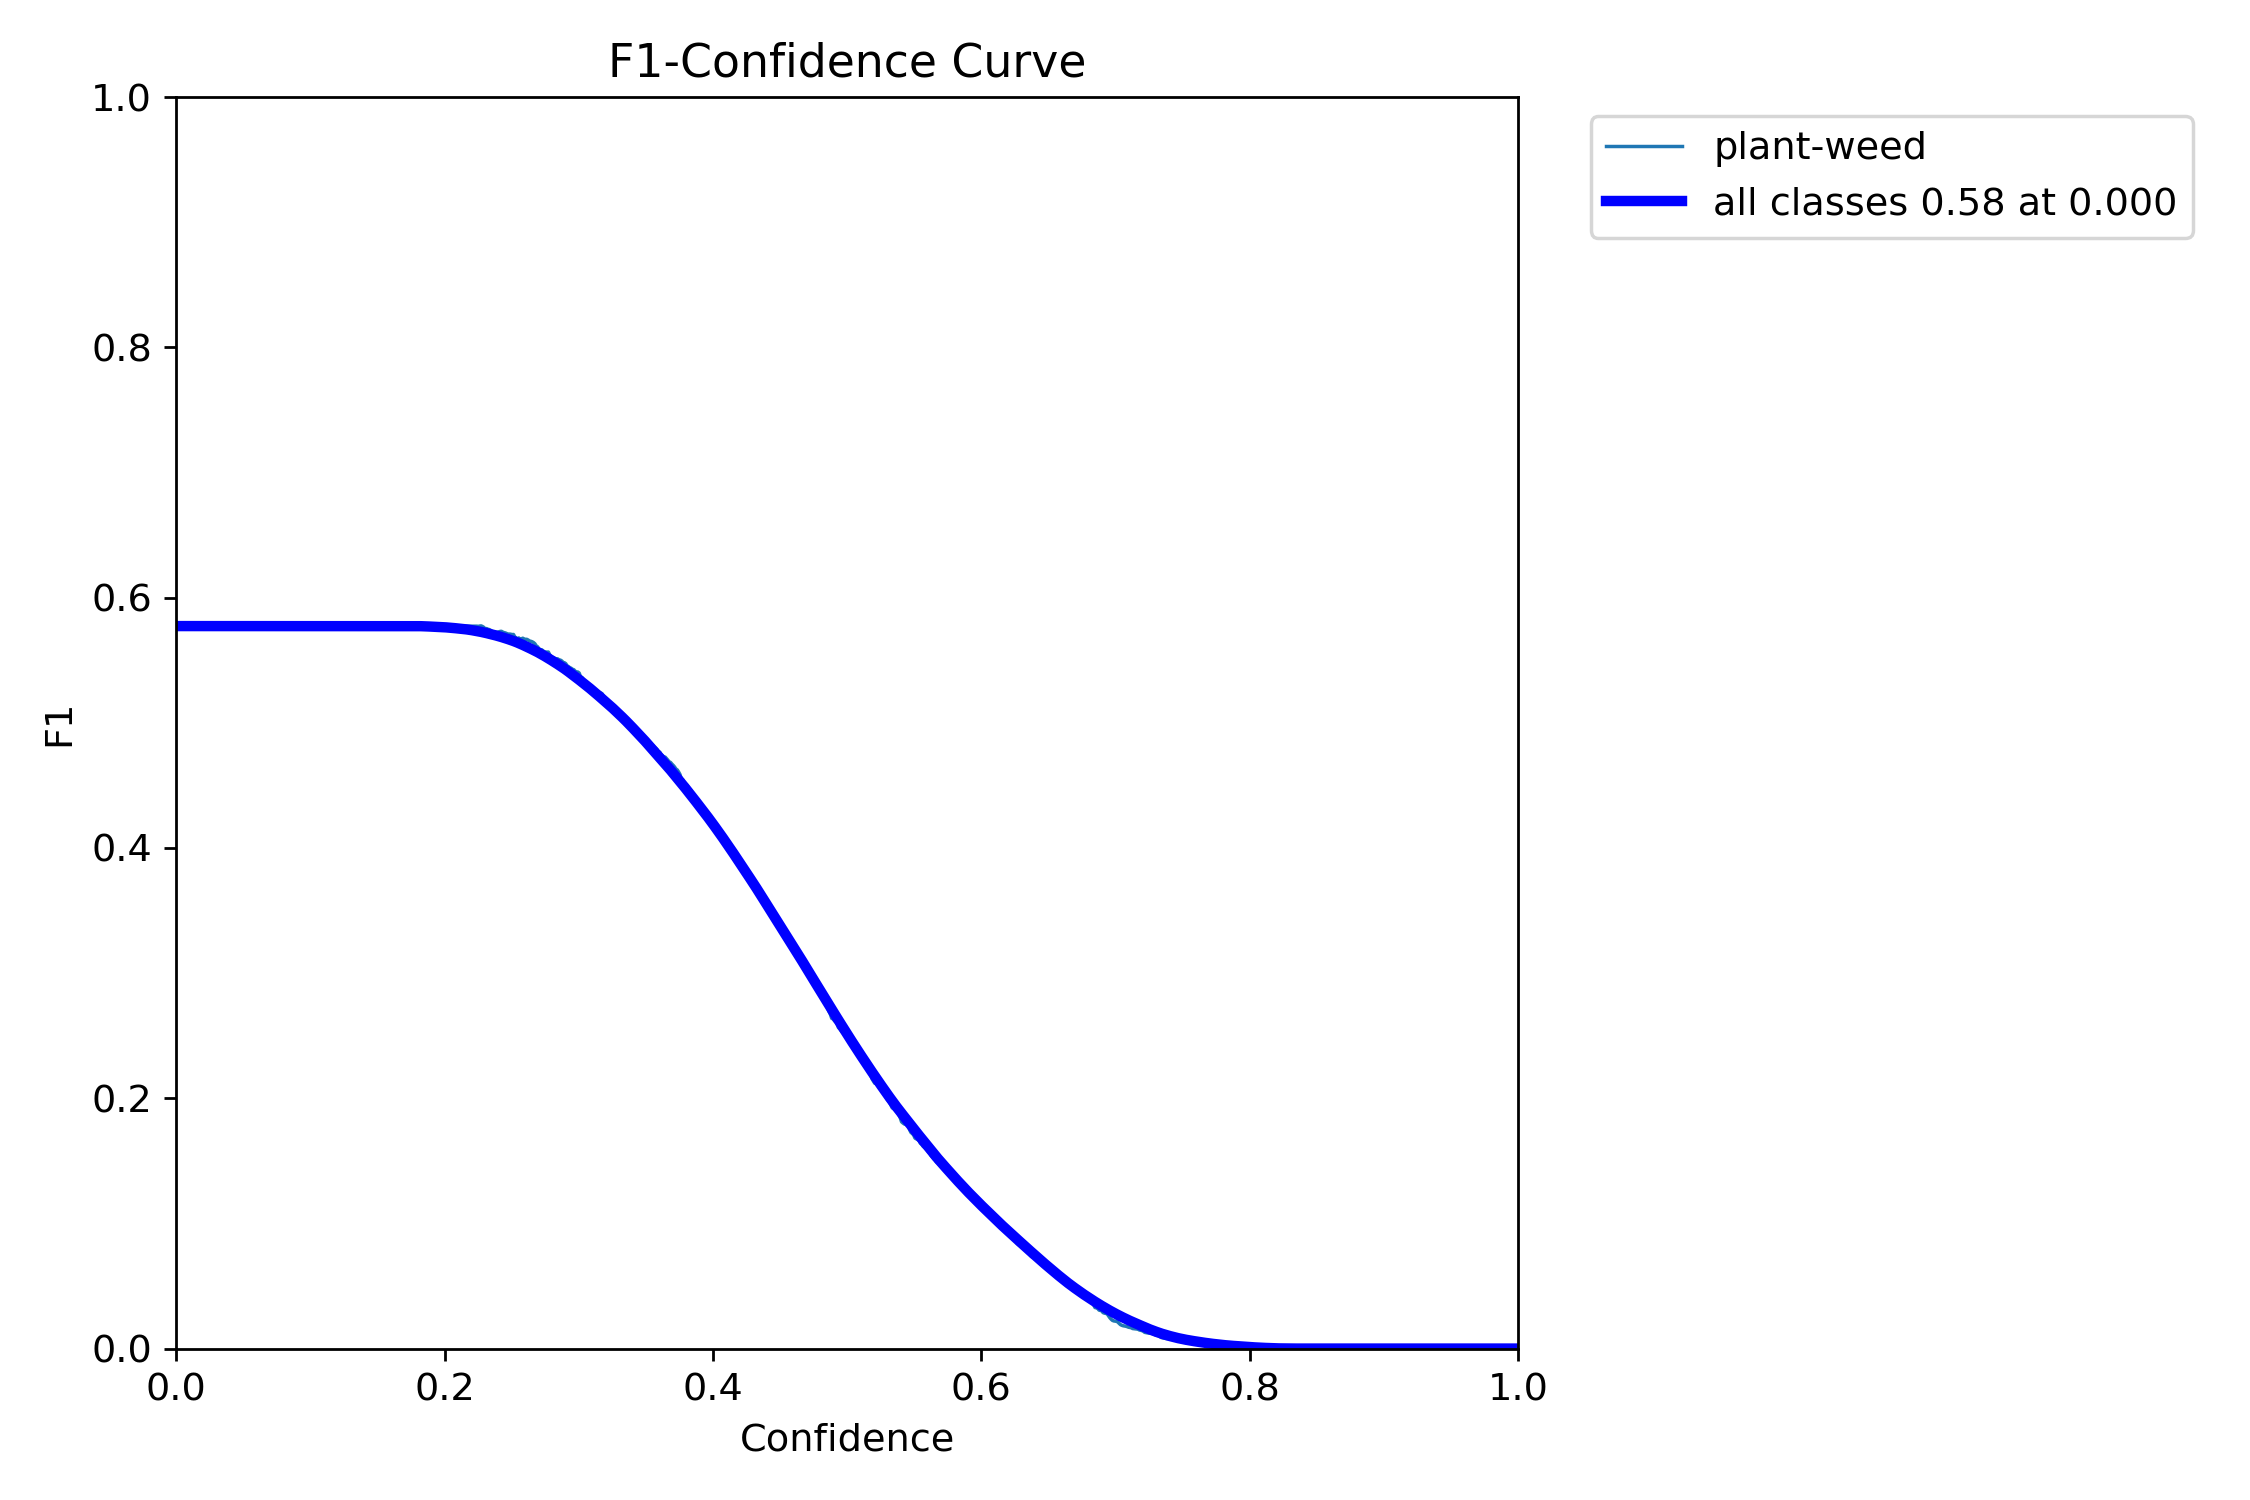

In [59]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# References

## Experiment 26
### *Full Fine-Tuning | ~1000 epochs*
Every layer was initialized with pre-trained YOLOv8 weights and then re-trained for ~1000 epochs

In [60]:
target_folder = f"docs/Experimentos/3 Hyperparams/3 set/runs/detect/"
change_directory(target_folder)

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/docs/Experimentos/3 Hyperparams/3 set/runs/detect
Project root updated to: ../../../../../../


In [61]:
folder = "train2/"

In [62]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
168,169,12195.9,1.02856,0.57053,1.02018,0,0,0,0,0,0,0,0.000088,0.000088,0.000088
169,170,12262.4,1.01047,0.55902,1.00149,0,0,0,0,0,0,0,0.000077,0.000077,0.000077
170,171,12342.3,1.01218,0.56321,1.01484,0,0,0,0,0,0,0,0.000066,0.000066,0.000066
171,172,12417.4,0.95753,0.53429,0.98759,0,0,0,0,0,0,0,0.000054,0.000054,0.000054
172,173,12501.7,0.98593,0.55160,1.01167,0,0,0,0,0,0,0,0.000043,0.000043,0.000043


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [63]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 208.362 min


#### Best epoch

In [64]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
0,1,15.0336,3.22651,4.6857,2.3448,0,0,0,0,0,0,0,0.00012,0.00012,0.00012,208.361667


In [65]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 1 con mAP50 de 0.000


In [66]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [67]:
# Setting values from CM graph
TP = 1453
FP = 1049
FN = 956

In [68]:
# Confusion matrix
show_metrics(TP, FP, FN)

Total objects detected: 3458

Confusion matrix:
[ 42.02% , 30.34% ]
[ 27.65% , 0.00% ]

Metrics:
- Accuracy: 0.420
- Precision: 0.581
- Recall: 0.603
- F1 Score: 0.592
- F½ Score: 0.585
- G-mean: 0.592


### Graphs

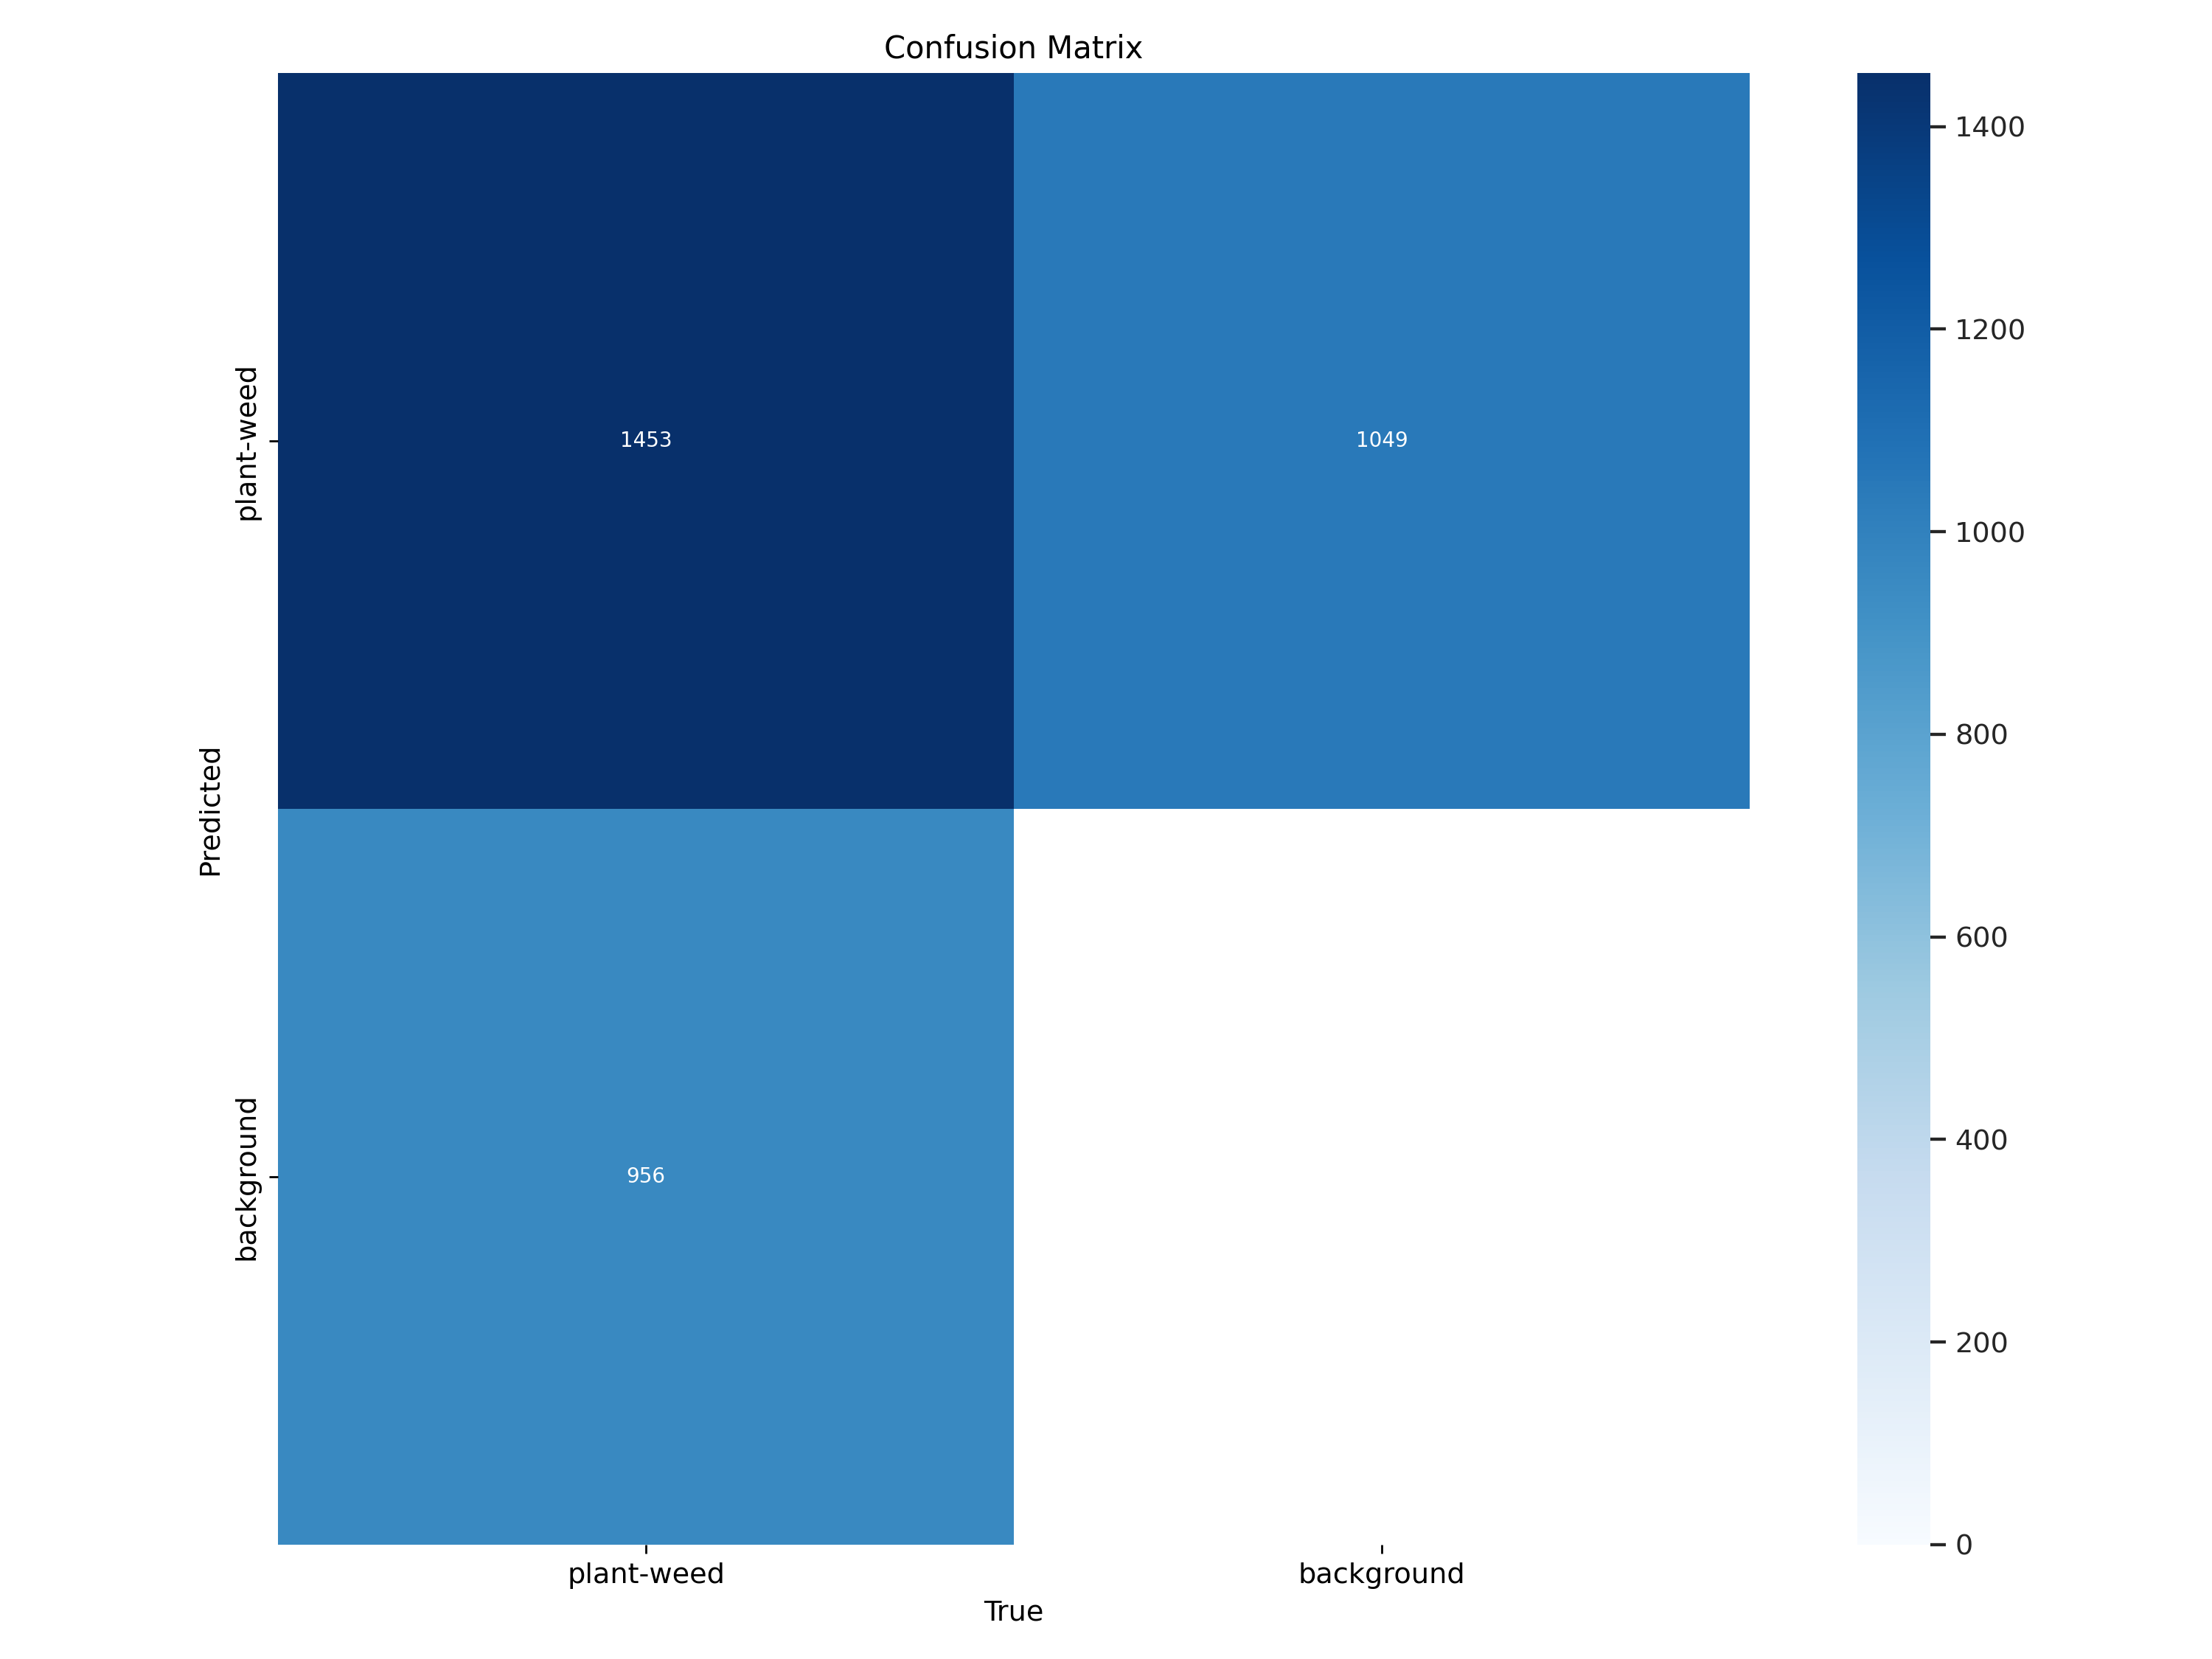

In [69]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

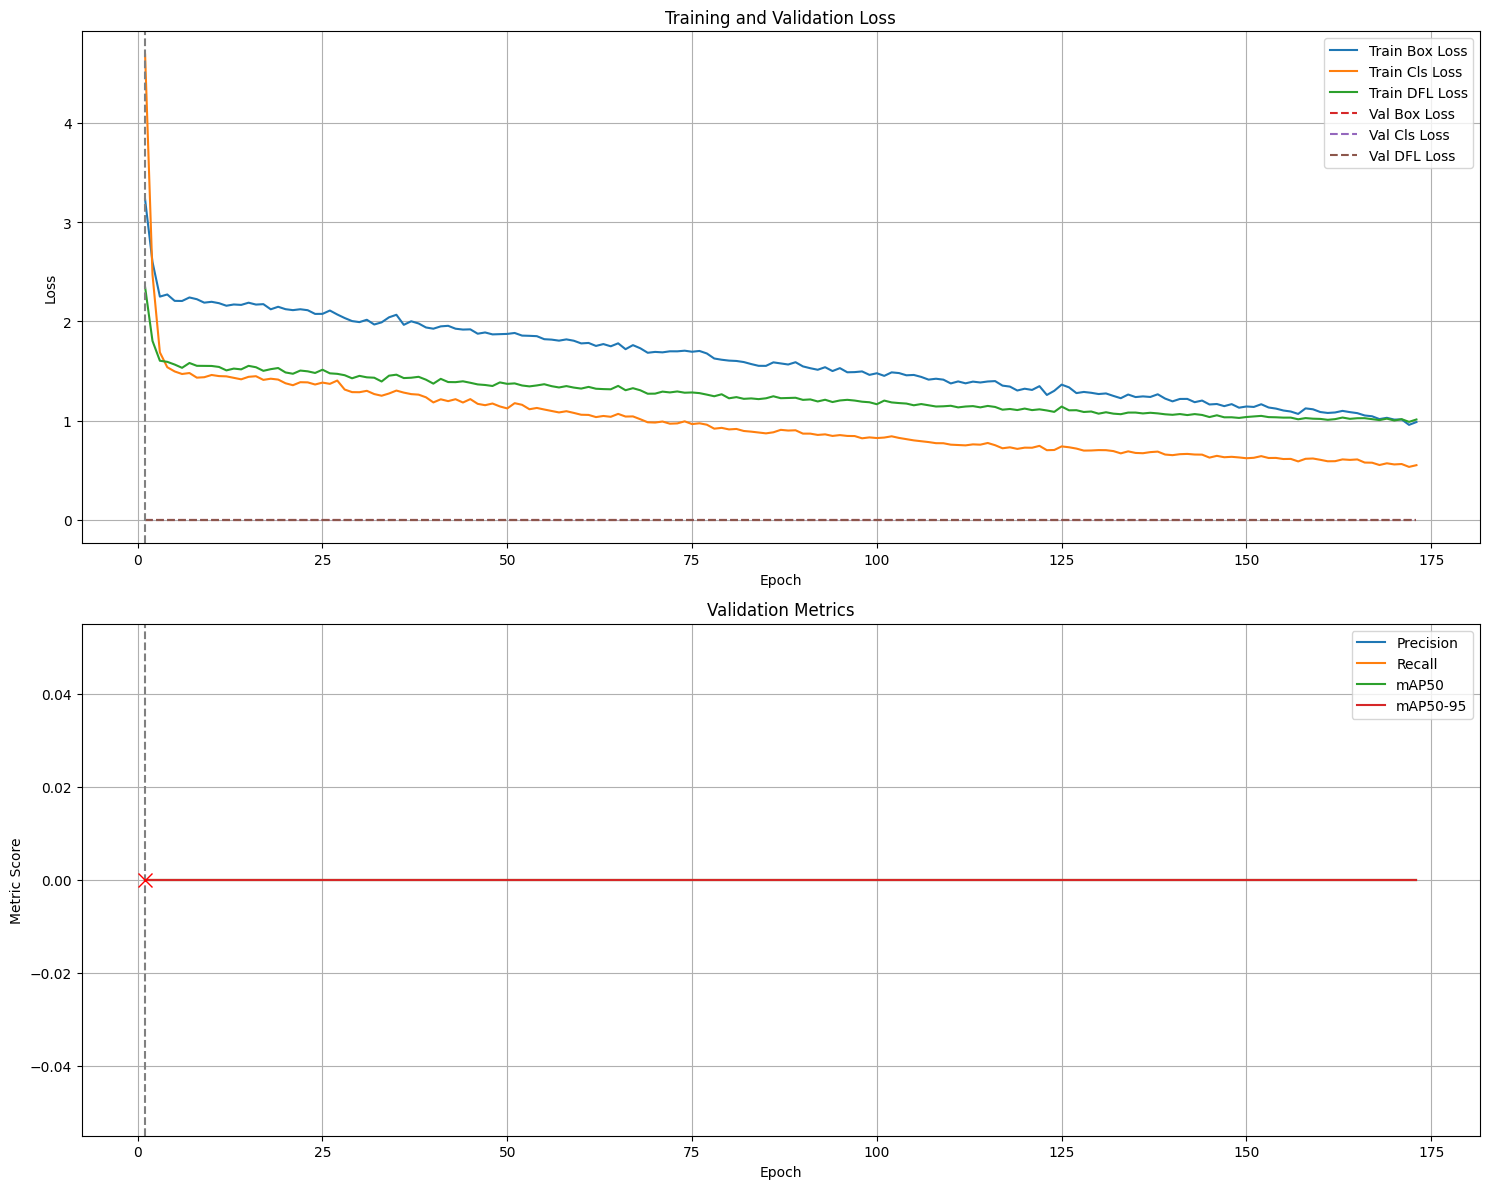

In [70]:
graph_training_metrics(df, epoch, graph="full")

In [71]:
graph_LrLoss_3D(df)

Validation set


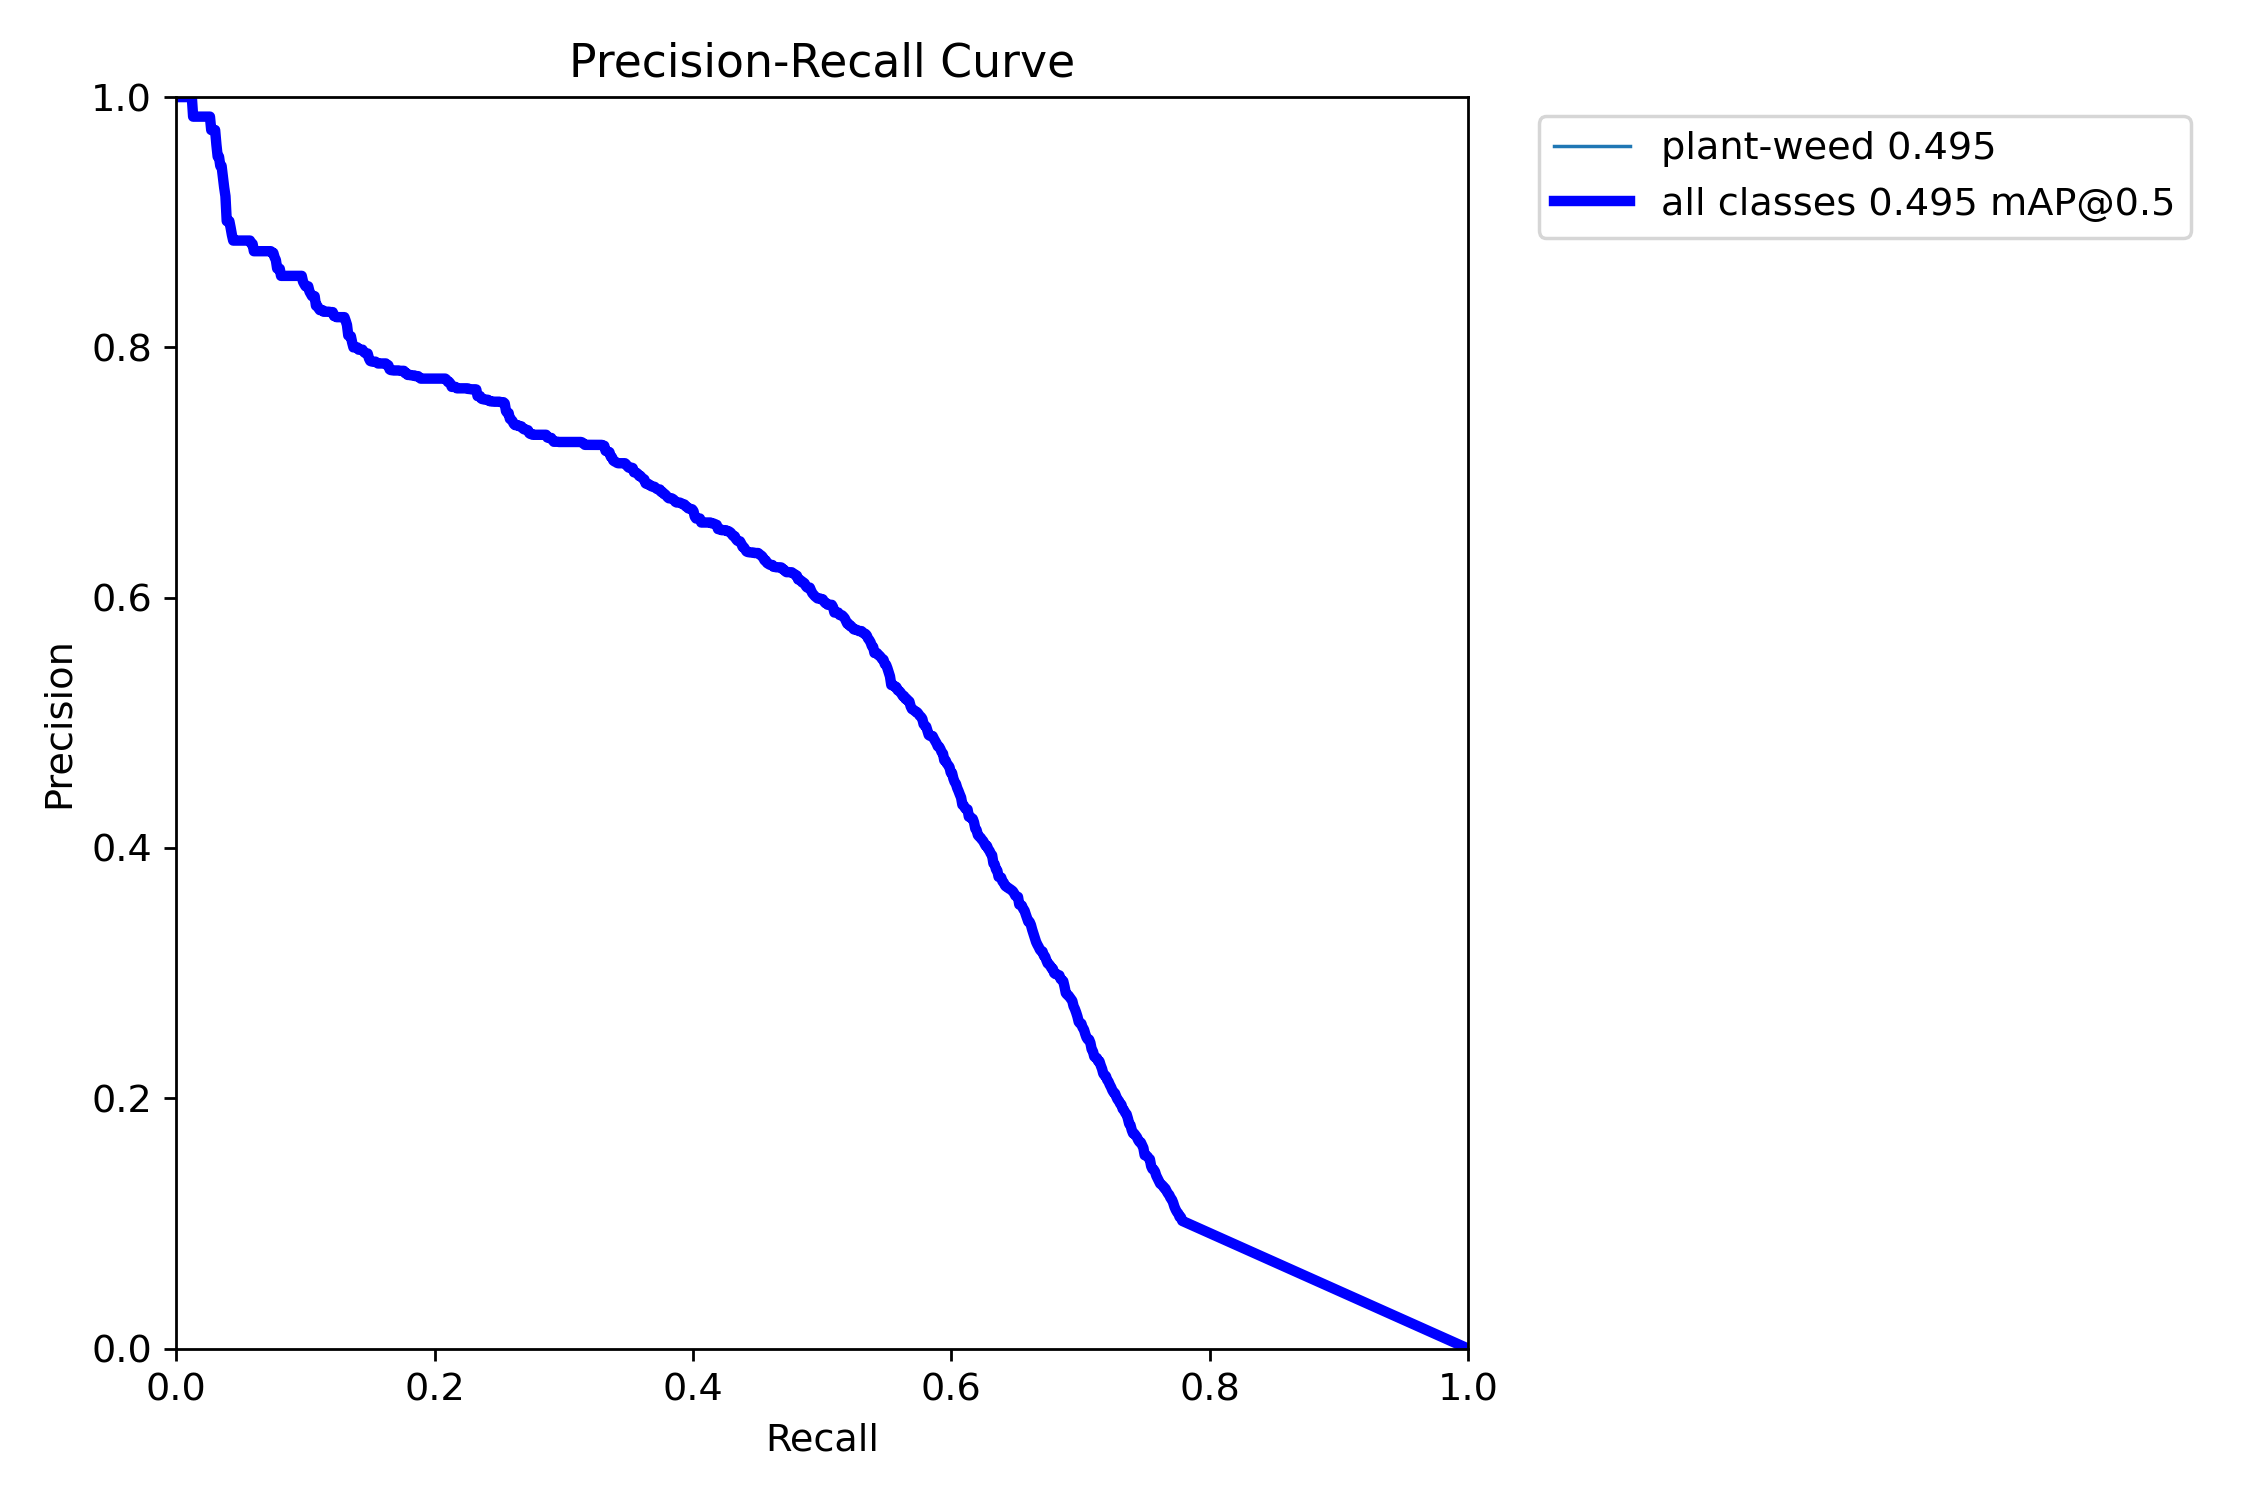

In [72]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

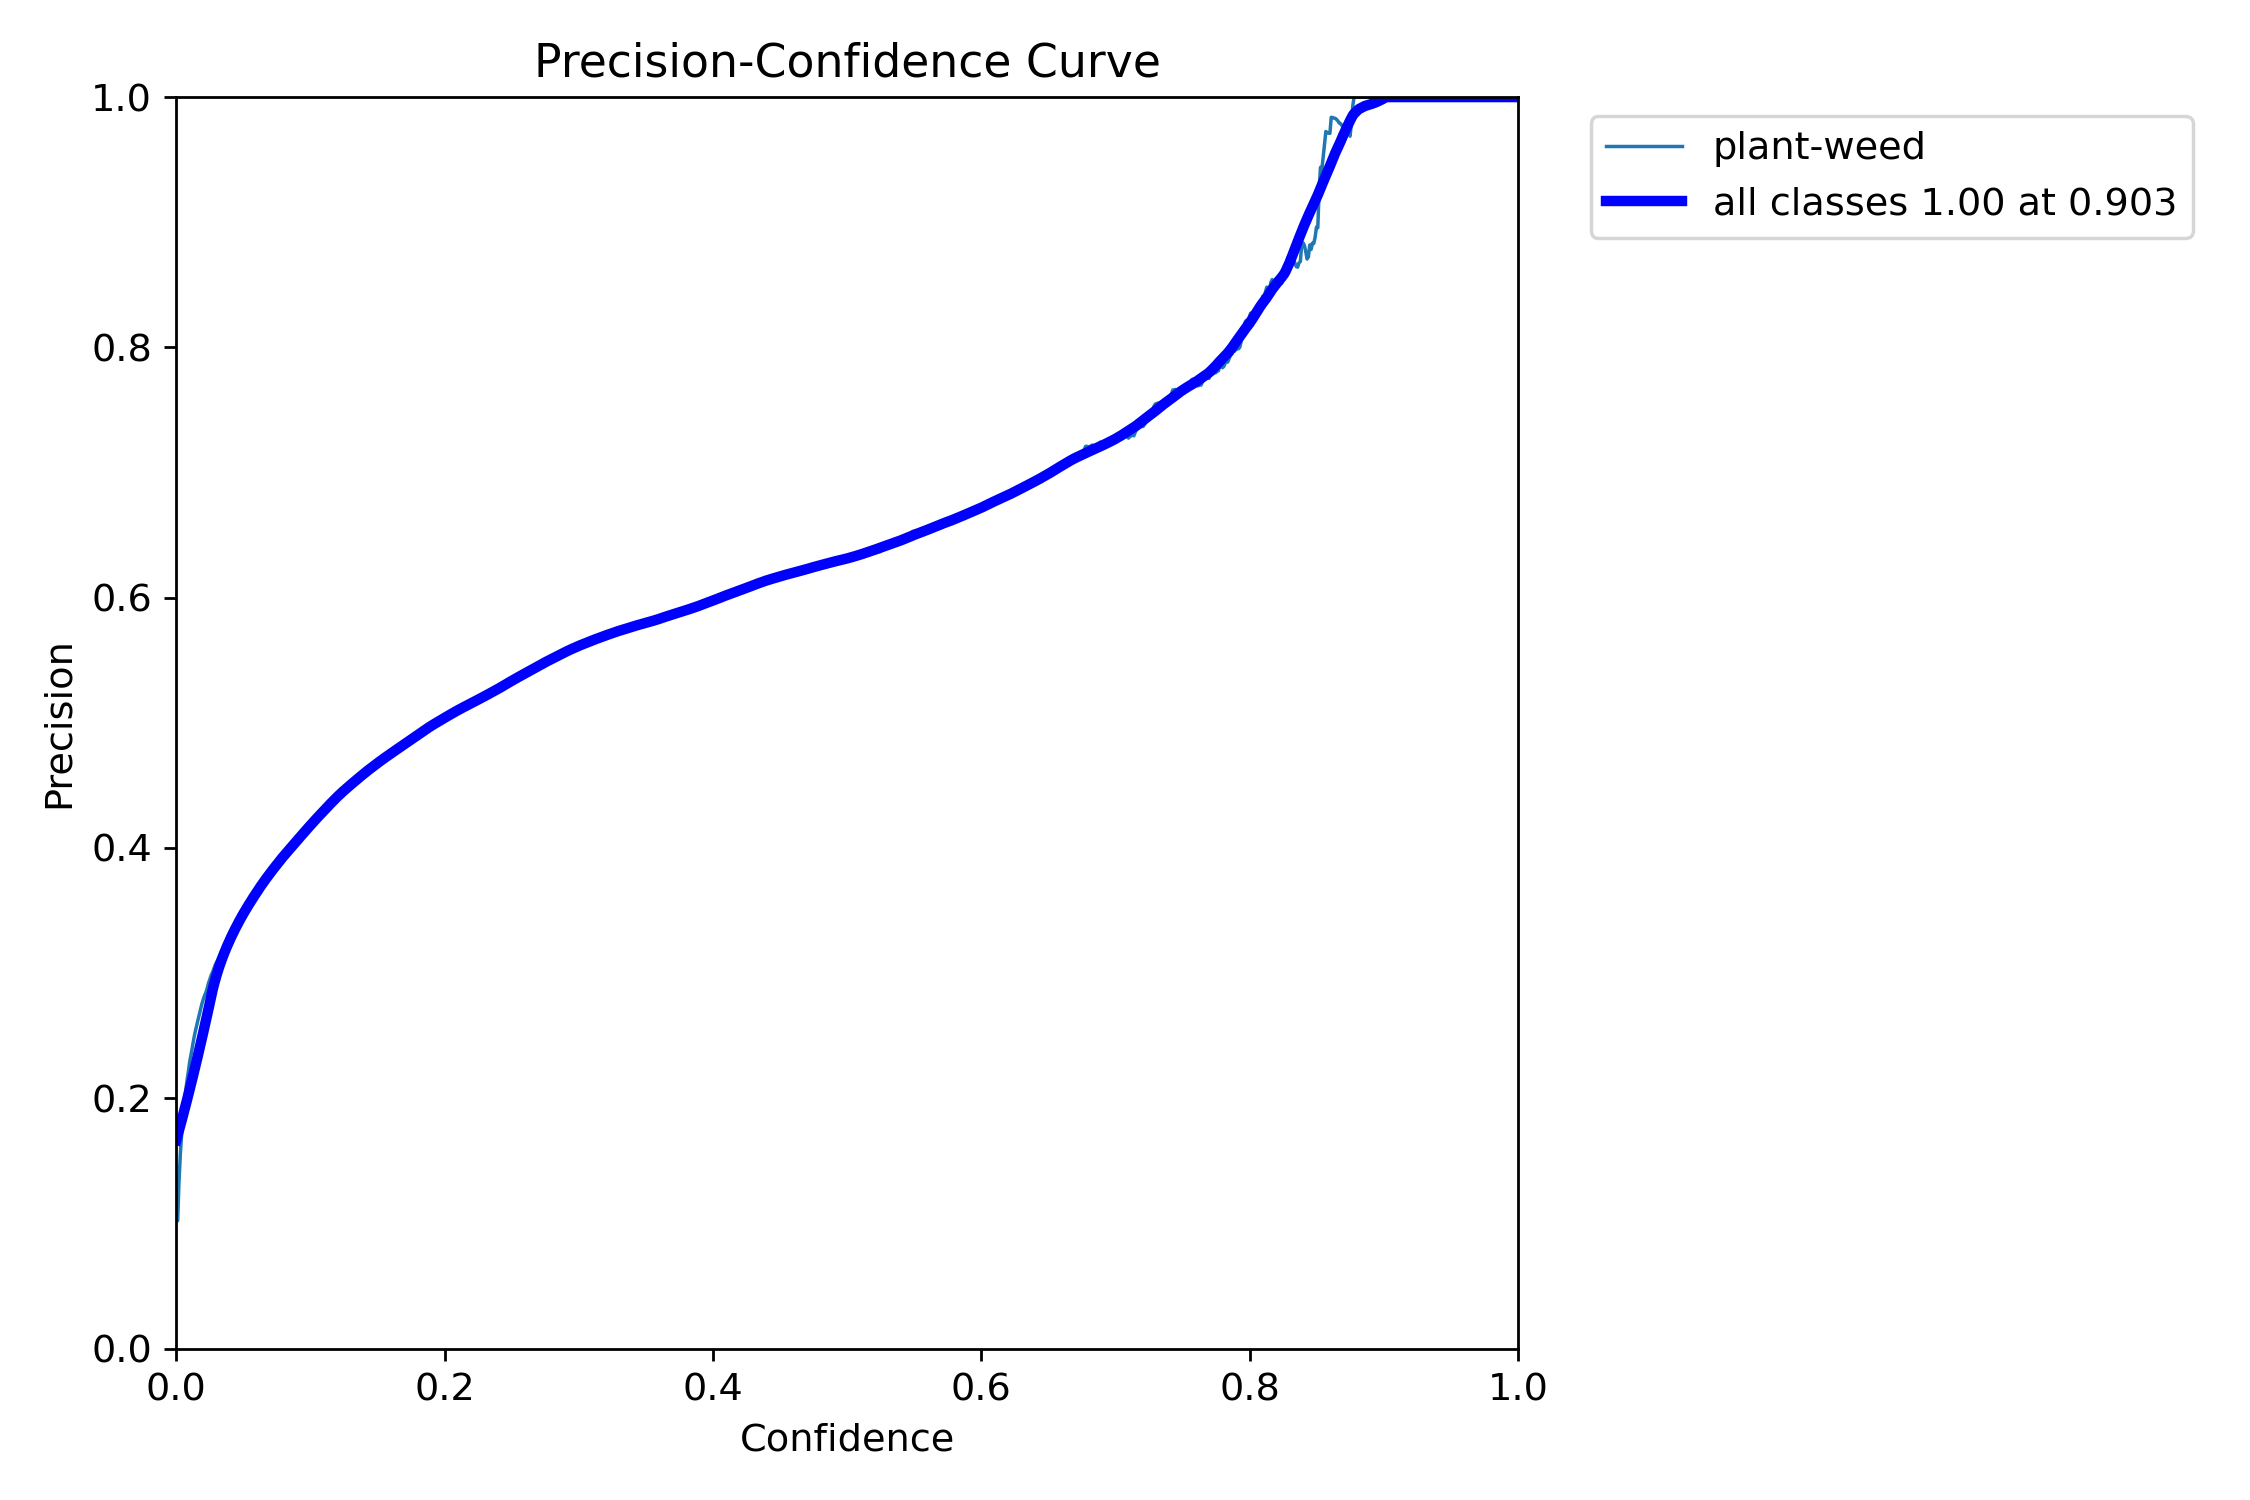

In [73]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

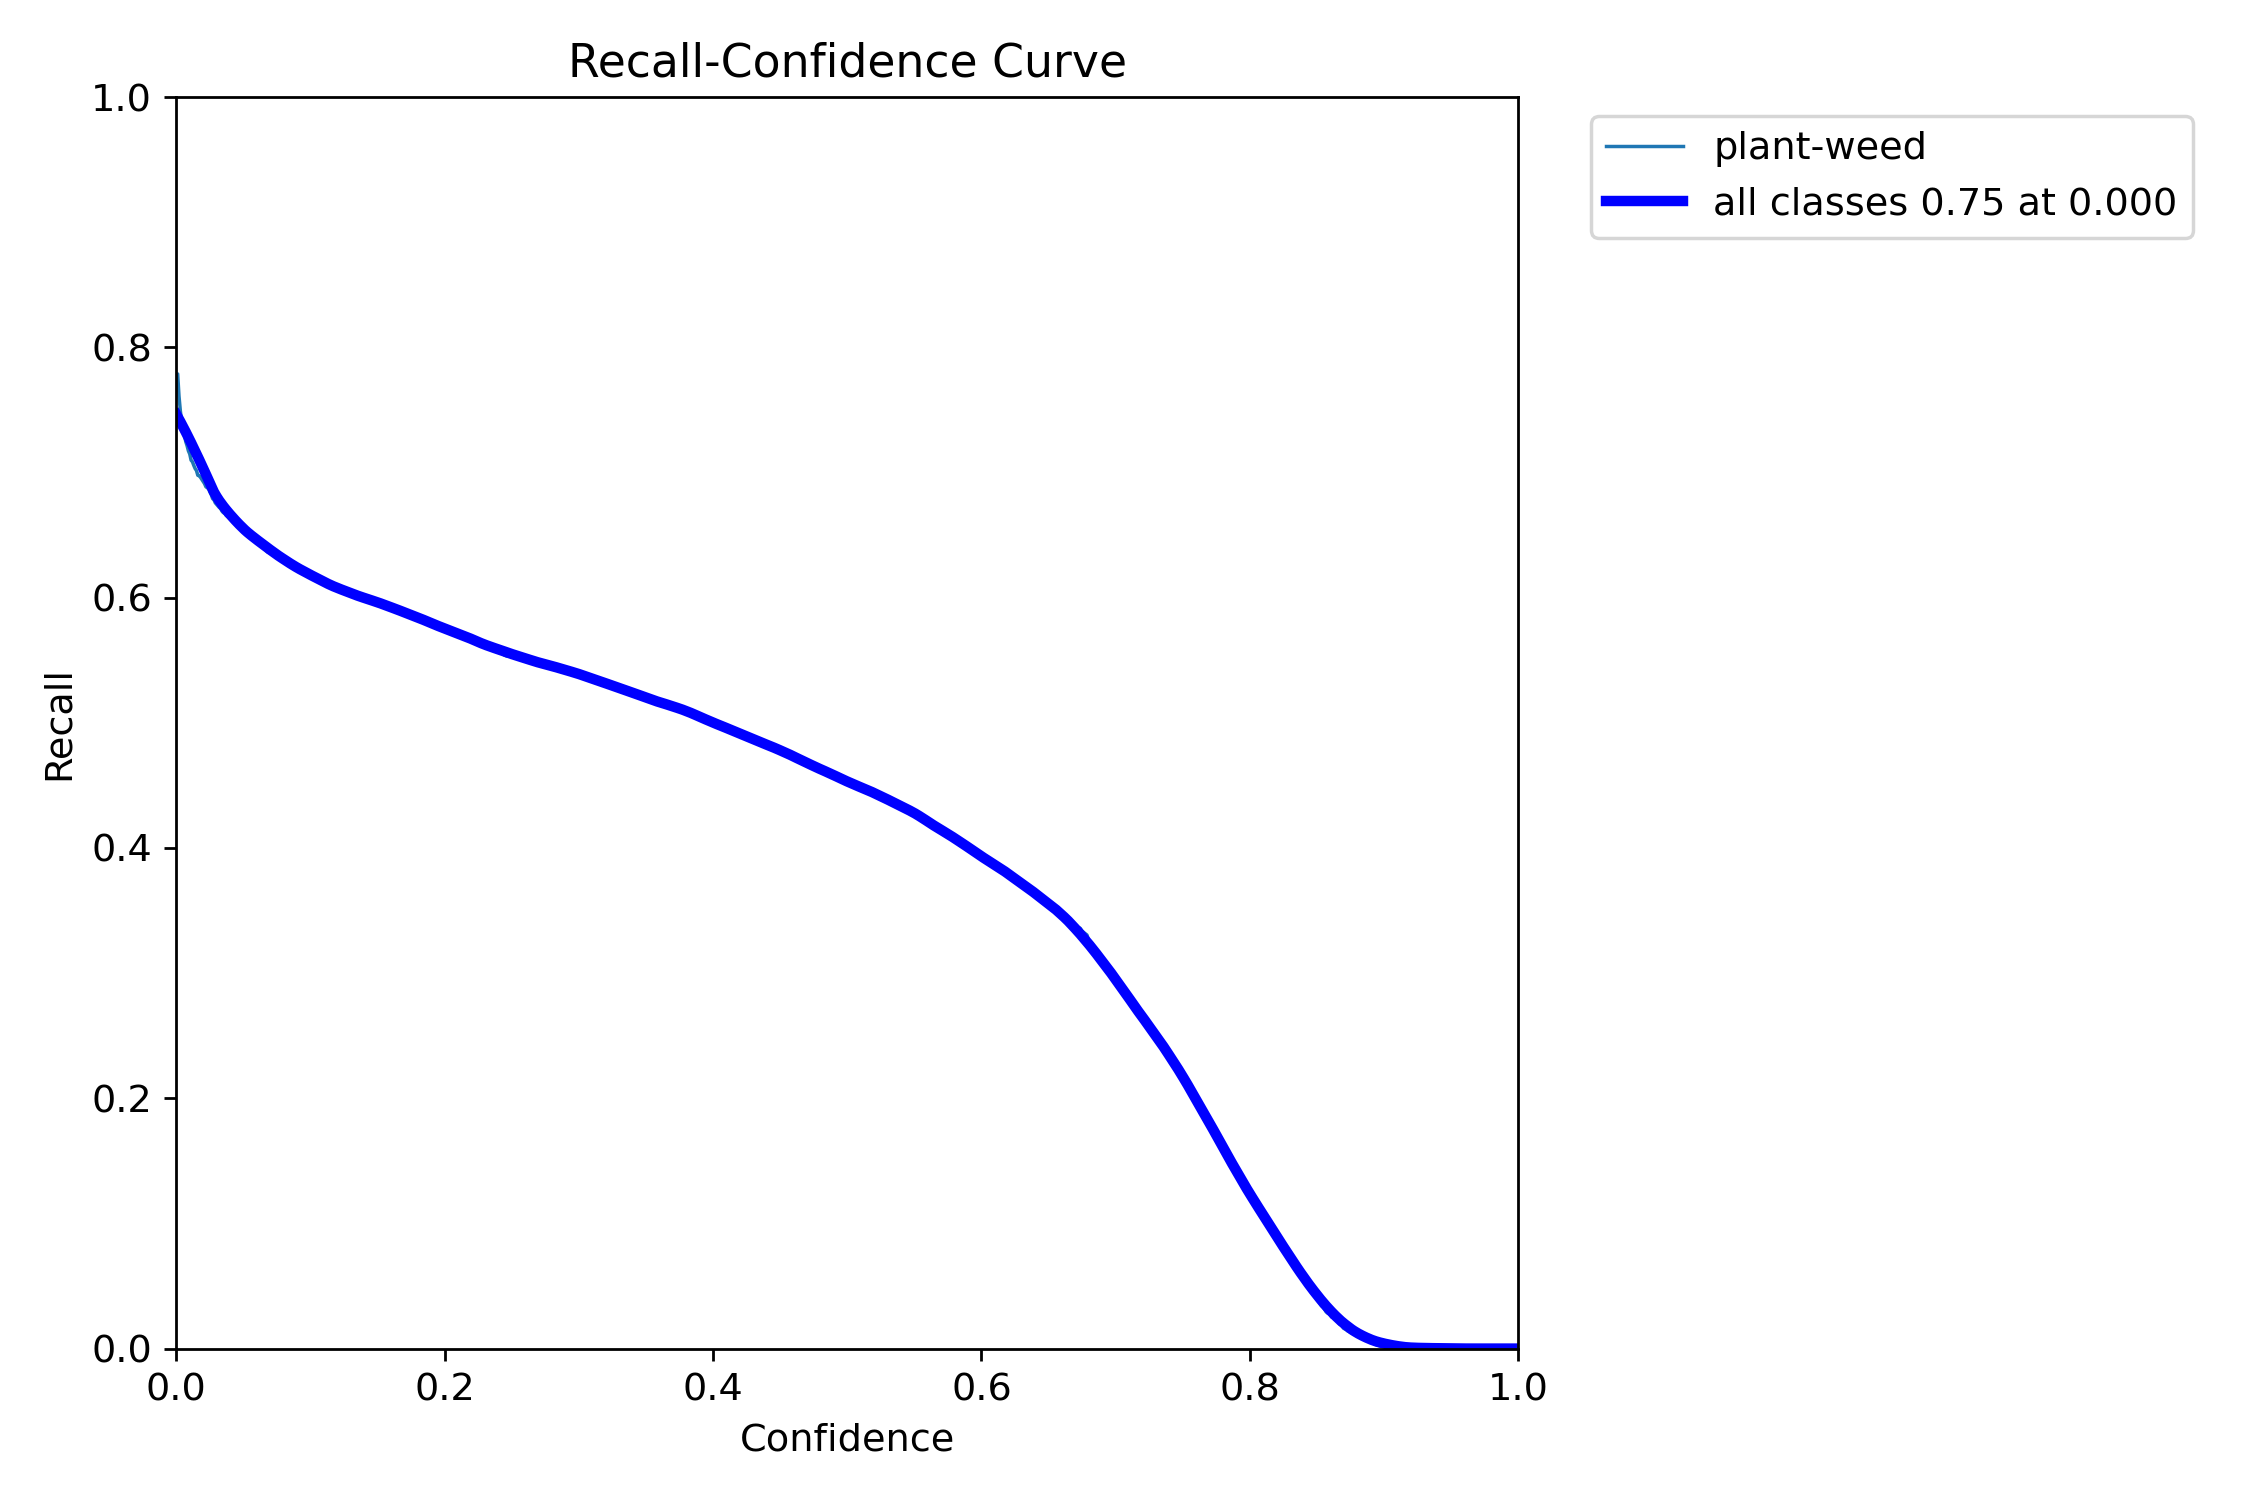

In [74]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

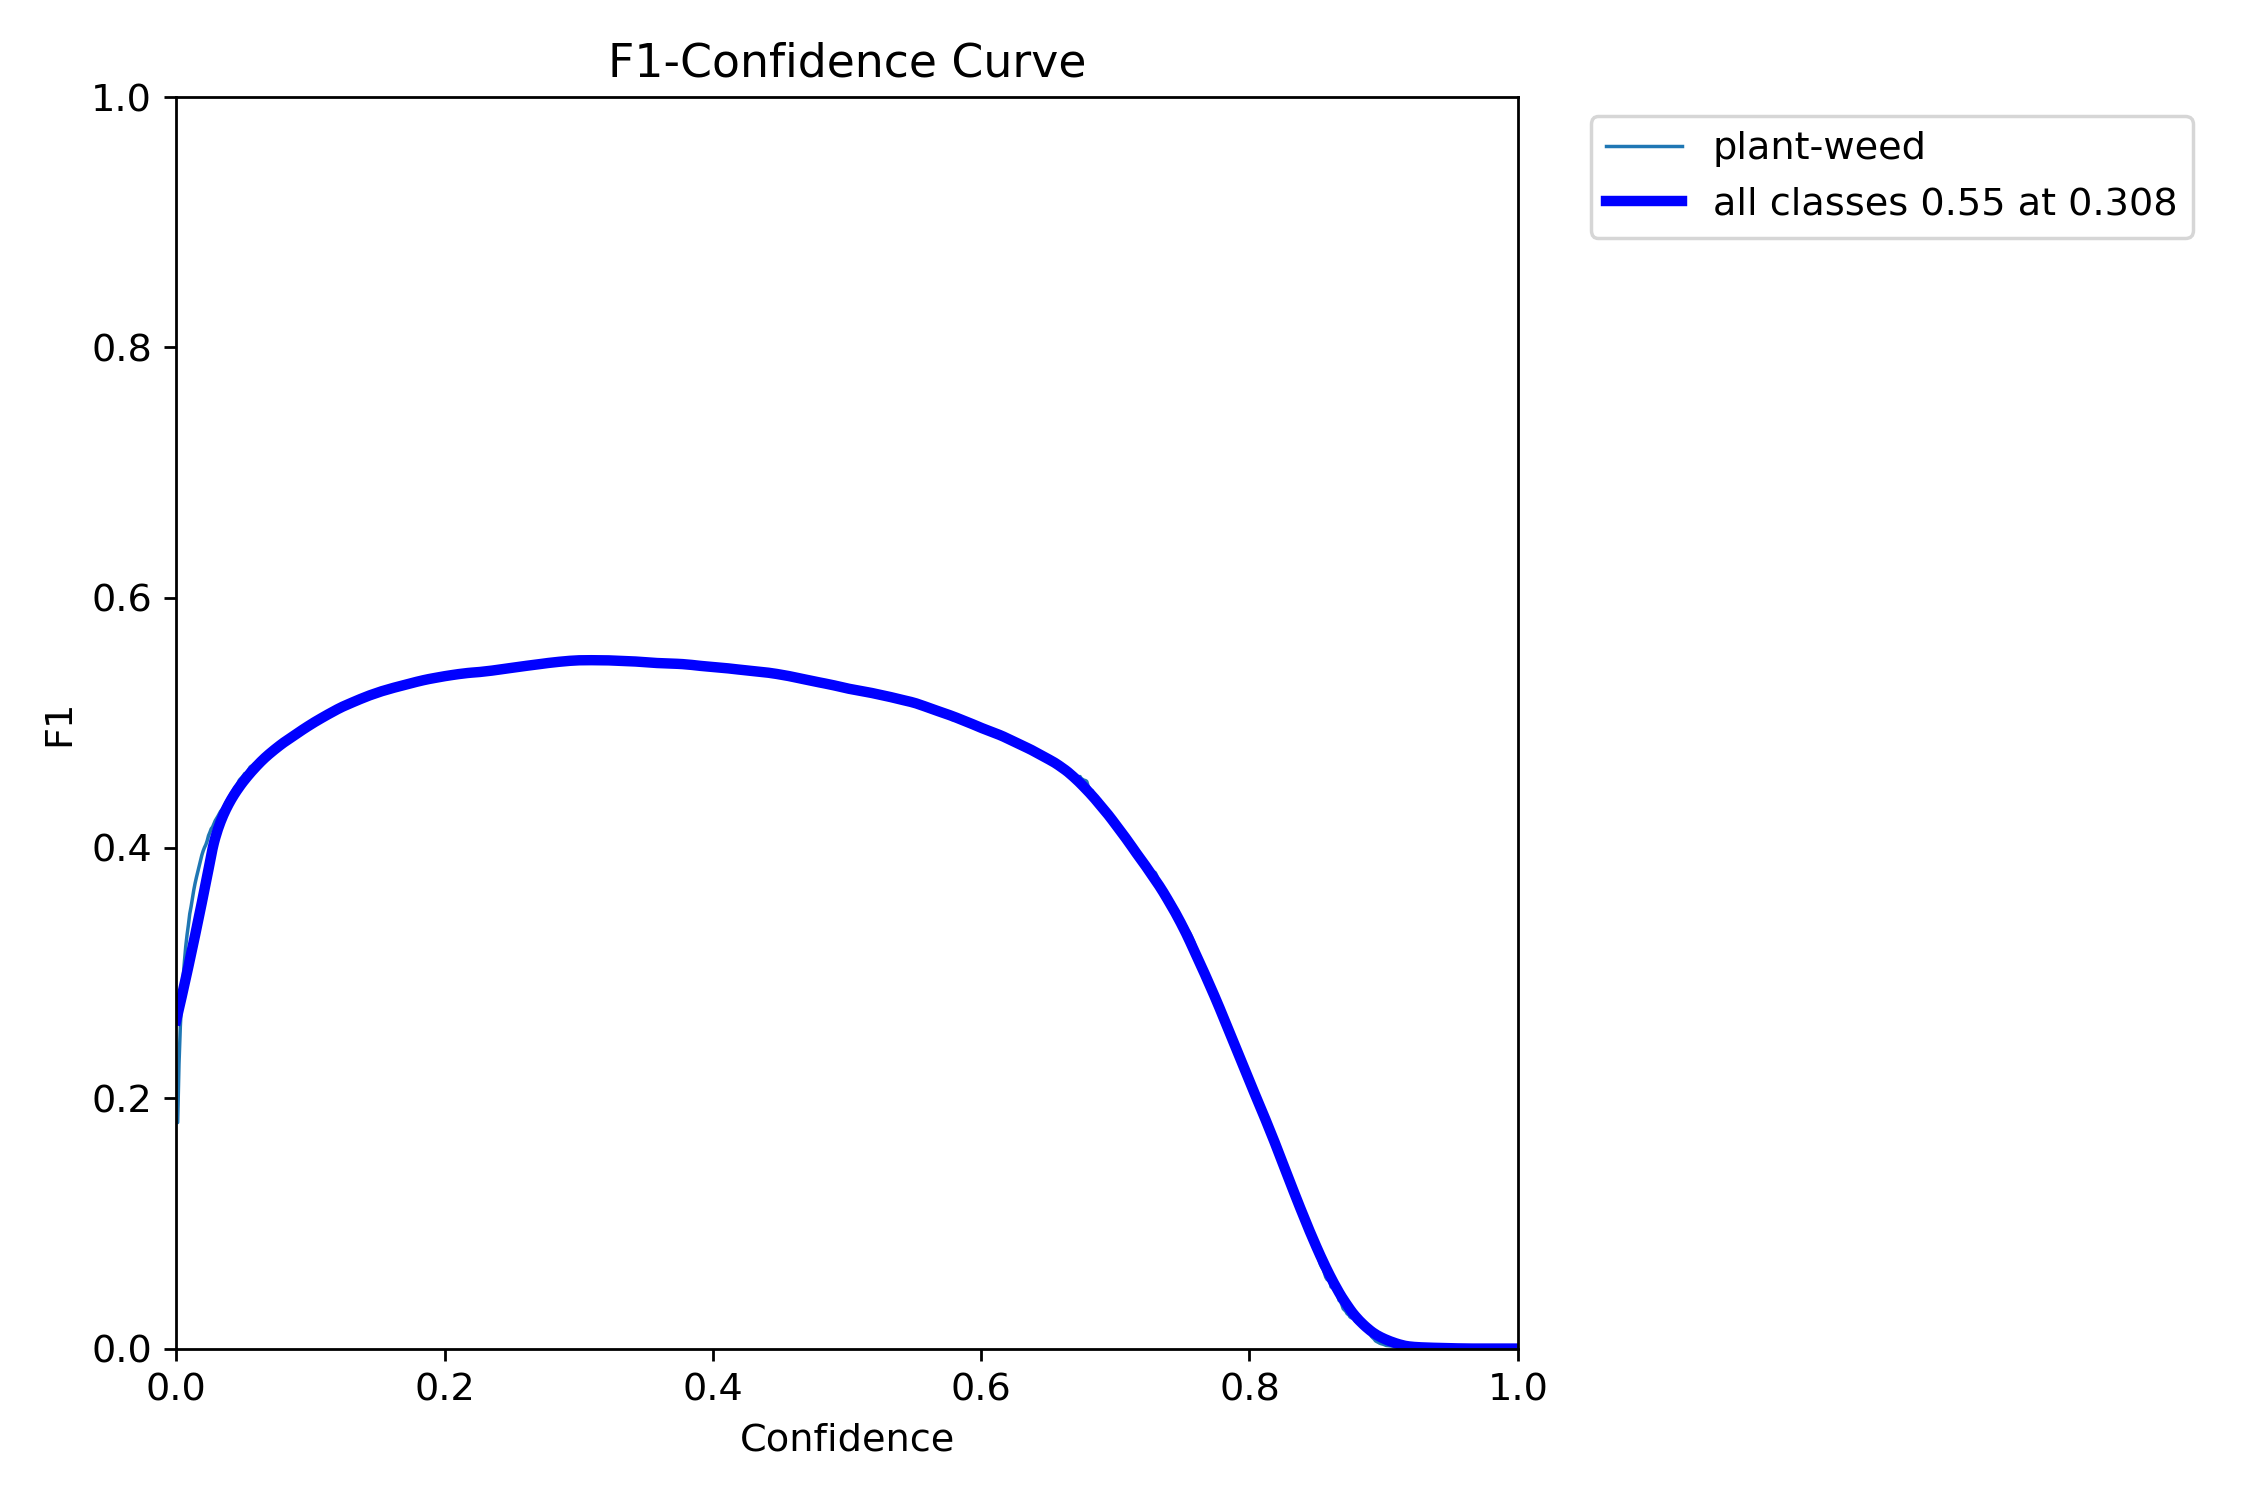

In [75]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

----

# Métricas generales

In [76]:
# For no reference
# best_models.index = [f"{i}º TRAIN" for i in range(1, len(best_models)+1)]
# experiment_number = best_models.index

# For one reference
experiment_number = [f"{i}º TRAIN" for i in range(1, len(best_models))]
experiment_number.append('REF1')

# For two reference
# experiment_number = [f"{i}º TRAIN" for i in range(1, len(best_models)-1)]
# experiment_number.append('REF1')
#experiment_number.append('REF2')

best_models.index = experiment_number

In [77]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
REF1,1,15.0336,3.22651,4.68570,2.34480,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.000120,0.000120,0.000120,208.361667
1º TRAIN,50,5120.4500,1.29463,2.22765,1.33474,0.60306,0.53678,0.54120,0.19188,1.53359,2.65909,1.59745,0.003168,0.003168,0.003168,120.034000
2º TRAIN,12,1284.0000,1.31999,2.47617,1.37952,0.58862,0.53360,0.55066,0.20153,1.44084,2.73333,1.47046,0.003594,0.003594,0.003594,30.048500


## History Graphs

In [78]:
# Define function to plot metrics
def plot_metric(metric, ylabel, title):
    plt.figure(figsize=(15, 5))
    if len(best_models) < 1: print('ALERTA: No hay datos para realizar las gráficas.')
    if len(best_models) >= 1: plt.plot(df1["epoch"], df1[metric], label="Training 1", linestyle="--", marker="o", markersize=4)
    if len(best_models) >= 2: plt.plot(df2["epoch"], df2[metric], label="Training 2", linestyle="--", marker="s", markersize=4)
    if len(best_models) >= 3: plt.plot(df3["epoch"], df3[metric], label="Training 3", linestyle="--", marker="d", markersize=4)
    if len(best_models) >= 4: plt.plot(df4["epoch"], df4[metric], label="Training 4", linestyle="--", marker="^", markersize=4)
    if len(best_models) >= 5: plt.plot(df5["epoch"], df5[metric], label="Training 5", linestyle="--", marker="v", markersize=4)
    if len(best_models) >= 6: plt.plot(df6["epoch"], df6[metric], label="Training 6", linestyle="--", marker="p", markersize=4)
    if len(best_models) >= 7: print("La cantidad de modelos entrenados supera la configuración del gráfico, por favor ajustar la función 'plot_metric()'")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

NameError: name 'df3' is not defined

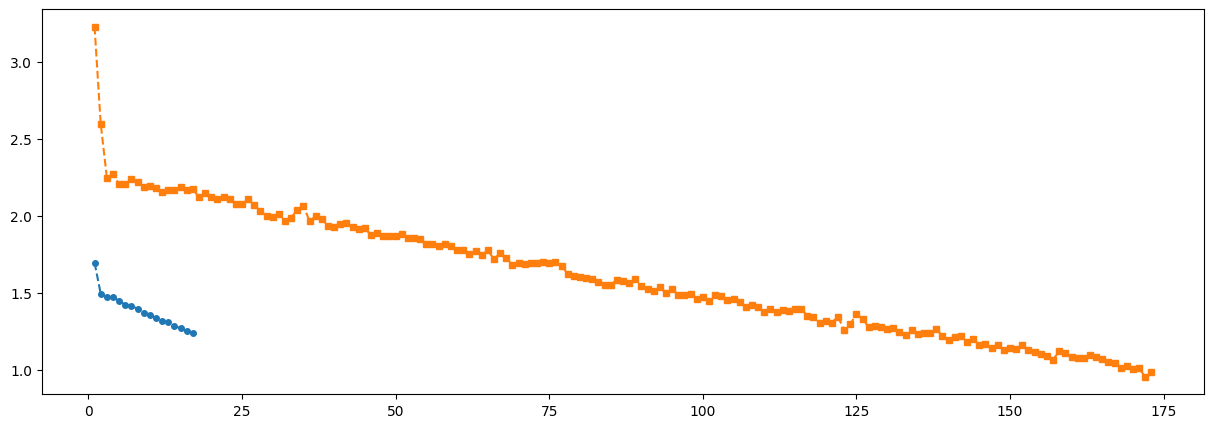

In [79]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

In [ ]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

In [ ]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Comparative Graphs

In [ ]:
#SETUP:
log_scale = False # Apply log scale to the y-axis

In [ ]:
import seaborn as sns

metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
# print(f"Generando gráficos para las métricas: {metrics_to_plot}")

for metric in metrics_to_plot:

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.barplot(x='Model', y=metric, data=df_plot, hue='Model', palette='viridis', dodge=False, legend=False)

    plt.yscale('log') if log_scale else None 
    plt.title(f'Comparación de {metric} entre Modelos')
    plt.xlabel('Modelo')
    plt.ylabel(metric.replace('(B)', '').replace('/', ' / '))  # Clean up the y-axis label
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if they are long
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")

## Lollipop Graphs

In [ ]:
#SETUP:
horizontal = False # Set to True for horizontal lollipop chart
log_scale = False # Apply log scale to the y-axis
sort = True # Sort values for better visual flow
sort_type = 'ascending' # Options: 'ascending', 'descending'

In [ ]:
metrics_to_plot = [
    'metrics/precision(B)',
    'metrics/recall(B)',
    'metrics/mAP50(B)',
    'metrics/mAP50-95(B)',
    'val/box_loss',
    'val/cls_loss',
    'val/dfl_loss',
    'train_time' # Tiempo de entrenamiento también puede ser interesante
]

# Filtramos las métricas que realmente existen en el DataFrame y no tienen todos los valores NaN
metrics_to_plot = [m for m in metrics_to_plot if m in best_models.columns and not best_models[m].isnull().all()]

# Preparamos el DataFrame para seaborn (opcional pero a veces útil)
# Usaremos el índice directamente en este caso.
df_plot = best_models.copy()
df_plot['Model'] = df_plot.index # Crea una columna 'Model' a partir del índice

# --- 3. Genera un gráfico de barras para cada métrica ---
#print(f"Generando gráficos para las métricas: {metrics_to_plot}")
print(f"Orenamiento: {sort_type}") if sort else None

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

for  metric in metrics_to_plot:

    # Preparamos el DataFrame para seaborn (opcional pero a veces útil)
    # Usaremos el índice directamente en este caso.
    df_plot = best_models.dropna(subset=[metric]).copy()
    df_plot['Model'] = df_plot.index

    # Verificamos si la métrica tiene todos los valores NaN o cero
    if df_plot[metric].isnull().all() or (df_plot[metric] == 0).all():
        print(f"(*) Omitiendo gráfico para '{metric}' (todos los valores son NaN o cero).") # Warnings
        continue

    # Filtramos los modelos que tienen NaN o cero en la métrica actual
    omitted_rows = best_models[best_models[metric].isnull() | (best_models[metric] == 0)].index.tolist()
    df_plot = best_models[~best_models.index.isin(omitted_rows)].copy()
    df_plot['Model'] = df_plot.index  # Ensure the 'Model' column is preserved

    # Calculate the average value
    average_value = df_plot[metric].mean()

    # Sort values for potentially better visual flow (optional)
    if sort:
        match sort_type:
            case 'ascending':
                df_plot = df_plot.sort_values(by=metric, ascending=True)
            case 'descending':
                df_plot = df_plot.sort_values(by=metric, ascending=False)
            case _:
                print(f"Invalid sort type '{sort_type}'. No sorting applied.")

    plt.figure(figsize=(10, 7)) # Slightly taller figure might be nice

    # Define the y-values (the metric) and x-values (numerical index for models)
    values = df_plot[metric]
    axis = np.arange(len(df_plot)) # 0, 1, 2, ...

    # Determine the baseline for the stems (lines)
    # Start from slightly below the minimum value to emphasize differences
    plot_min_val = values.min()
    plot_max_val = values.max()
    stem_baseline = plot_min_val * 0.99 # Start stems just below the minimum point
    margin = (plot_max_val - plot_min_val) * 0.05 # Adjust y-axis limits for zoom, adding a margin

    if not horizontal:
        # --- Create the Lollipop Plot ---
        plt.yscale('log') if log_scale else None # Apply log scale to y-axis for vertical plot
        plt.ylim(max(0, plot_min_val - margin), plot_max_val + margin) # Ensure y_min not negative if data positive
    
        # Add average line
        plt.axhline(y=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create the 'stems' (vertical lines)
        plt.vlines(x=axis, ymin=stem_baseline, ymax=values, color='skyblue', alpha=0.7, linewidth=2)

        # Create the 'lollipops' (the dots at the top)
        plt.scatter(x=axis, y=values, color='dodgerblue', s=100, alpha=1, zorder=3) # zorder=3 makes dots appear on top

        # Add value labels next to the dots
        for i, txt in enumerate(values):
            plt.text(axis[i], values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly above dot
                    f'{txt:.4f}', # Format the number
                    ha='center', # Horizontal alignment
                    va='bottom', # Vertical alignment
                    fontsize=9)

        # Customize the plot
        plt.xlabel('Modelo')
        plt.ylabel(metric)

        # Set the x-axis ticks to be the model names
        plt.xticks(axis, df_plot['Model'], rotation=45, ha='right')

        # Add a light grid for easier comparison
        plt.grid(axis='y', linestyle='--', alpha=0.6)


    if horizontal:
        # --- Horizontal Lollipop (Alternative) ---
        plt.xscale('log') if log_scale else None # Apply log scale to x-axis for horizontal plot
        plt.xlim(max(0, plot_min_val - margin), plot_max_val + margin)

        # Add average line
        plt.axvline(x=average_value, color='gray', linestyle='--', label=f'Promedio: {average_value:.4f}')

        # Create horizontal lines (stems)
        plt.hlines(y=axis, xmin=stem_baseline, xmax=values, color='lightcoral', alpha=0.7, linewidth=2)

        # Create the dots
        plt.scatter(x=values, y=axis, color='firebrick', s=100, alpha=1, zorder=3)

        # Add value labels next to dots
        for i, txt in enumerate(values):
            plt.text(values.iloc[i] + (plot_max_val - plot_min_val) * 0.01, # Position label slightly right of dot
                    axis[i],
                    f'{txt:.4f}',
                    ha='left',
                    va='center',
                    fontsize=9)

        # Customize
        plt.xlabel(metric)
        plt.ylabel('Modelo')

        # Set the y-axis ticks to be the model names
        plt.yticks(axis, df_plot['Model']) # Set model names on y-axis ticks
        # Add a light grid for easier comparison
        plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on x-axis now
        

    plt.title(f'Comparación de {metric} entre Modelos (Lollipop Chart)')
    plt.tight_layout()
    plt.show()

    if omitted_rows:
        print(f"- El modelo {', '.join(omitted_rows)} fue omitido para la métrica '{metric}' (tiene valores NaN o 0).")  # Warnings
    print("\n")
    

# Resumen de los Experimentos

| Experiment | Dataset (Size) | Tiles | Tags  | Train Time (min)  | Total detections | True Positives | False Positives | False Negatives | Precision | mAP@0.5 | F1 | F½ |
|------------|------|--------------|---------|------|---------------|---------------|---------------|---------------|--------|--------|--------|--------|
| **1º TRAIN (83)** | Small & Mid | 324 | 7669 |  |  | **%** | % | % | 0. | 0. | 0. | 0. |
| **VALID (83)** | Small & Mid | 324 | 7669 | - |  | **%** | % | % | 0. | 0. | 0. | 0. |
| |
| **2º TRAIN (26)** | Small & Mid | 324 | 7669 | 208  | 3458 | **42.02%** | 30.34% | 27.65% | 0.581 | 0.495 | 0.592 | 0.585 |


1. 9x RF augmentation + Full Fine-Tuning + Max epochs
1. Validation: tuned conf/iou
1. Full Fine-Tuning ***(Reference)***


# Conclusiones